In [237]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [238]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

font = { 'size'   : 15}
plt.rc('font', **font)

colors = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple','tab:brown','tab:pink','tab:gray','tab:olive','tab:cyan']
styles = ['o','s','v','^','D',">","<","*","h","H","+","1","2","3","4","8","p","d","|","_",".",","]

markersize = 10
markerwidth = 2
maxchar = 50

def roofline(filename, TIME, INTOPS, FLOPS, AIHBM, AIL2=None, AIL1=None, LABELS=None, flag='HBM'):

    if not FLOPS:
        print('FLOPS can not be empty!')
        return
    if max(FLOPS)==0:
        print('FLOPS are all 0s!')
        return
    if (not AIHBM) and (not AIL2) and (not AIL1):
        print('AIHBM, AIL2 and AIL1 can not all be empty!')
        return
    if (len(FLOPS) != len(AIHBM)) or (len(FLOPS) != len(AIL2)) or (len(FLOPS) != len(AIL1)):
        print('FLOPS needs to have the same length as AI!')
        return
    if (flag != 'HBM') and (flag != 'L2') and (flag != 'L1') and (flag != 'all'):
        print('flag needs to be one of HBM, L2, L1, and all!')
        return
    LABELS = [x[:maxchar] for x in LABELS]

#    memRoofs = [('L1', 54000.), ('L2', 2996.77),  ('HBM', 828.76)]
#    cmpRoofs = [('Tensor', 96.9),('DP', 7.8)]
    memRoofs = [('L1', 54000.), ('L2', 2996.77),  ('GDDR6', 320.00)]
#   [('Tensor', 65.)
    cmpRoofs = [('HP', 2*8.1),('SP', 8.1),('DP', 8.1/32)]


    fig = plt.figure(1,figsize=(10.67,6.6))
    plt.clf()
    ax = fig.gca()
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Arithmetic Intensity [FLOPs/Byte]')
    ax.set_ylabel('Performance [GFLOP/sec]')

    nx   = 10000
    xmin = -3
    xmax = 3
    ymin = 0.01
    ymax = 200000

    ax.set_xlim(10**xmin, 10**xmax)
    ax.set_ylim(ymin, ymax)

    ixx = int(nx*0.02)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    scomp_x_elbow  = []
    scomp_ix_elbow = []
    smem_x_elbow   = []
    smem_ix_elbow  = []

    x = np.logspace(xmin,xmax,nx)
    for roof in cmpRoofs:
        for ix in range(1,nx):
            if float(memRoofs[0][1] * x[ix]) >= roof[1]*1024 and (memRoofs[0][1] * x[ix-1]) < roof[1]*1024:
                scomp_x_elbow.append(x[ix-1])
                scomp_ix_elbow.append(ix-1)
                break

    for roof in memRoofs:
        for ix in range(1,nx):
            if (cmpRoofs[0][1]*1024 <= roof[1] * x[ix] and cmpRoofs[0][1]*1024 > roof[1] * x[ix-1]):
                smem_x_elbow.append(x[ix-1])
                smem_ix_elbow.append(ix-1)
                break

    for i in range(len(cmpRoofs)):
        roof = cmpRoofs[i][1]*1024
        y = np.ones(len(x)) * roof
        ax.plot(x[scomp_ix_elbow[i]:],y[scomp_ix_elbow[i]:],c='k',ls='-',lw='2')

    for i in range(len(memRoofs)):
        roof = memRoofs[i][1]
        y = x * roof
        ax.plot(x[:smem_ix_elbow[i]+1],y[:smem_ix_elbow[i]+1],c='k',ls='-',lw='2')


    for i in range(len(AIHBM)):
        if flag == 'L1':
            ax.plot(float(AIL1[i]),float(FLOPS[i]),c=colors[i%10],marker=styles[0],\
                    linestyle='None',ms=markersize,markerfacecolor='none',\
                    markeredgewidth=markerwidth,label=LABELS[i] if LABELS else "unknown")
        elif flag == 'L2':
            ax.plot(float(AIL2[i]),float(FLOPS[i]),c=colors[i%10],marker=styles[1],\
                    linestyle='None',ms=markersize,markerfacecolor='none',\
                    markeredgewidth=markerwidth,label=LABELS[i] if LABELS else "unknown")
        elif flag == 'HBM':
            ax.plot(float(AIHBM[i]),float(FLOPS[i]),c=colors[i%10],marker=styles[2],\
                    linestyle='None',ms=markersize,markerfacecolor='none',\
                    markeredgewidth=markerwidth,label=LABELS[i] if LABELS else "unknown")
        elif flag == 'all':
            ax.plot(float(AIL1[i]),float(FLOPS[i]),c=colors[i%10],marker=styles[0],\
                    linestyle='None',ms=markersize,markerfacecolor='none',\
                    markeredgewidth=markerwidth,label=LABELS[i] if LABELS else "unknown")
            ax.plot(float(AIL2[i]),float(FLOPS[i]),c=colors[i%10],marker=styles[1],\
                    linestyle='None',ms=markersize,markerfacecolor='none',\
                    markeredgewidth=markerwidth,label=LABELS[i] if LABELS else "unknown")
            ax.plot(float(AIHBM[i]),float(FLOPS[i]),c=colors[i%10],marker=styles[2],\
                    linestyle='None',ms=markersize,markerfacecolor='none',\
                    markeredgewidth=markerwidth,label=LABELS[i] if LABELS else "unknown")

    marker_handles = []

    if flag == 'L1':
        marker_handles.append(ax.plot([],[],c='k',marker=styles[0],linestyle='None',ms=markersize,\
                markerfacecolor='none',markeredgewidth=markerwidth,label=memRoofs[0][0])[0])
    elif flag == 'L2':
        marker_handles.append(ax.plot([],[],c='k',marker=styles[1],linestyle='None',ms=markersize,\
                markerfacecolor='none',markeredgewidth=markerwidth,label=memRoofs[1][0])[0])
    elif flag == 'HBM':
        marker_handles.append(ax.plot([],[],c='k',marker=styles[2],linestyle='None',ms=markersize,\
                markerfacecolor='none',markeredgewidth=markerwidth,label=memRoofs[2][0])[0])
    elif flag == 'all':
        for i in range(len(memRoofs)):
            marker_handles.append(ax.plot([],[],c='k',marker=styles[i],linestyle='None',ms=markersize,\
                                  markerfacecolor='none',markeredgewidth=markerwidth,label=memRoofs[i][0])[0])


    for roof in cmpRoofs:
        ax.text(x[-ixx],roof[1]*1024,
              roof[0] + ': ' + '{0:.1f}'.format(roof[1]) + ' TFLOP/s',
              horizontalalignment='right',
              verticalalignment='bottom')

    for roof in memRoofs:
        ang = np.arctan(np.log10(xlim[1]/xlim[0]) / np.log10(ylim[1]/ylim[0])
                                   * fig.get_size_inches()[1]/fig.get_size_inches()[0] )
        if x[ixx]*roof[1] >ymin:
            ax.text(x[ixx],x[ixx]*roof[1]*(1+0.25*np.sin(ang)**2),
              roof[0] + ': ' + '{0:.1f}'.format(float(roof[1])) + ' GB/s',
              horizontalalignment='left',
              verticalalignment='bottom',
              rotation=180/np.pi*ang)
        else:
            ymin_ix_elbow=list()
            ymin_x_elbow=list()
            for ix in range(1,nx):
                if (ymin <= roof[1] * x[ix] and ymin > roof[1] * x[ix-1]):
                    ymin_x_elbow.append(x[ix-1])
                    ymin_ix_elbow.append(ix-1)
                    break
            ax.text(x[ixx+ymin_ix_elbow[0]],x[ixx+ymin_ix_elbow[0]]*roof[1]*(1+0.25*np.sin(ang)**2),
              roof[0] + ': ' + '{0:.1f}'.format(float(roof[1])) + ' GB/s',
              horizontalalignment='left',
              verticalalignment='bottom',
              rotation=180/np.pi*ang)



    leg1 = plt.legend(handles = marker_handles,loc='lower right', ncol=len(flag[0]) if 'all' not in flag else 3,bbox_to_anchor = (1,0))
    ax.add_artist(leg1)

    patch_handles = list()
    for i in range(0,len(AIHBM)):
        if FLOPS[i] > 0:
            patch_handles.append(mpatches.Patch(color=colors[i%10],label = LABELS[i] if LABELS else "unknown"))

    leg2 = plt.legend(handles = patch_handles,loc=4,ncol=1,bbox_to_anchor = (-0.1,0.01),scatterpoints = 1)

    ax.text(xlim[0]*1.1,ylim[1]/1.1, '-'.join([filename,flag]), horizontalalignment='left',verticalalignment='top')
#     plt.title('-'.join([filename,flag]))

#    plt.savefig('_'.join([filename,flag])+'.png')
#     plt.savefig('_'.join([filename,flag])+'.eps')

    plt.show()
    
    fig = plt.figure(1,figsize=(10,7))
    plt.clf()
    ax = fig.gca()
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Time [seconds]')
    ax.set_ylabel('Performance [GFLOP/sec]')
    for i in range(len(TIME)):
       ax.plot(float(TIME[i]),float(FLOPS[i]),c=colors[i%10],marker=styles[2],\
                    linestyle='None',ms=markersize,markerfacecolor='none',\
                    markeredgewidth=markerwidth,label=LABELS[i] if LABELS else "unknown")
    plt.show()
    
    fig = plt.figure(1,figsize=(10,7))
    plt.clf()
    ax = fig.gca()
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('GINTOP')
    ax.set_ylabel('GFLOP')
    ax.set_xlim(10**-5, 10**1)
    for i in range(len(TIME)):
       ax.plot(float(TIME[i])*float(INTOPS[i]),float(TIME[i])*float(FLOPS[i]),c=colors[i%10],marker=styles[2],\
                    linestyle='None',ms=markersize,markerfacecolor='none',\
                    markeredgewidth=markerwidth,label=LABELS[i] if LABELS else "unknown")
    plt.show()

In [239]:
def parseThree(a) :
    vals = [float(x.strip()) for x in a.replace(')','').replace('(','').split(",")]
    return vals[0]*vals[1]*vals[2]

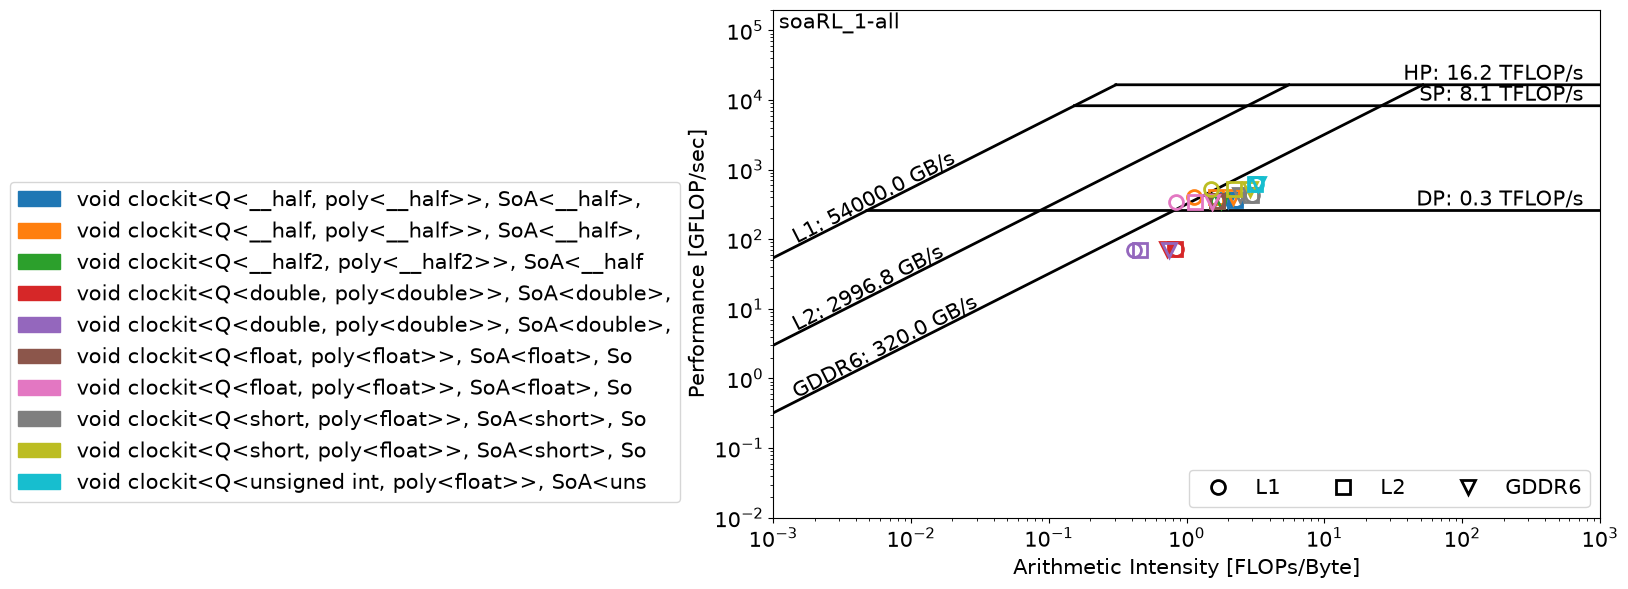

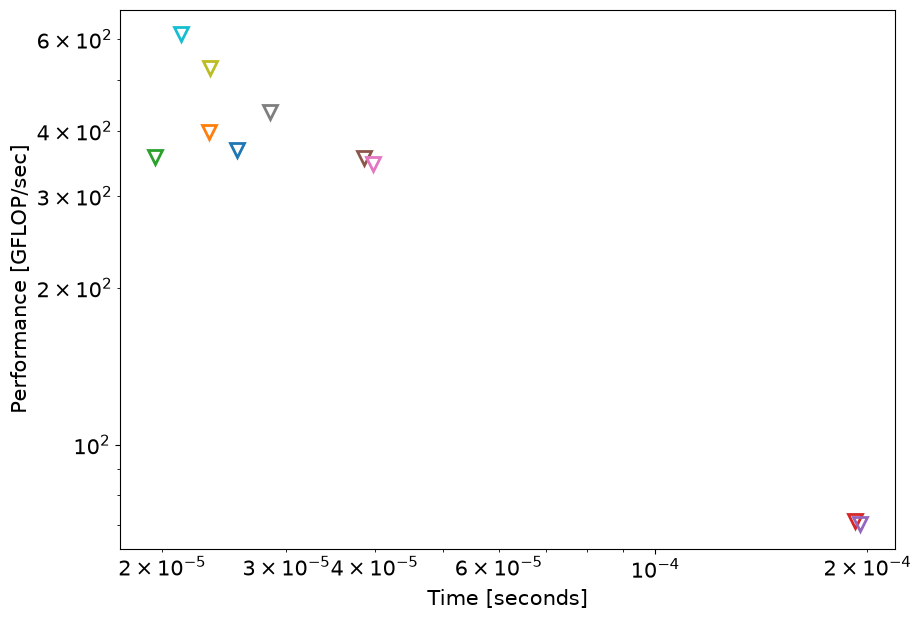

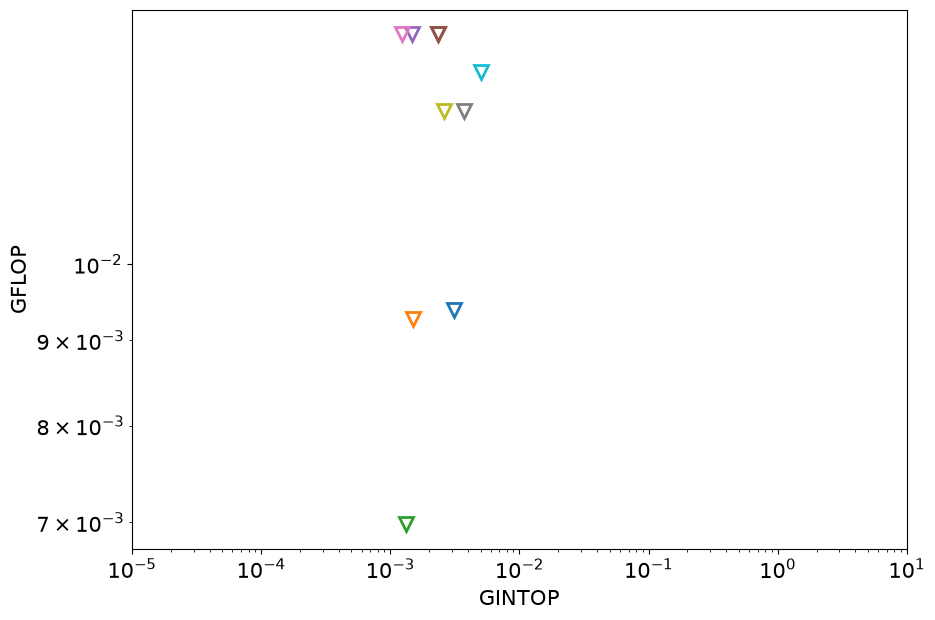

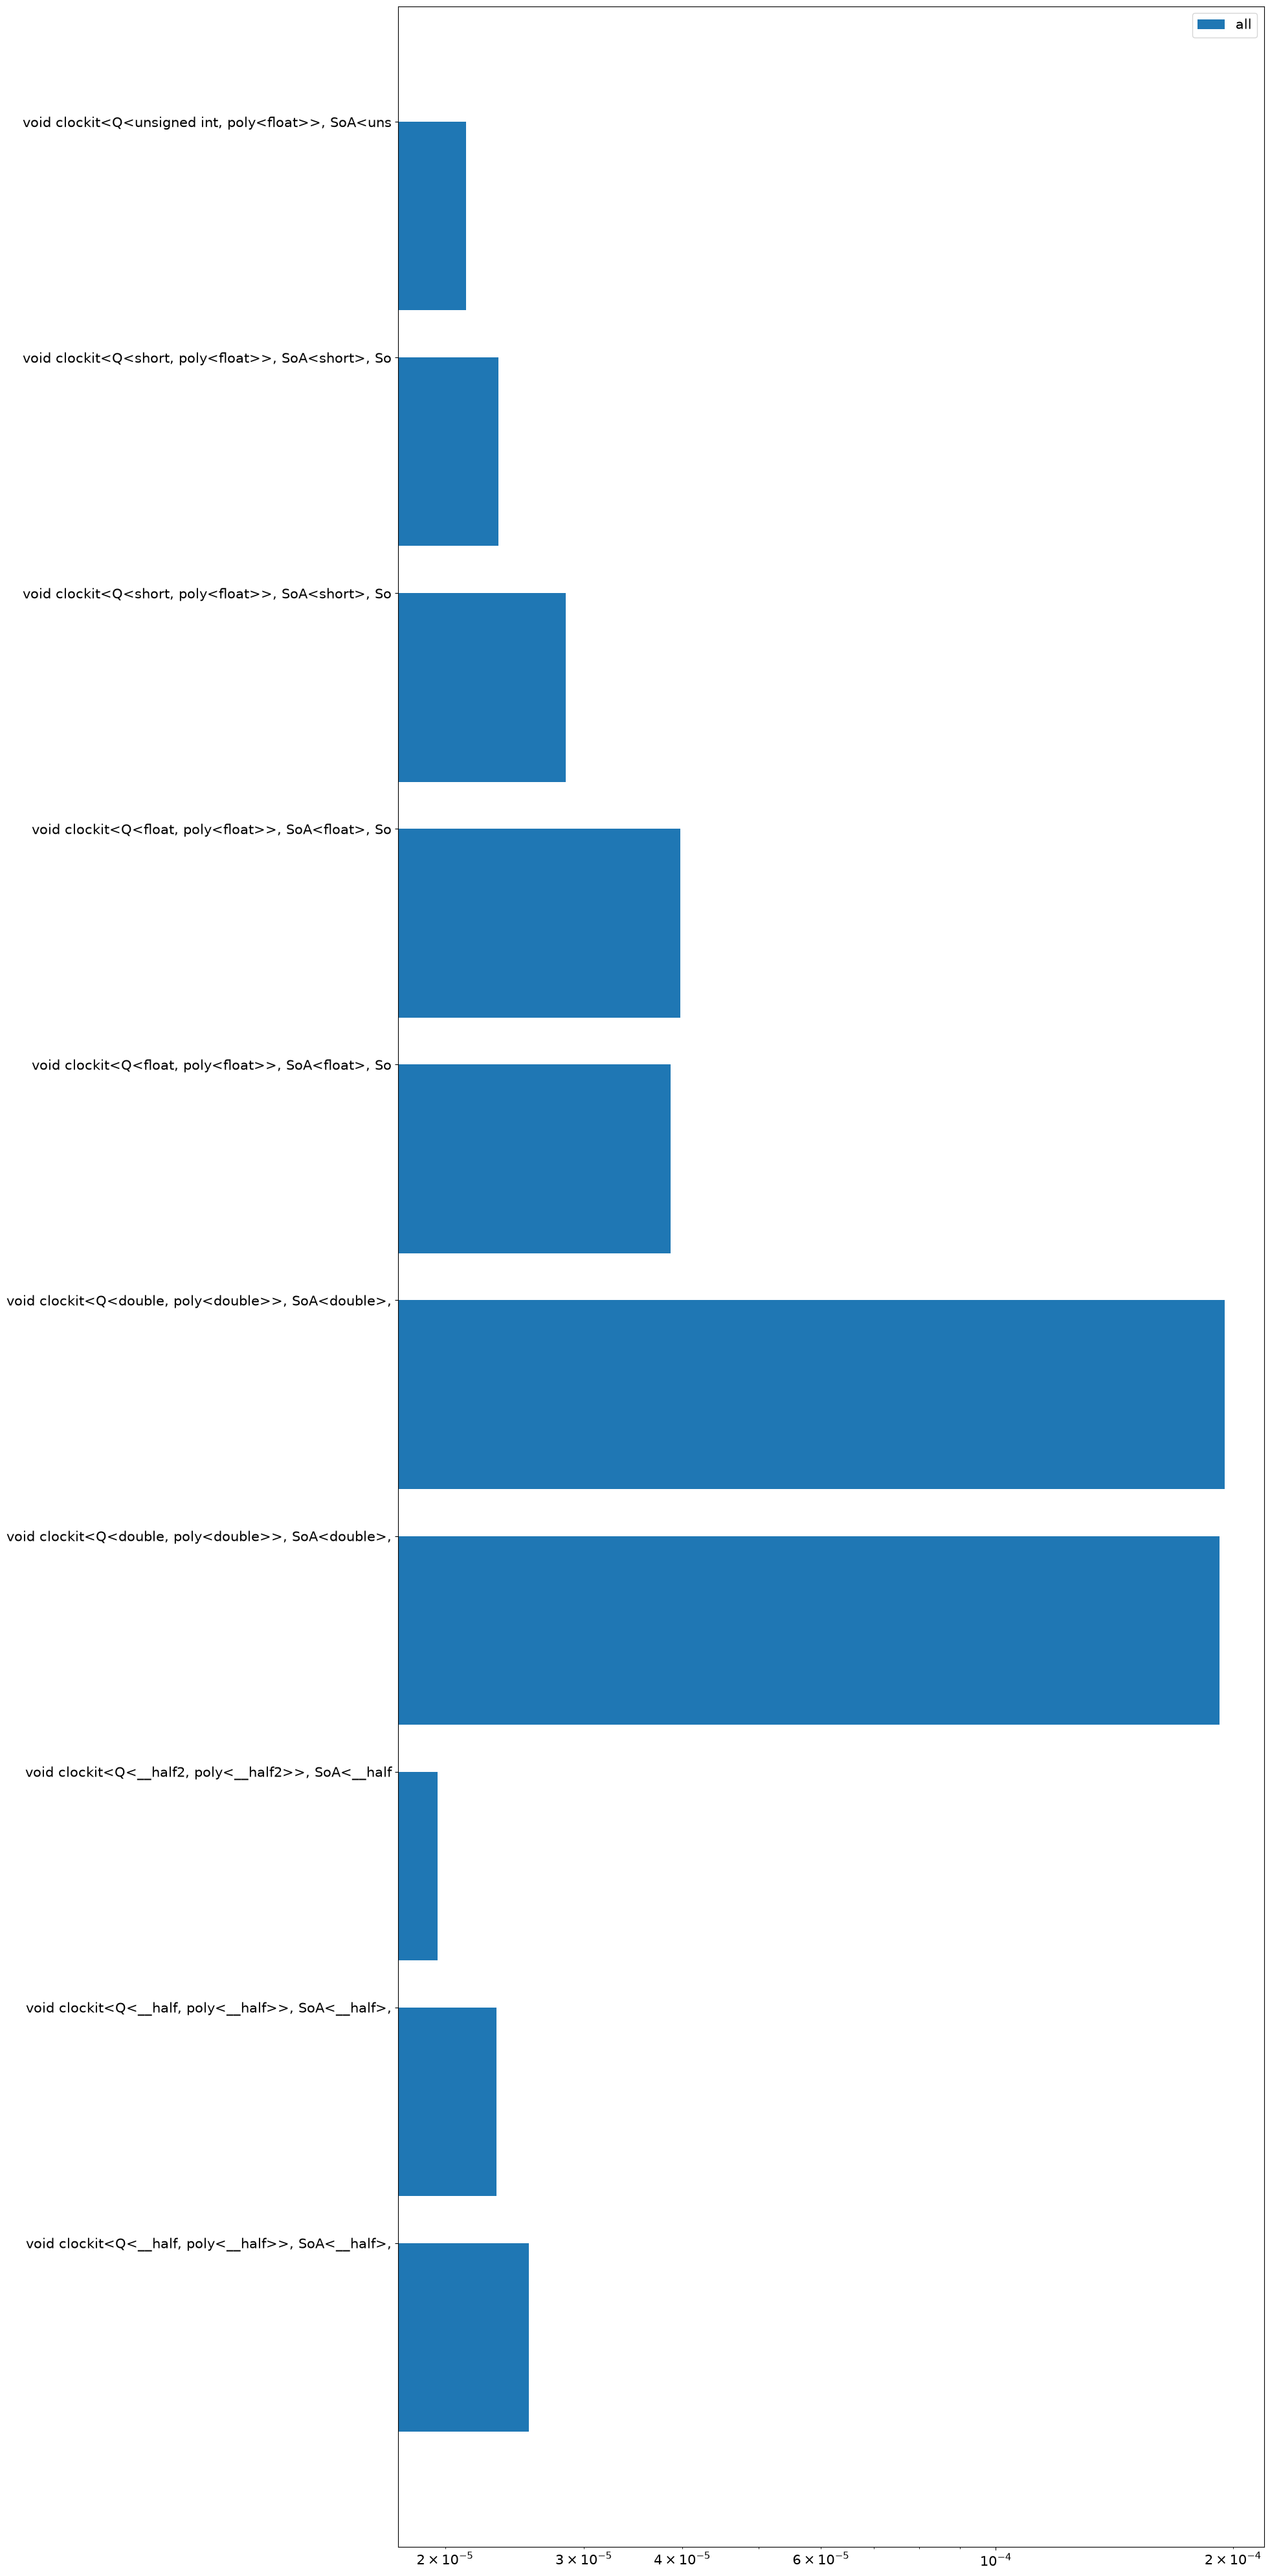

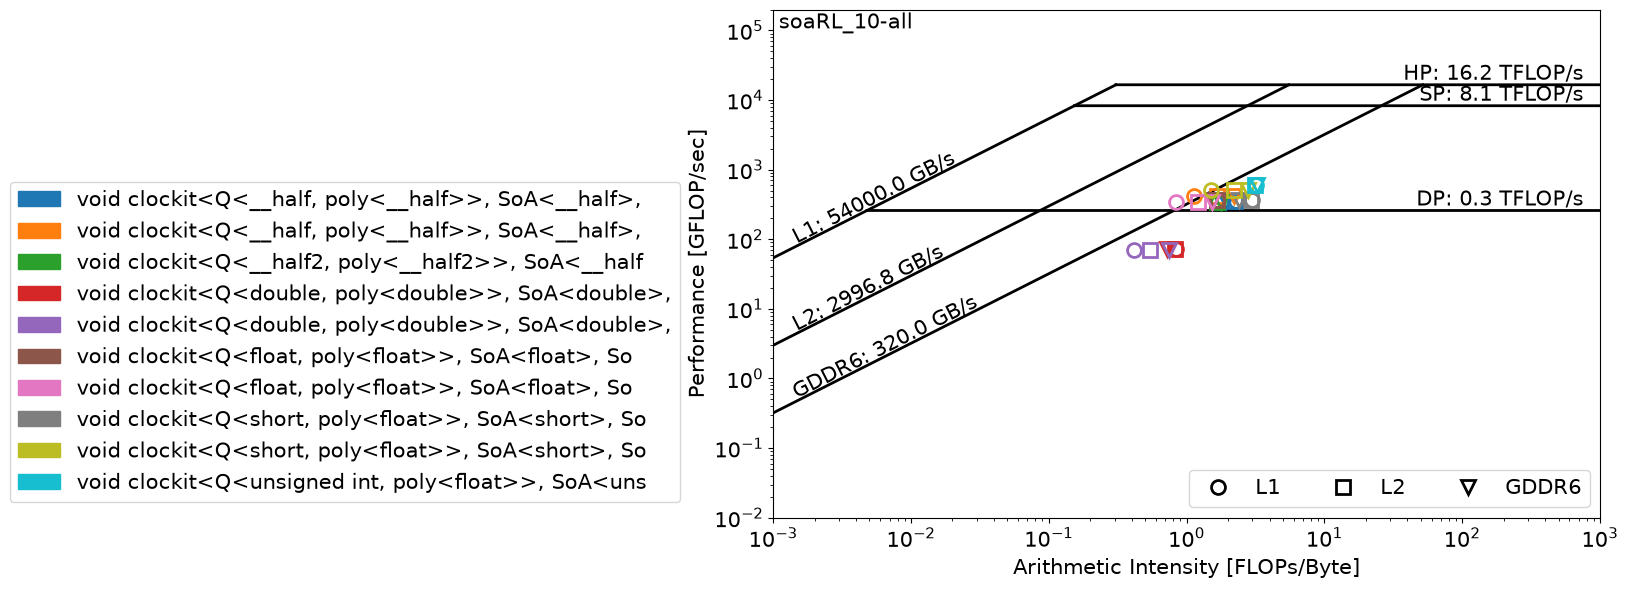

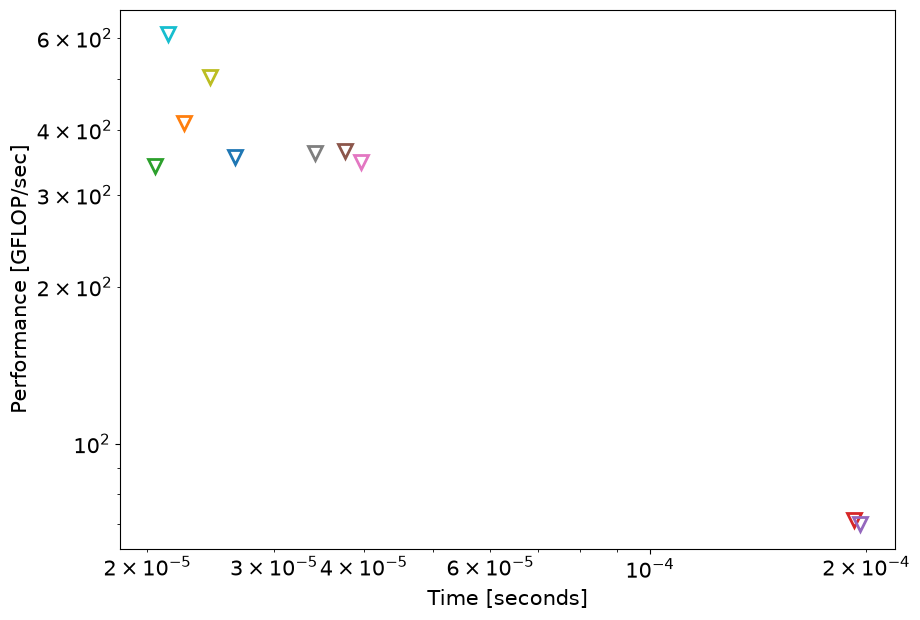

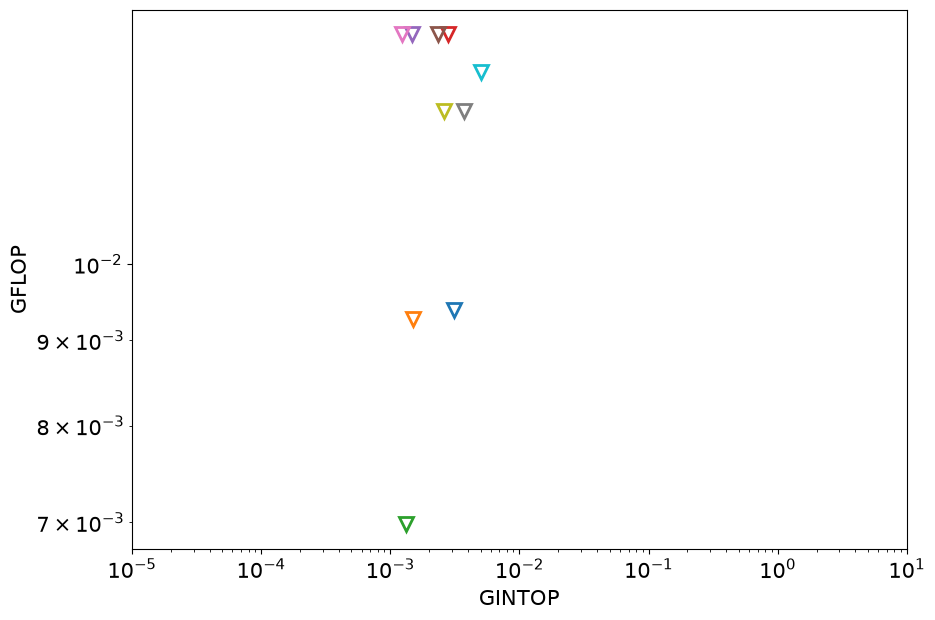

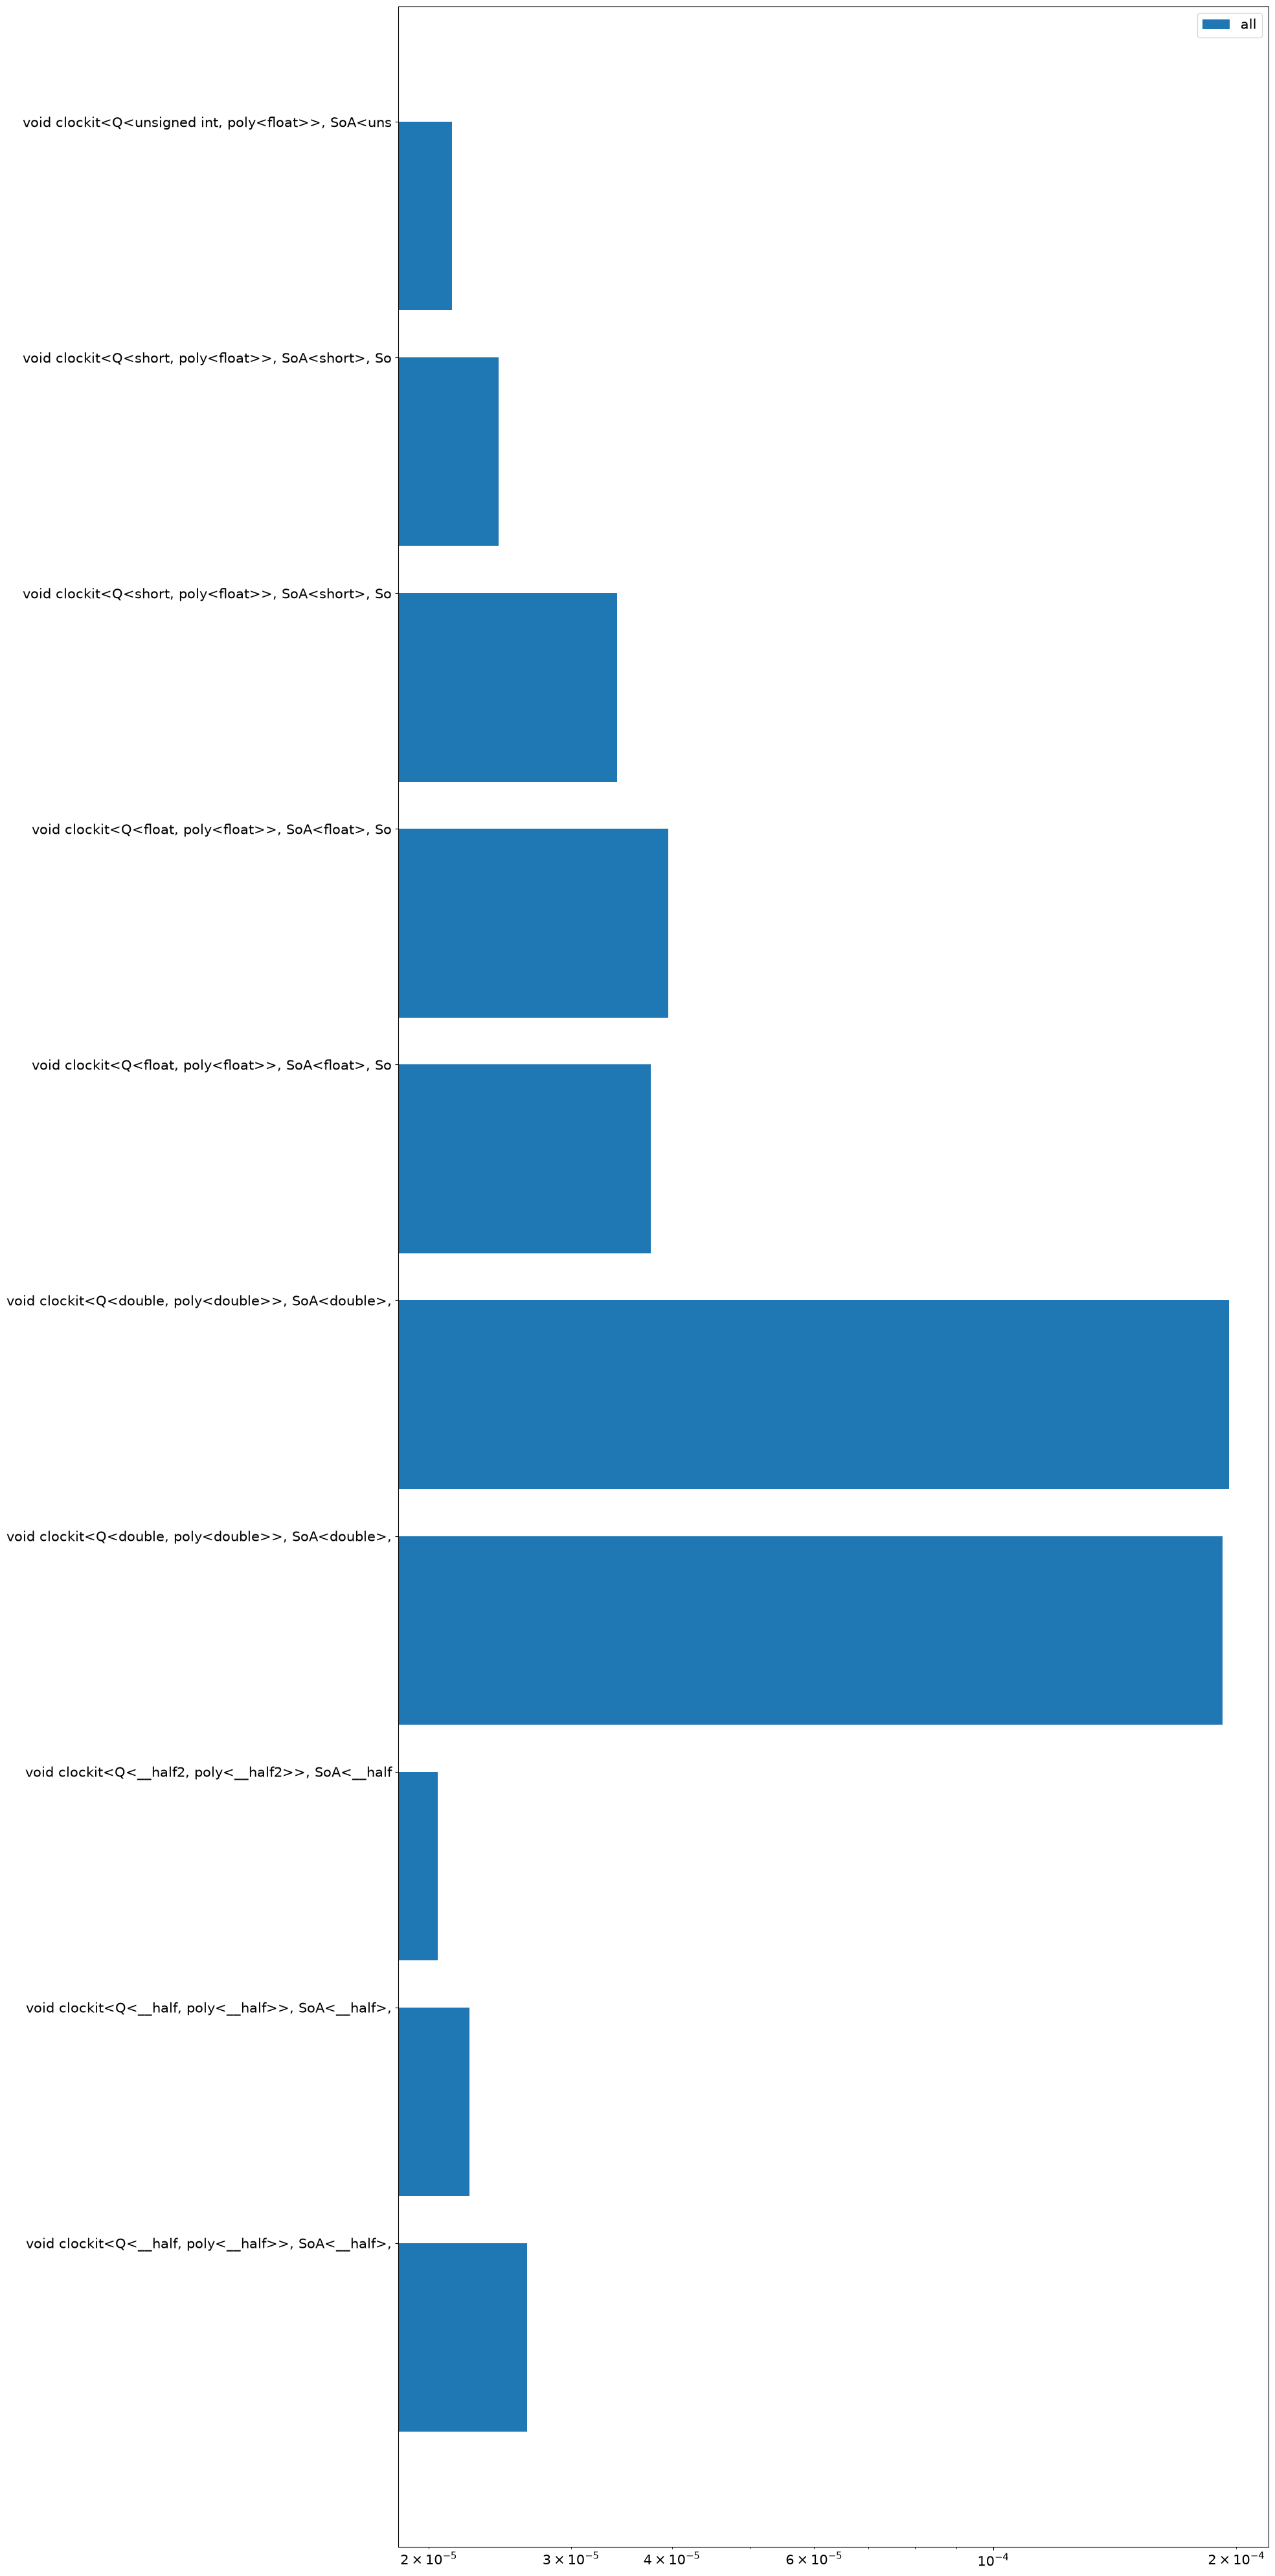

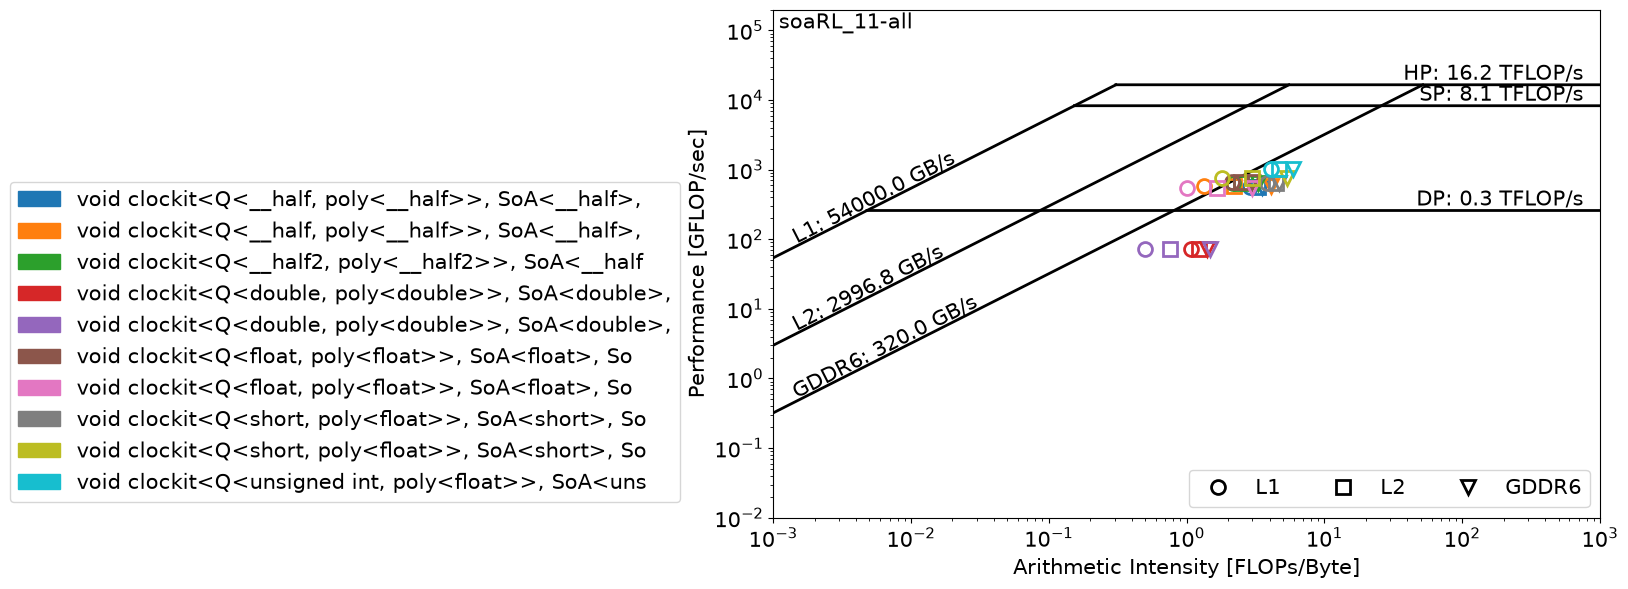

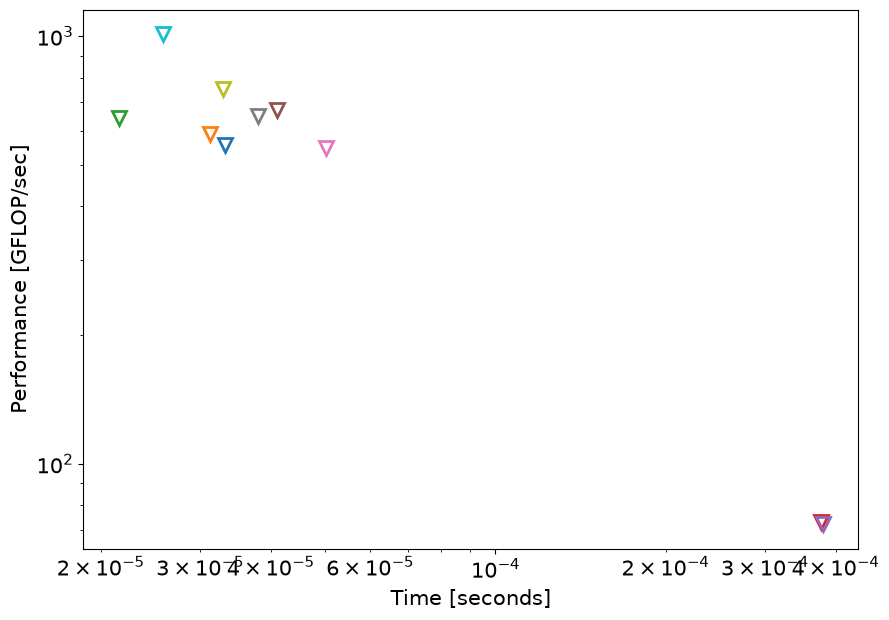

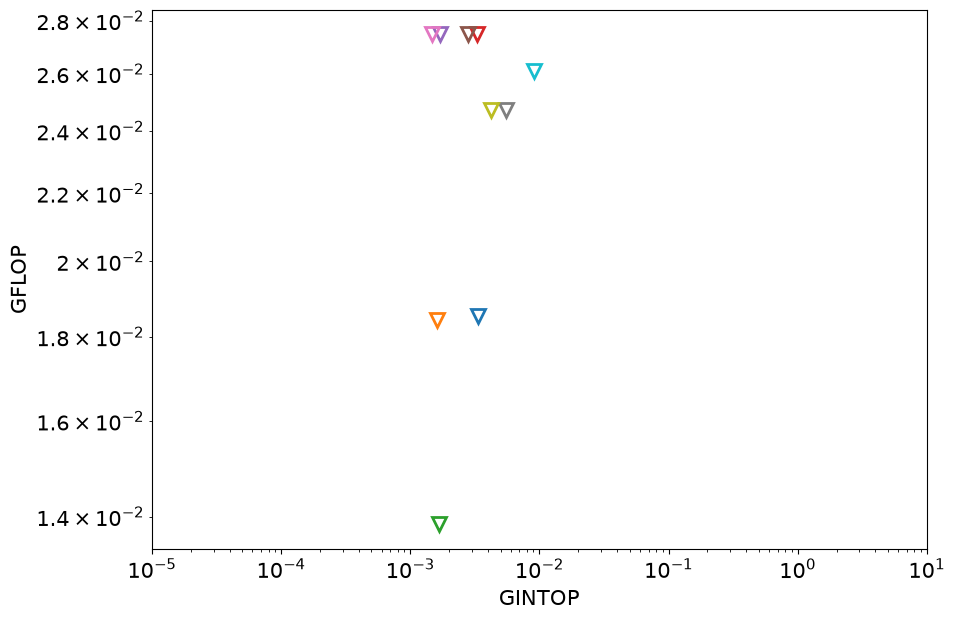

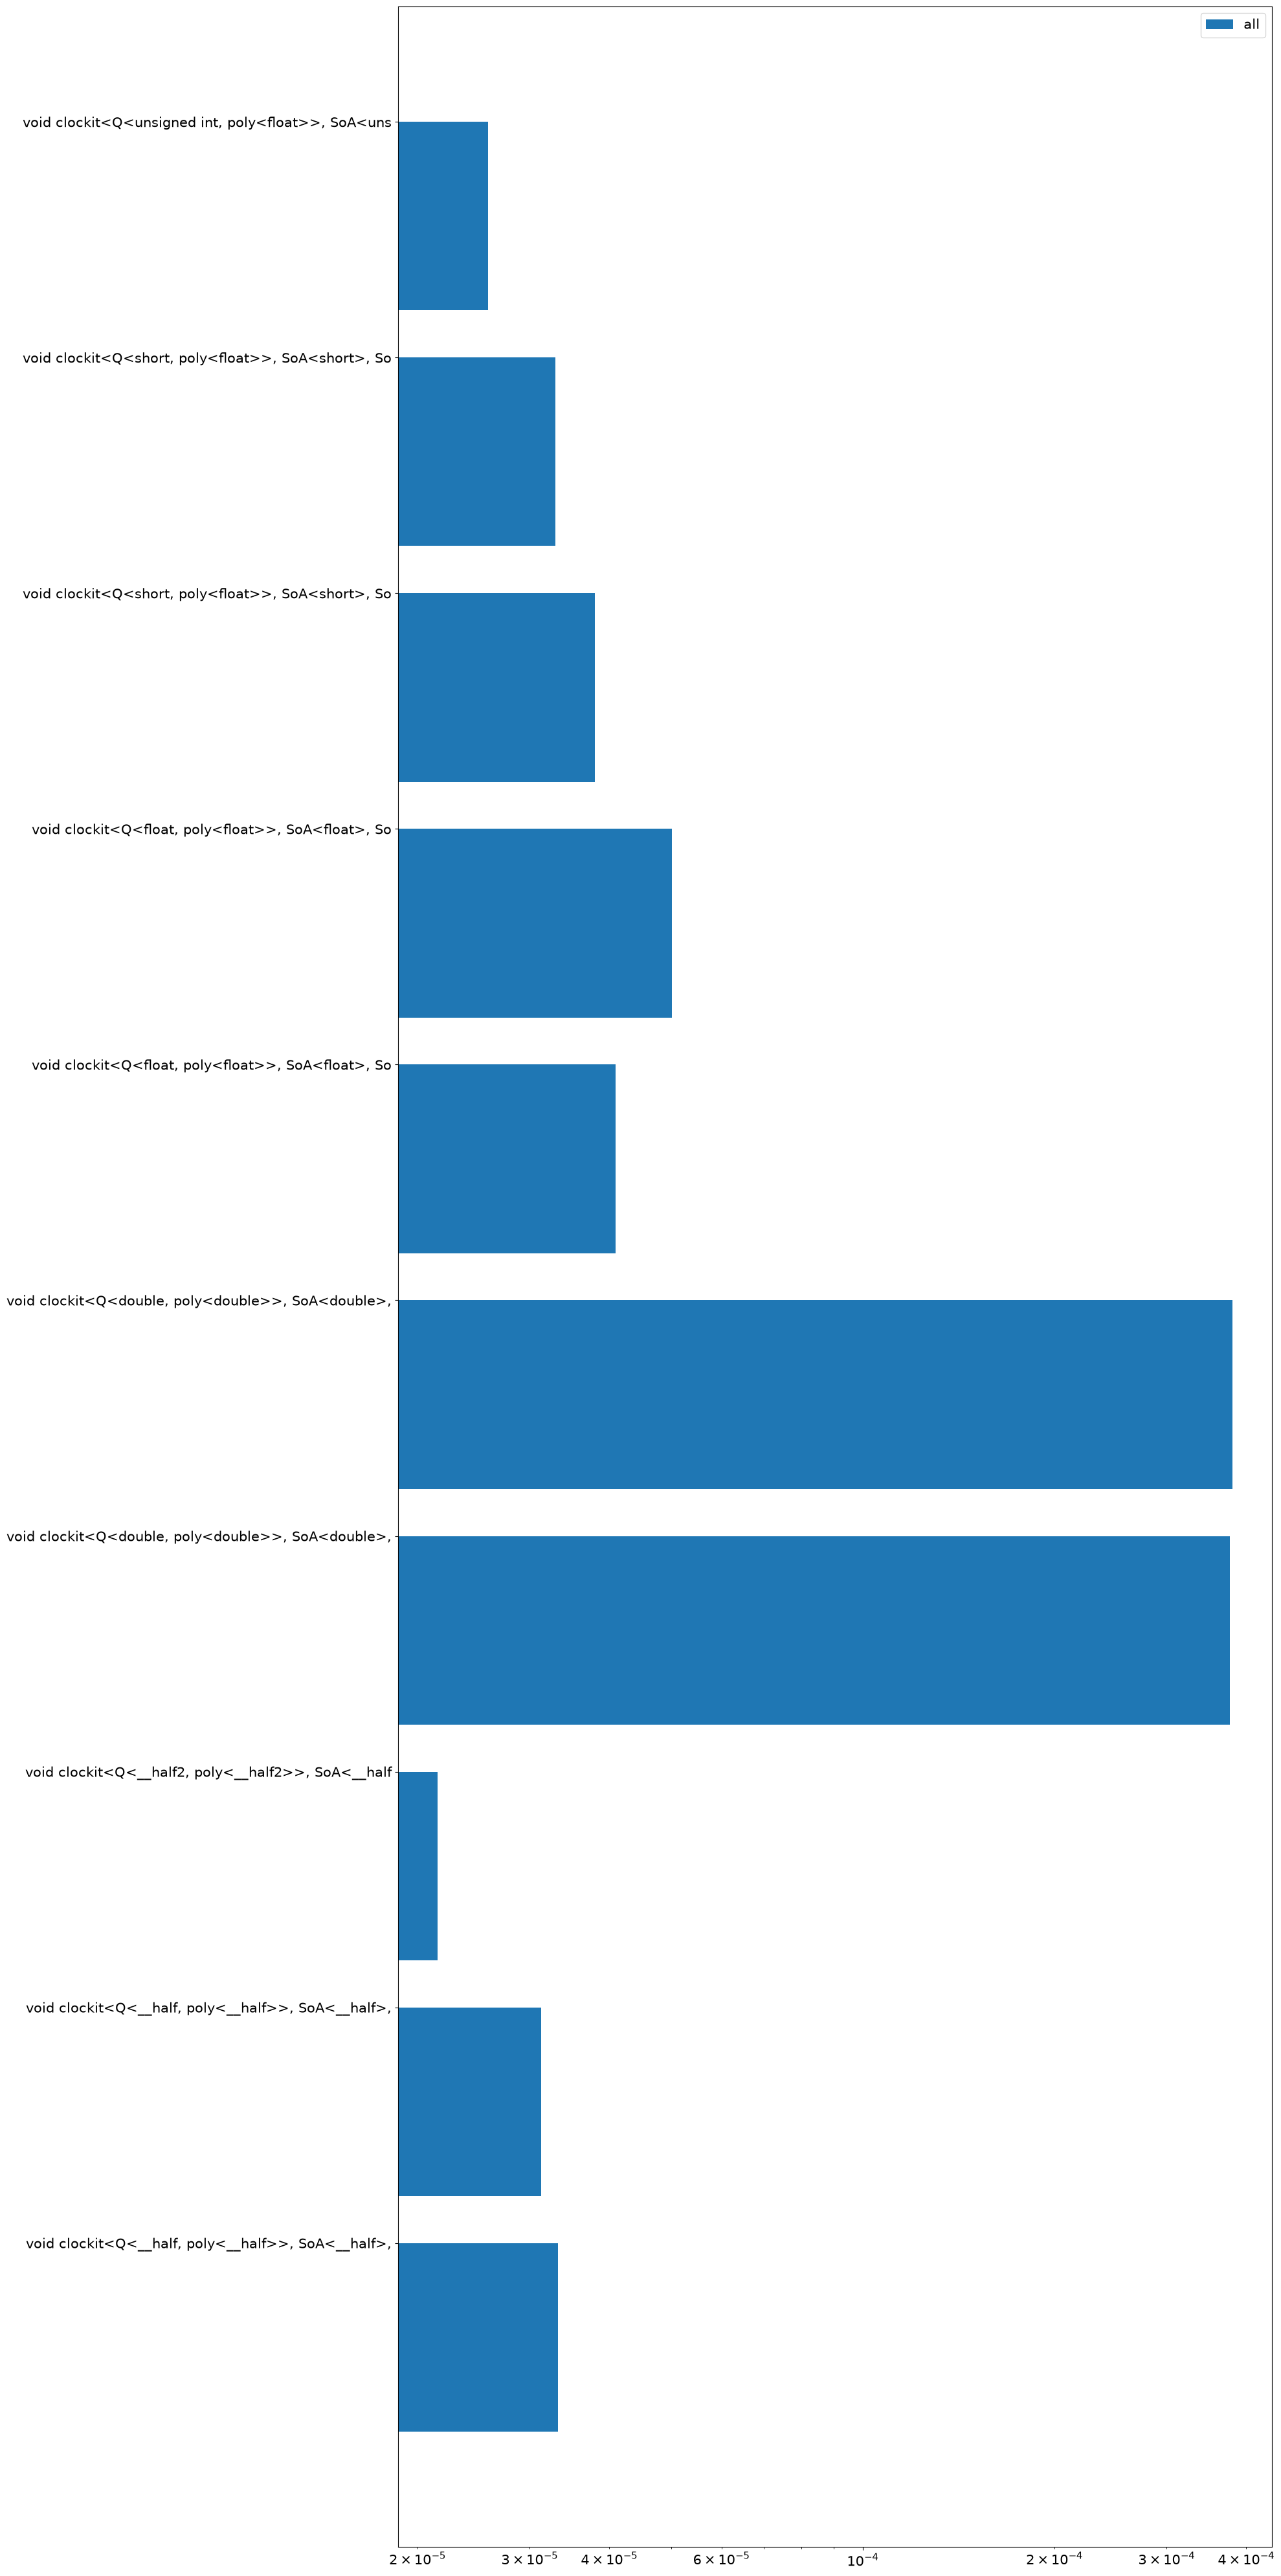

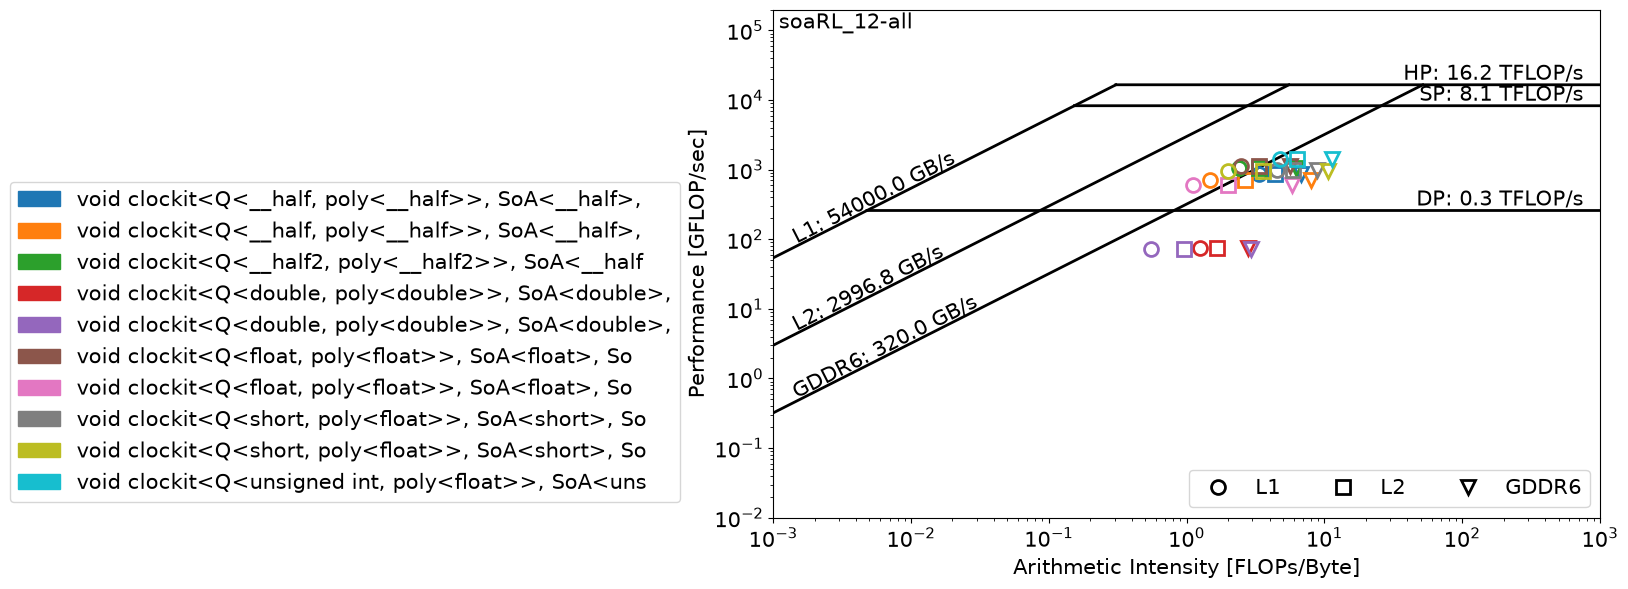

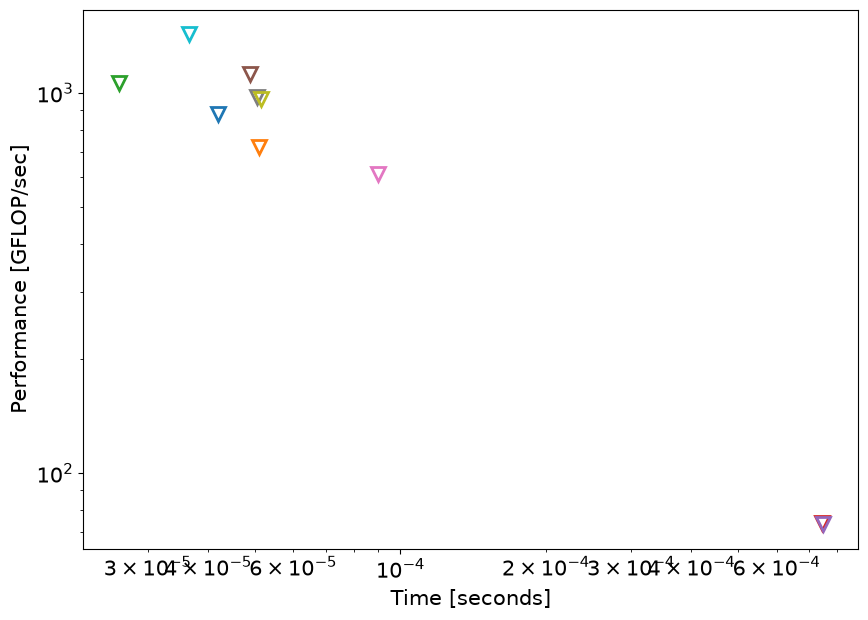

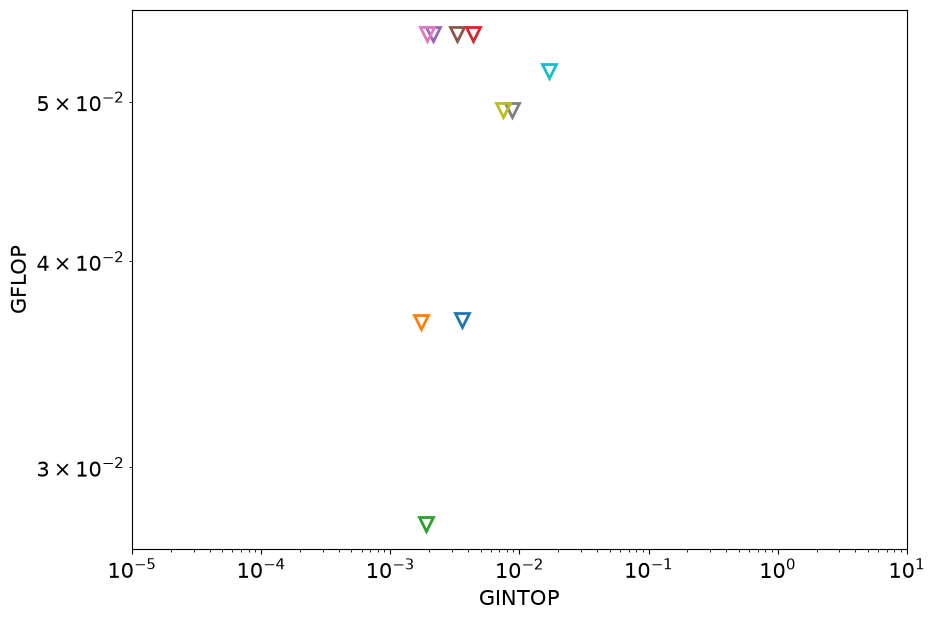

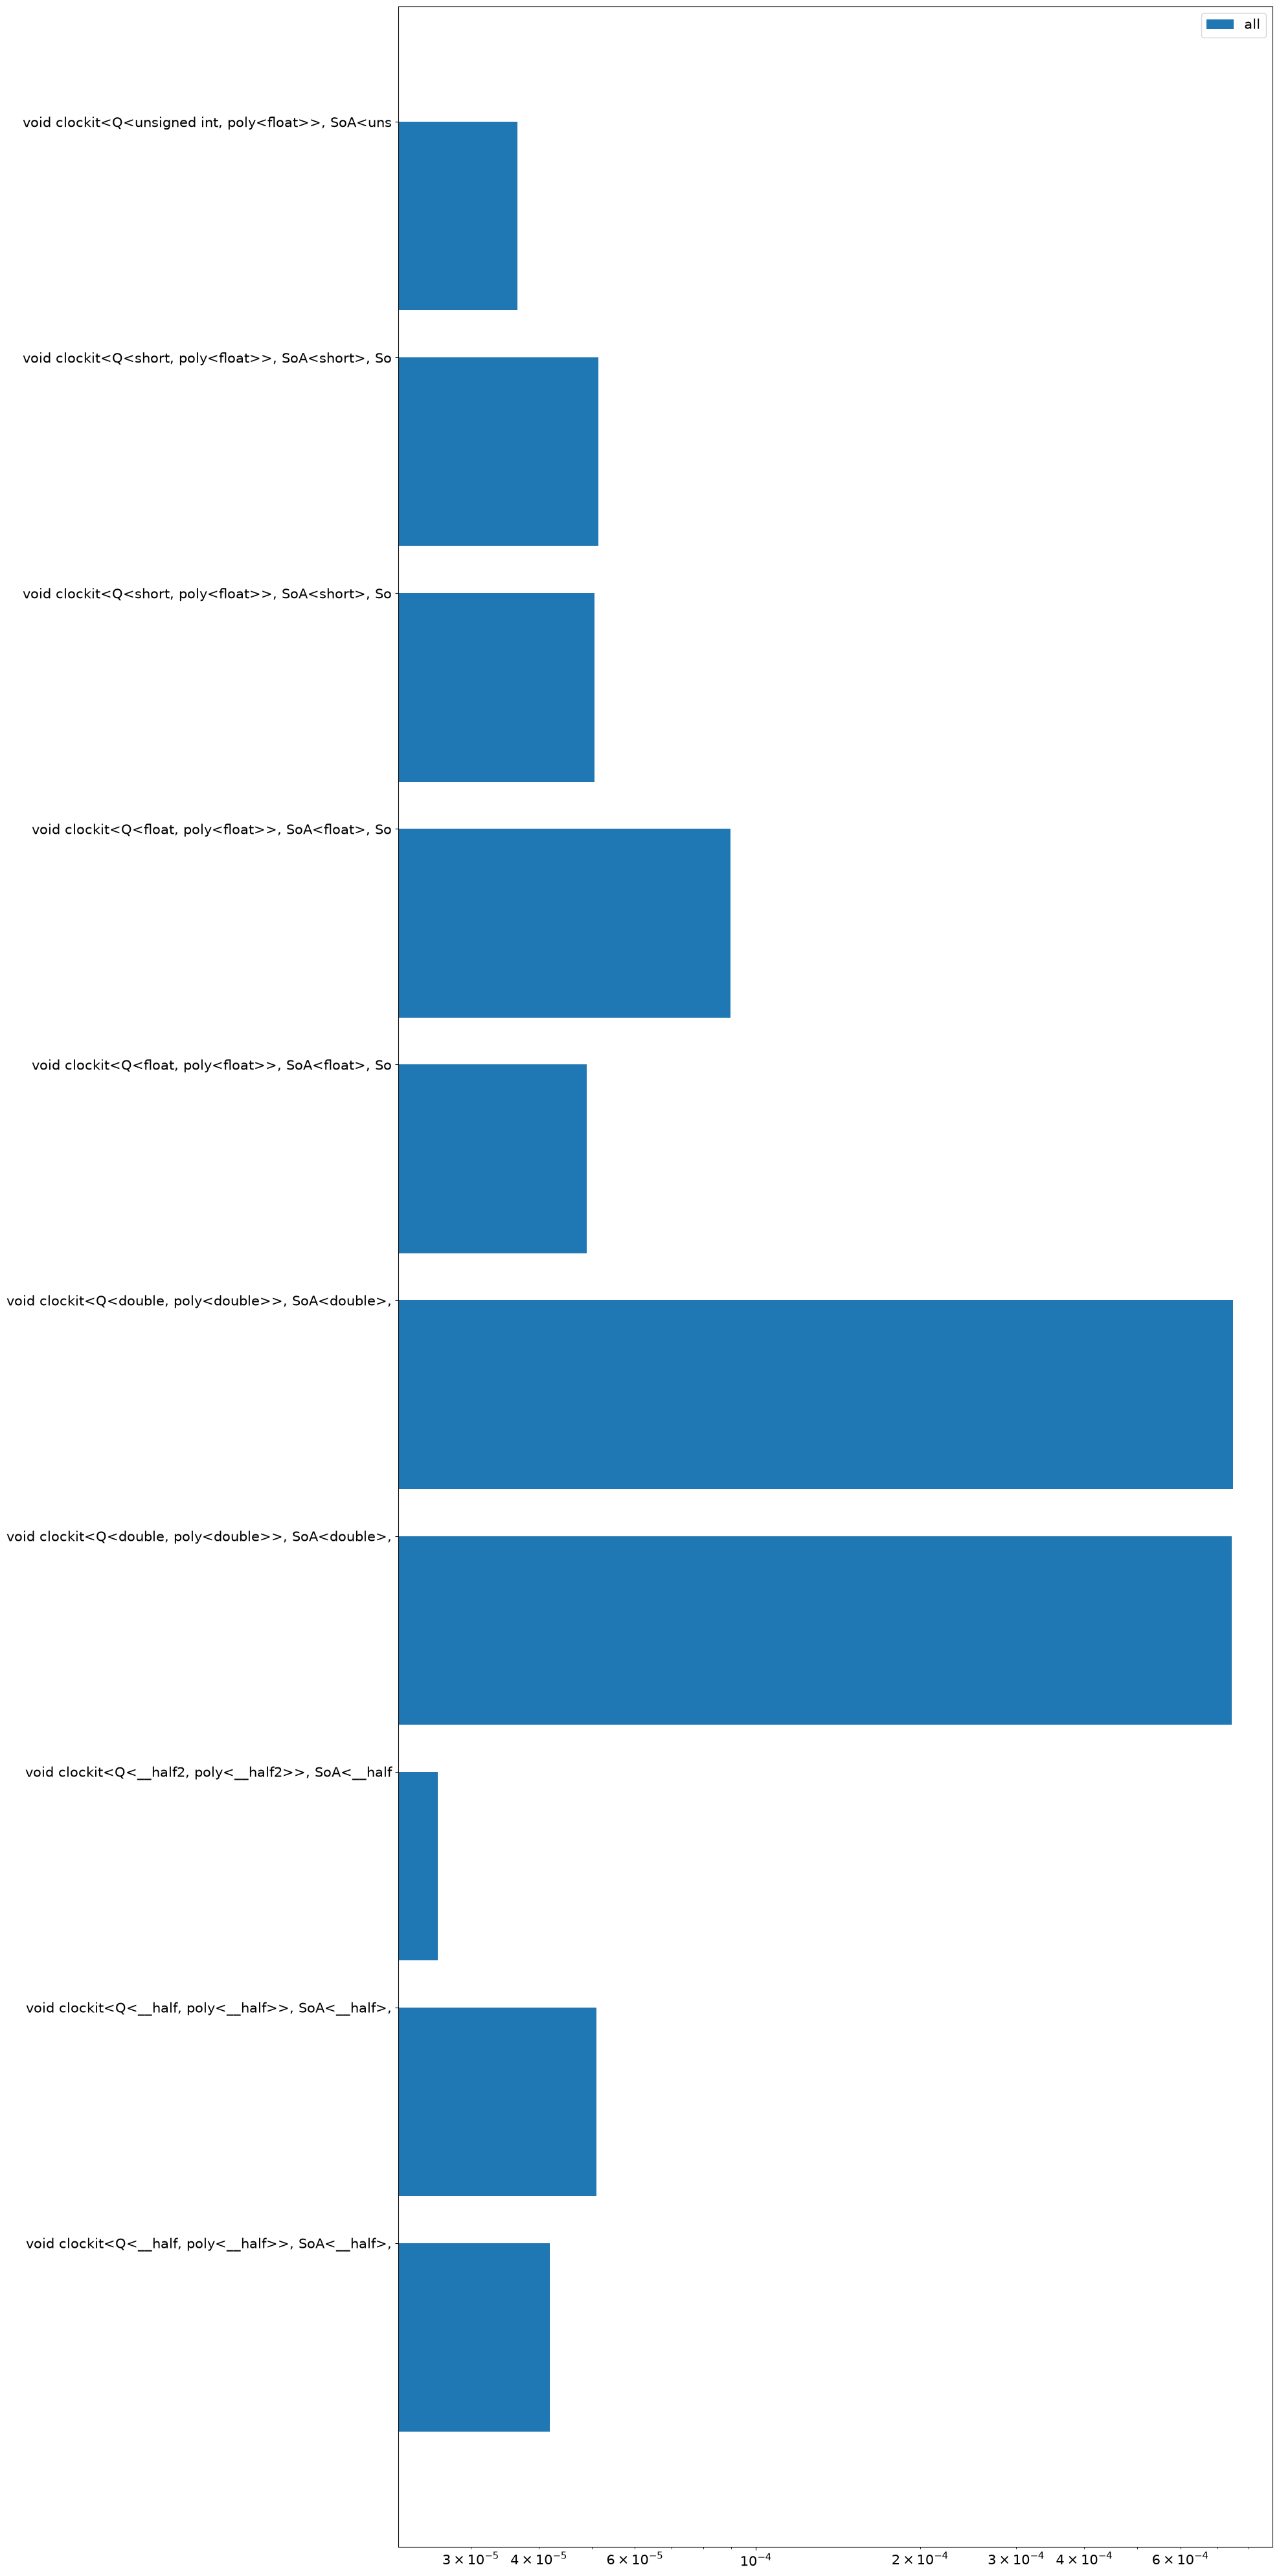

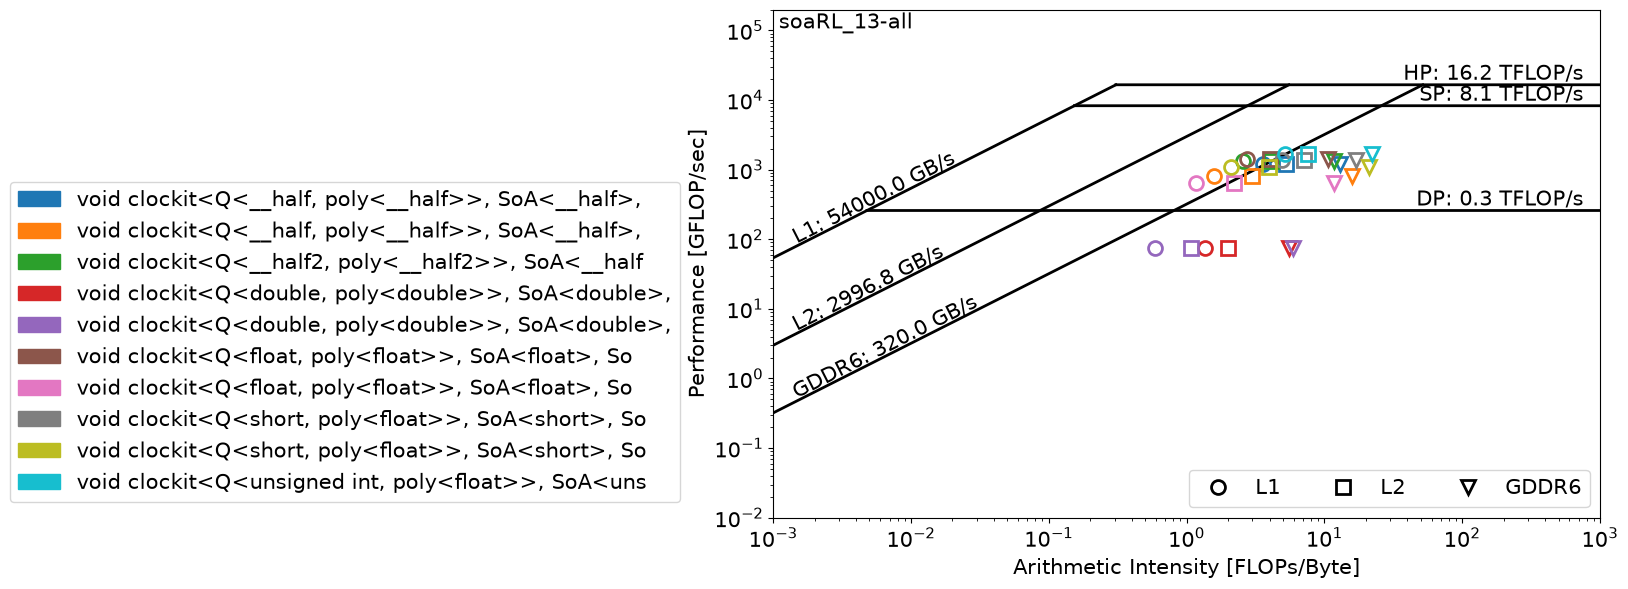

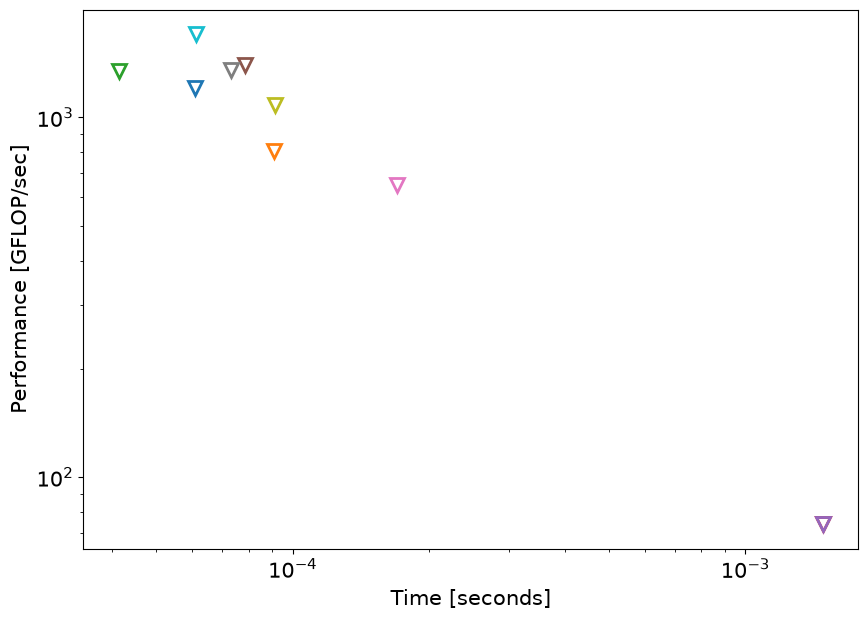

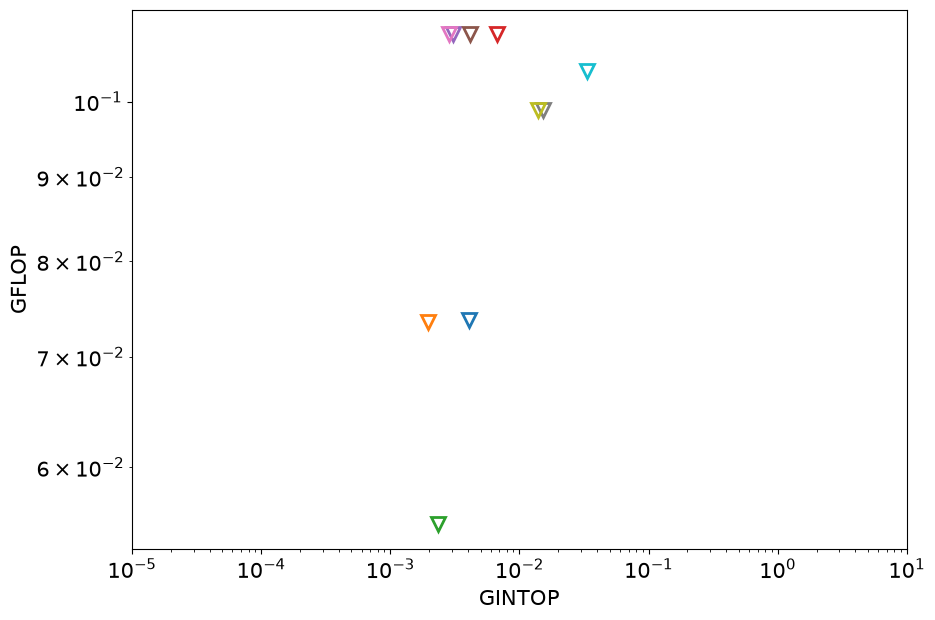

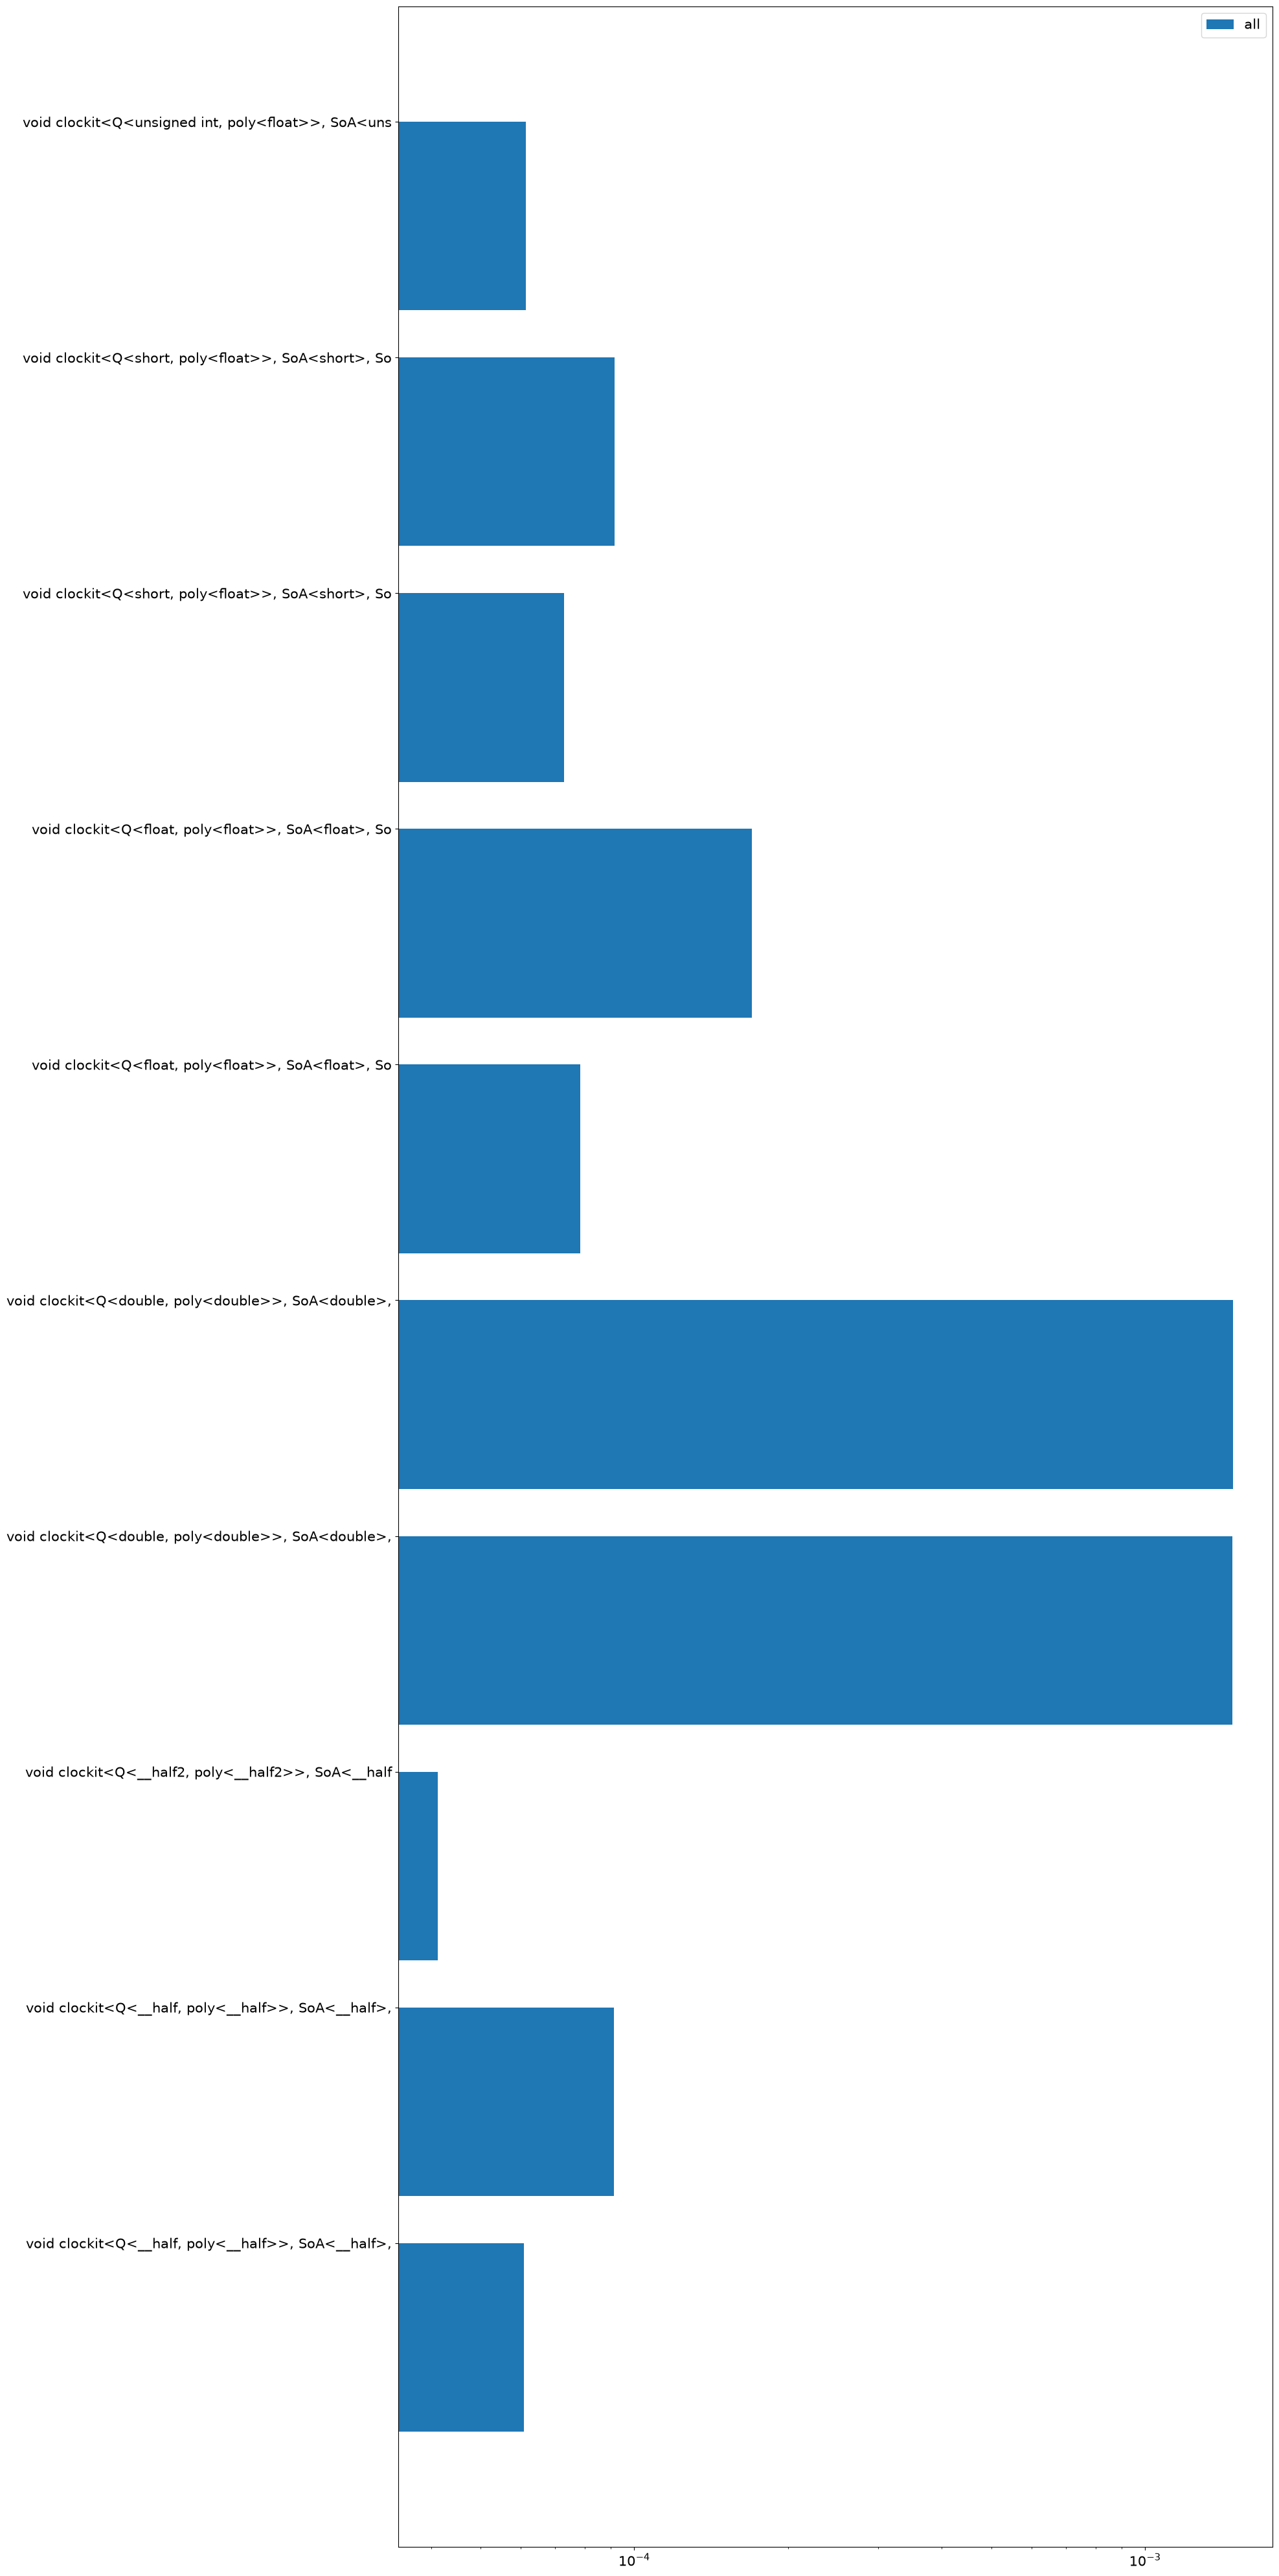

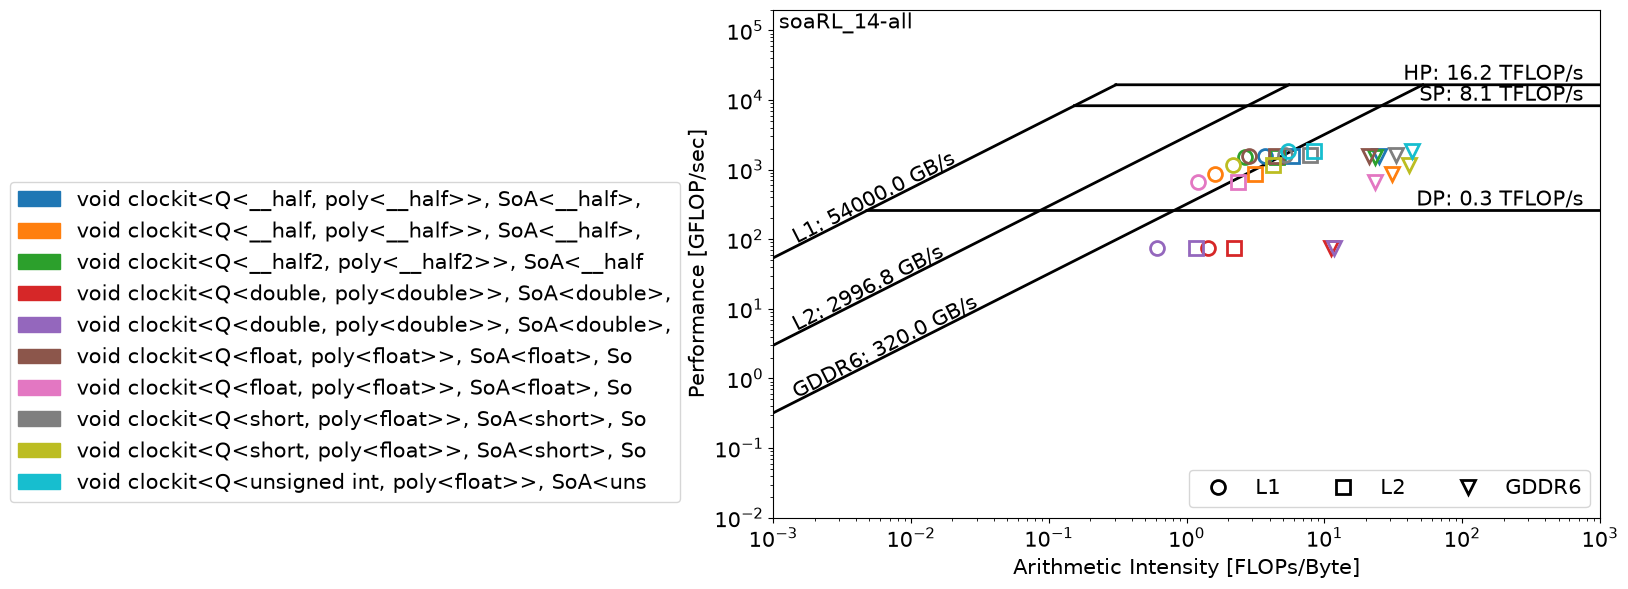

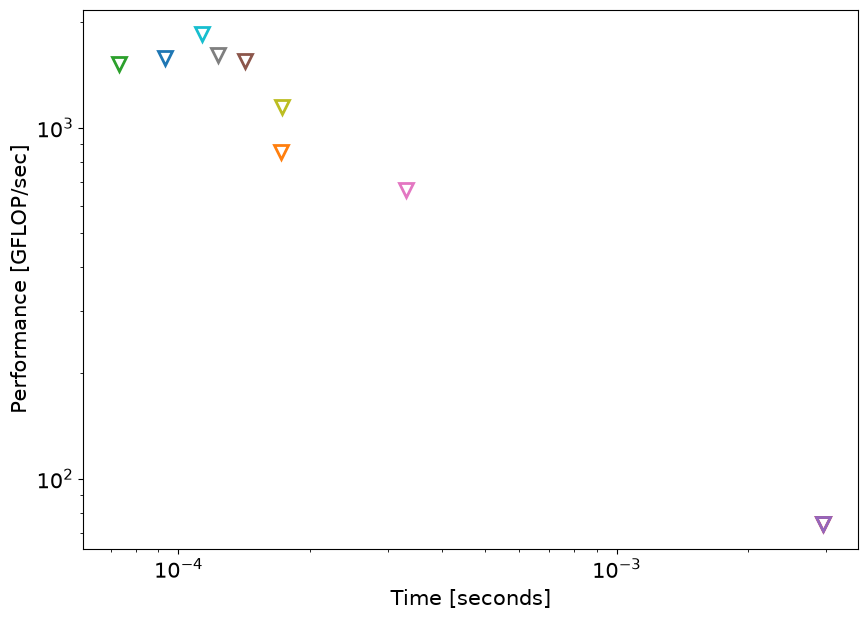

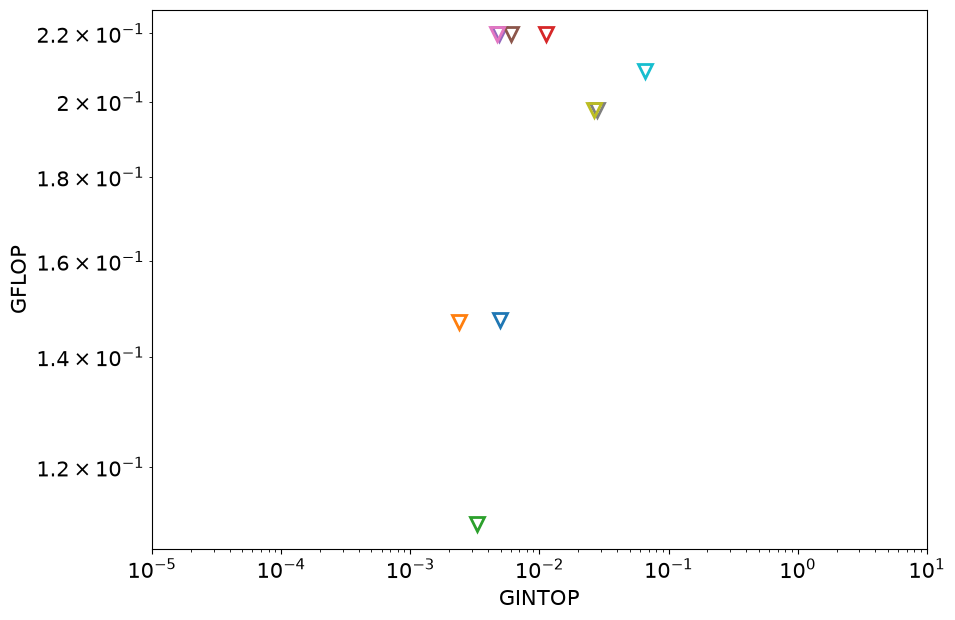

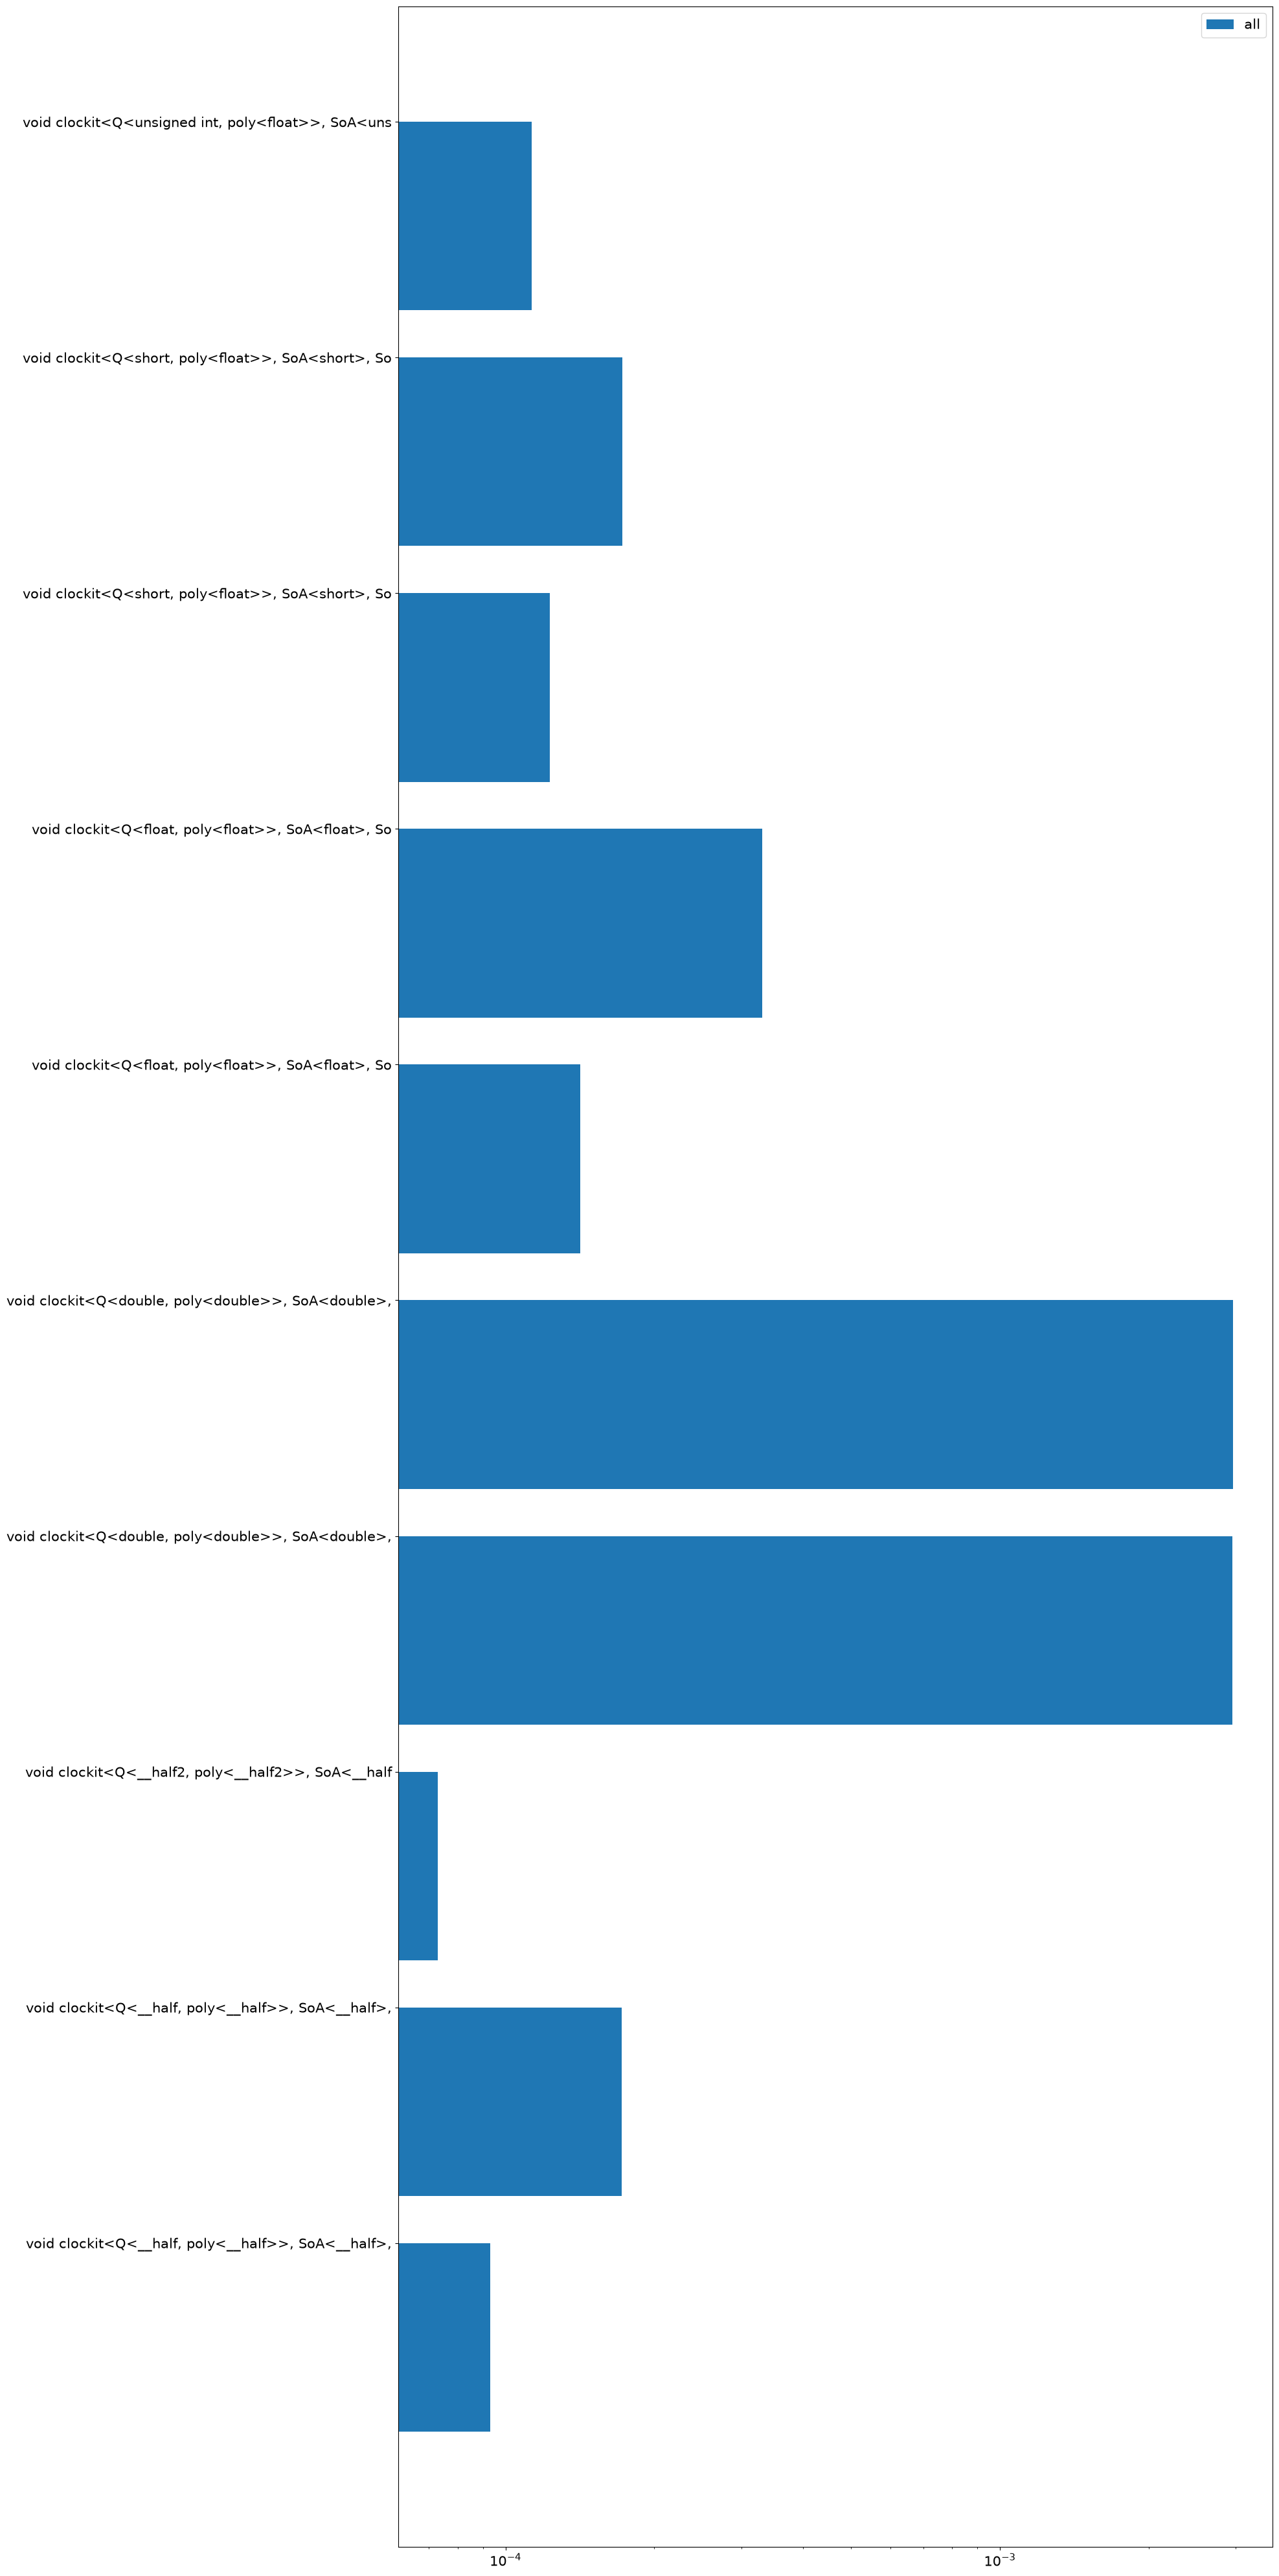

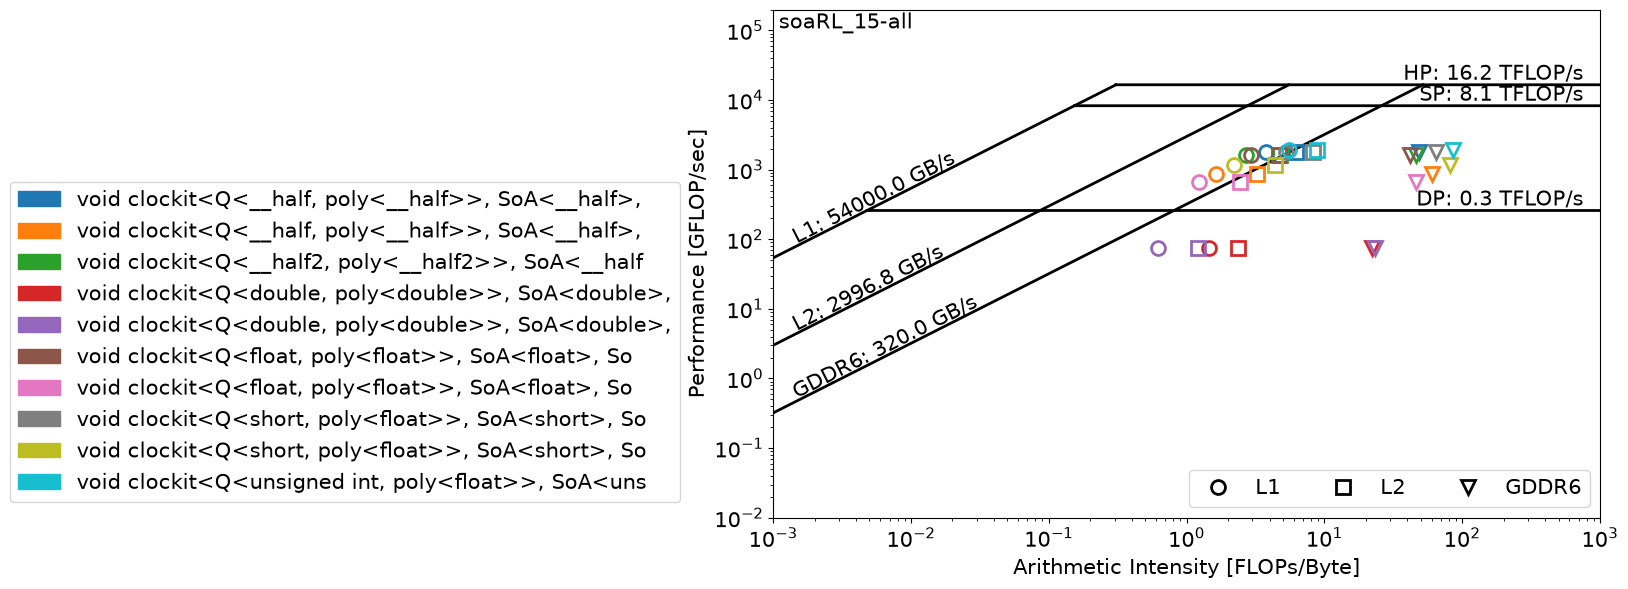

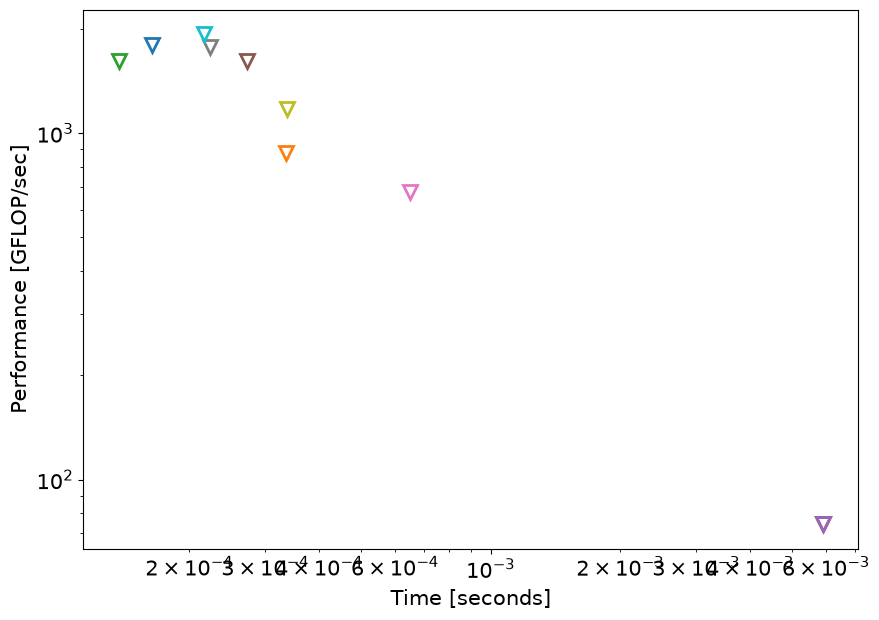

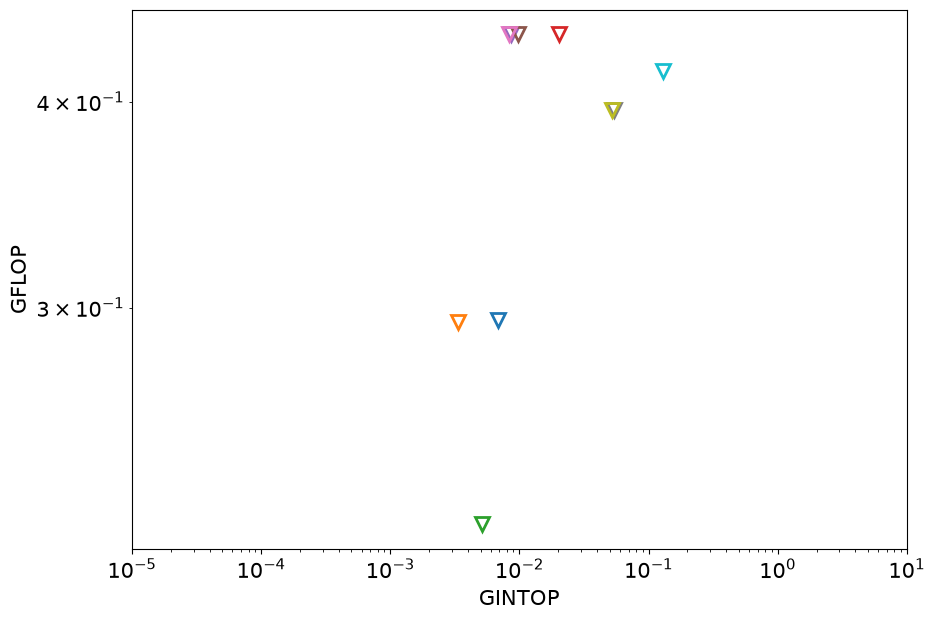

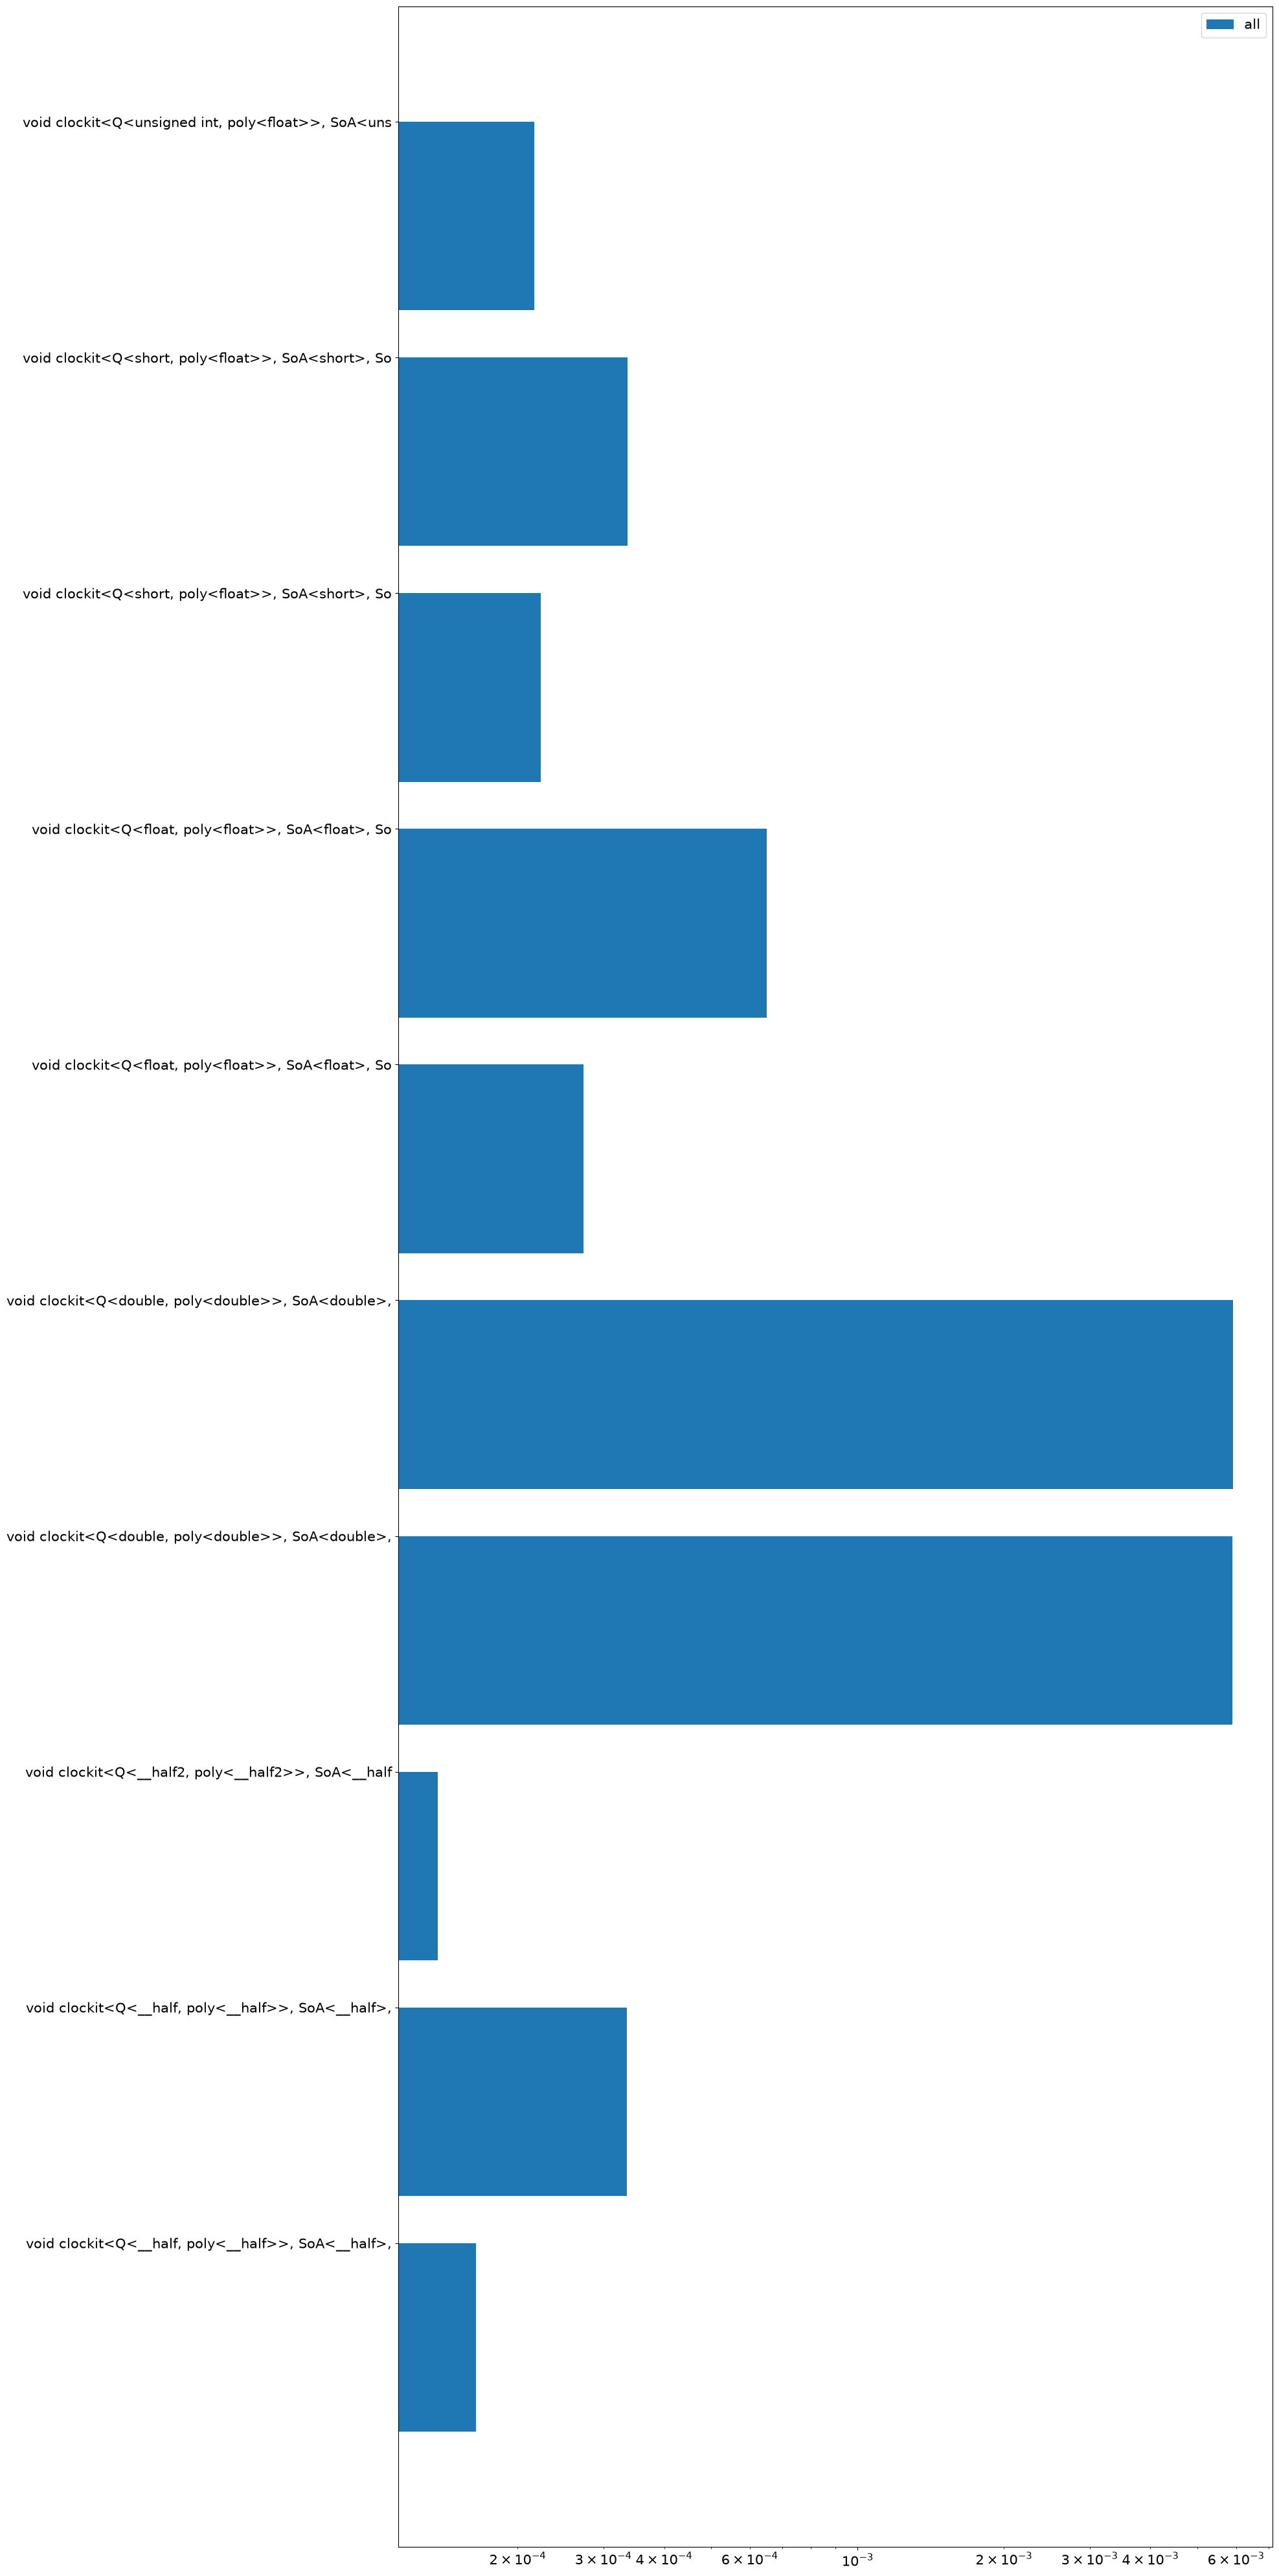

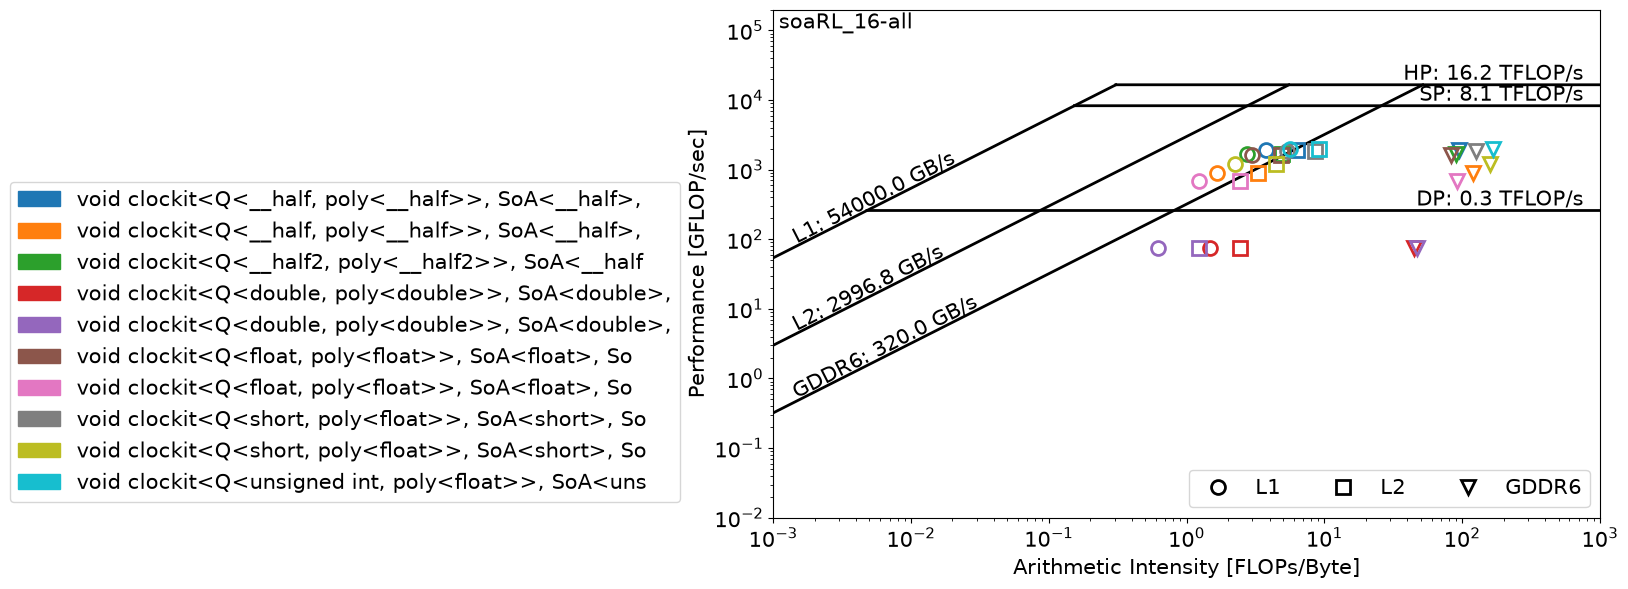

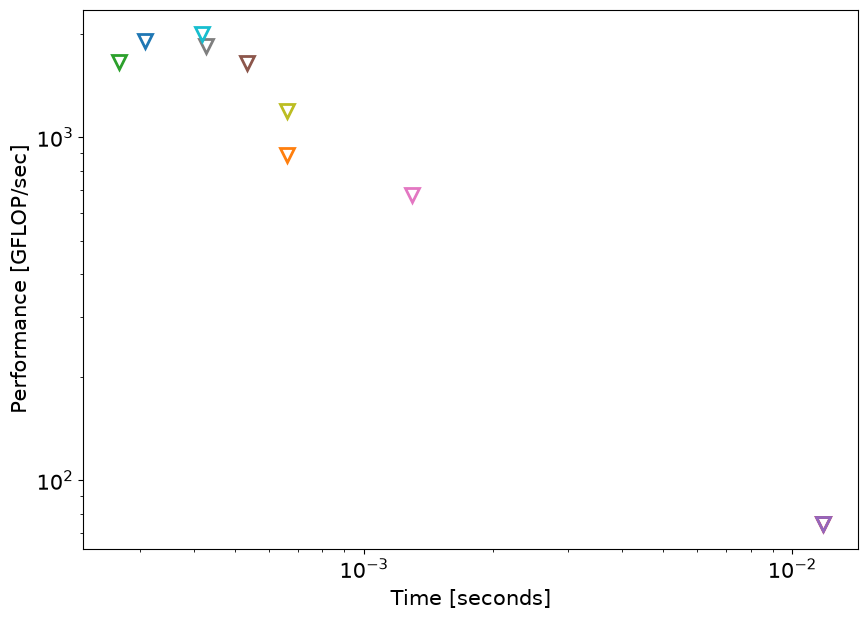

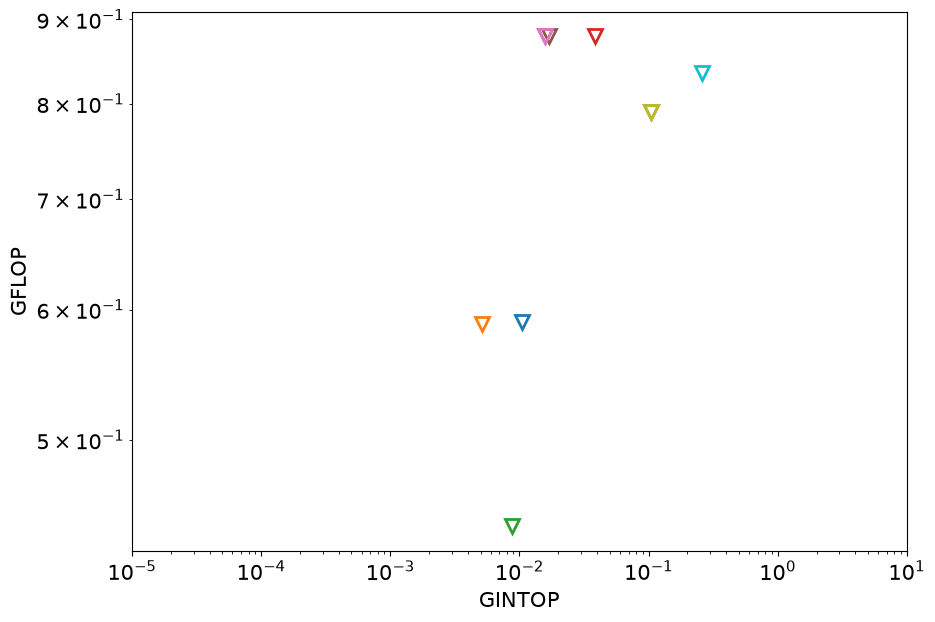

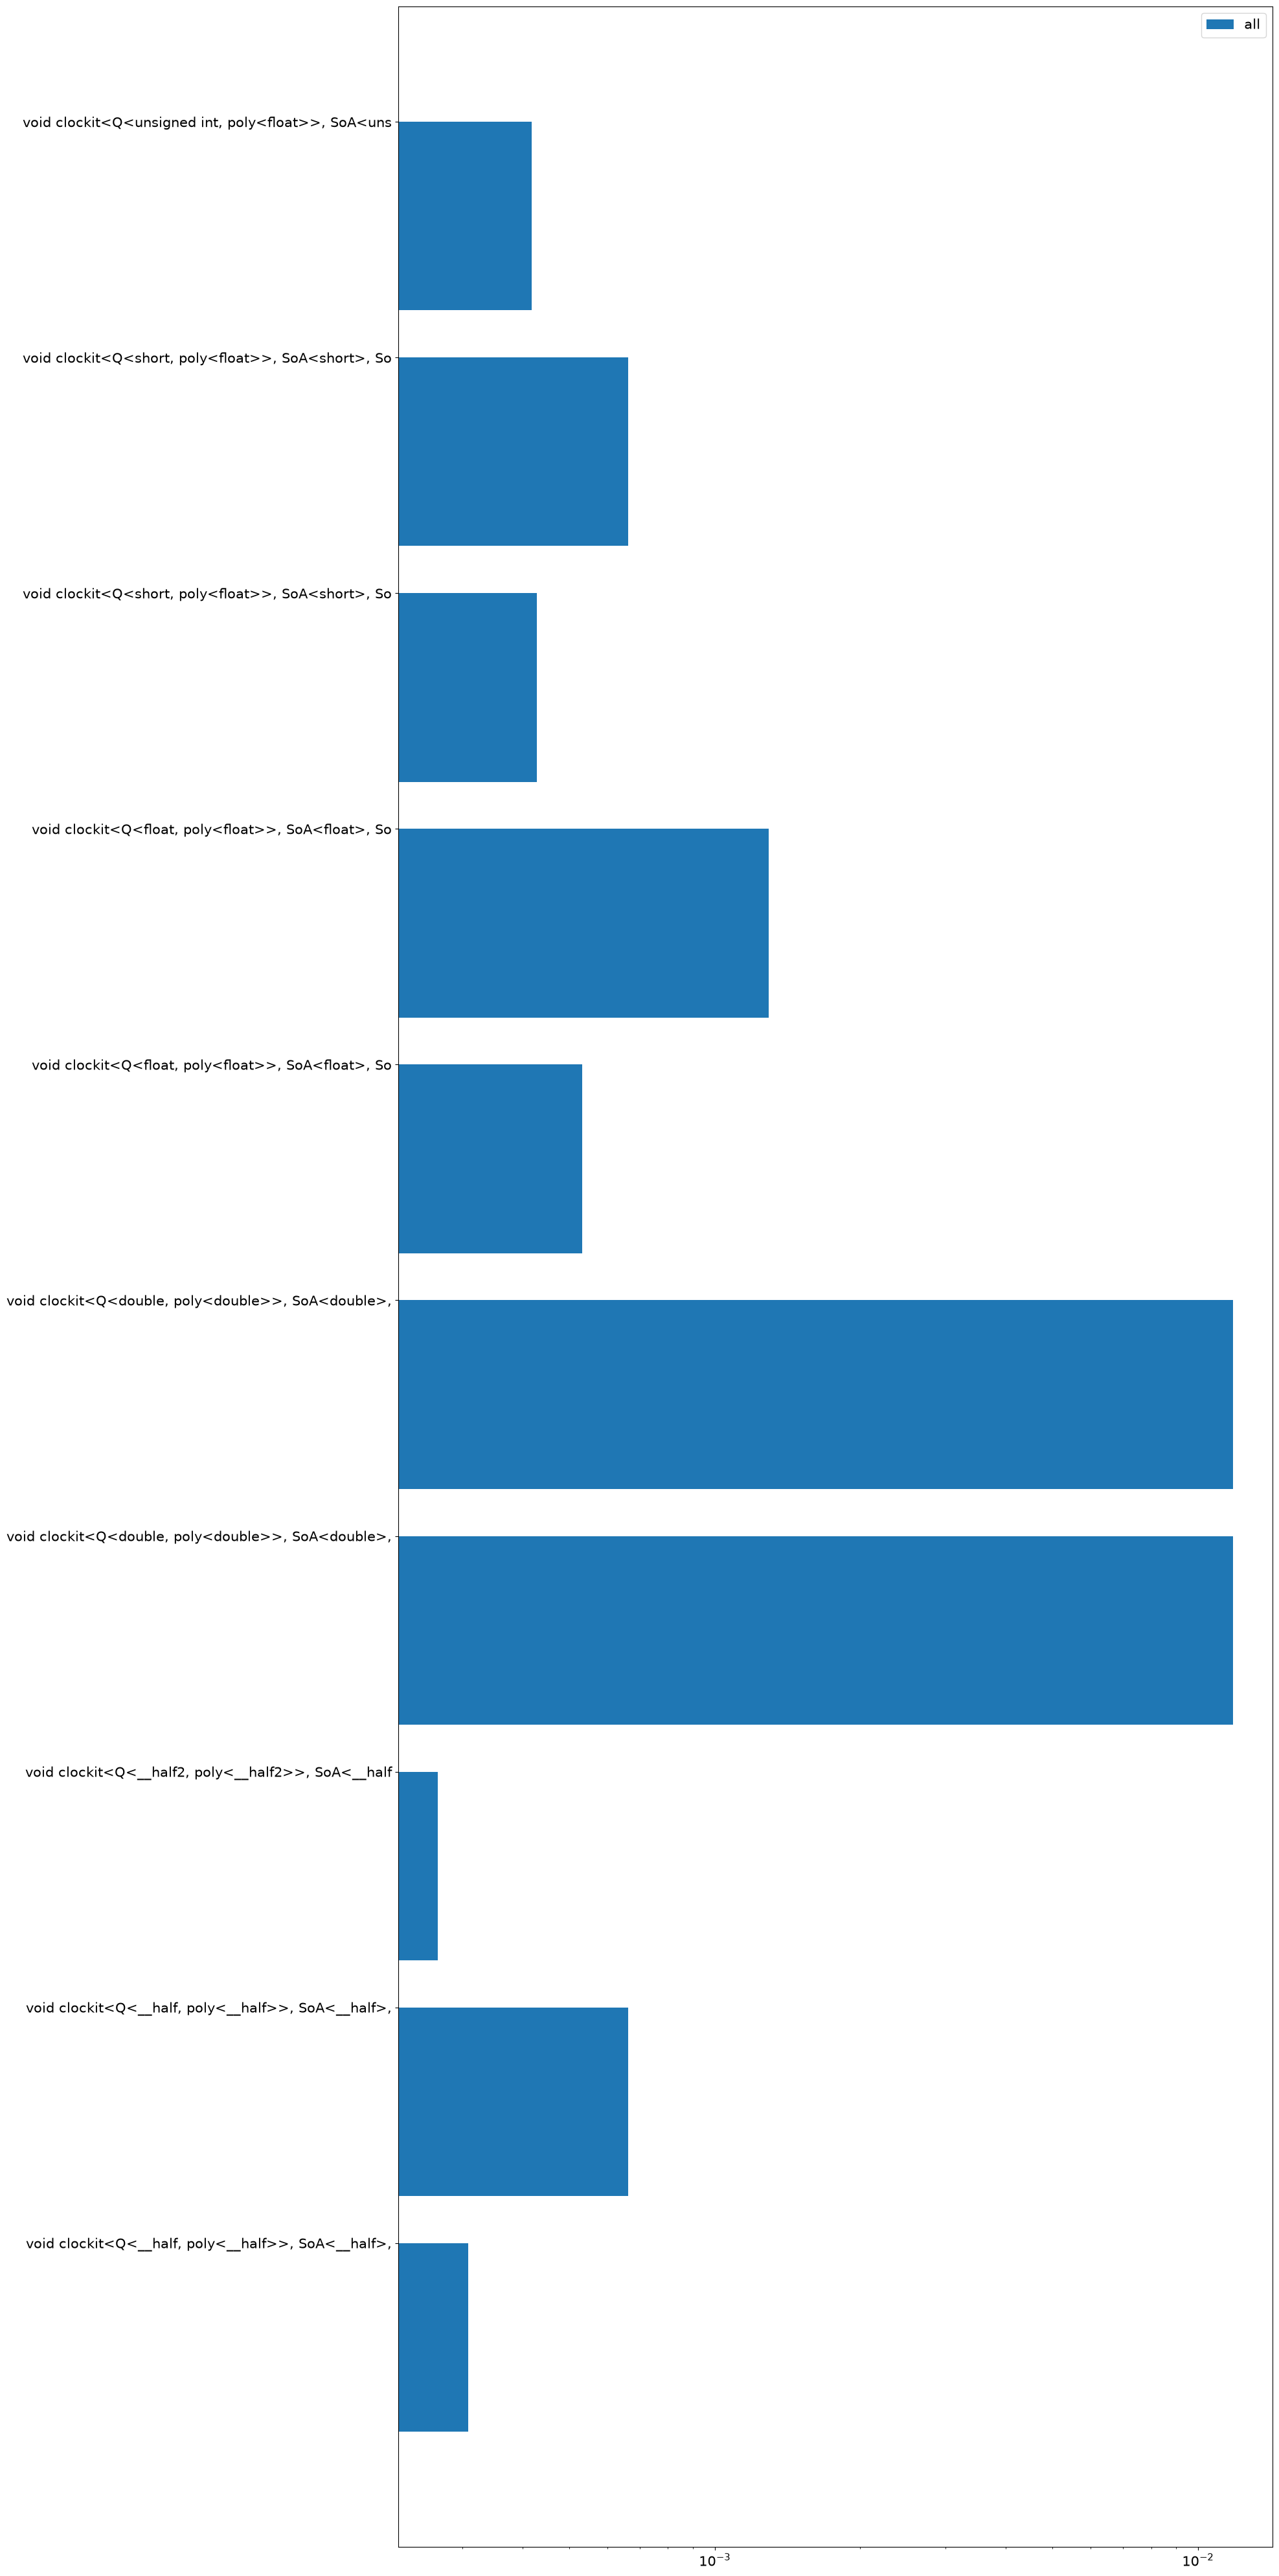

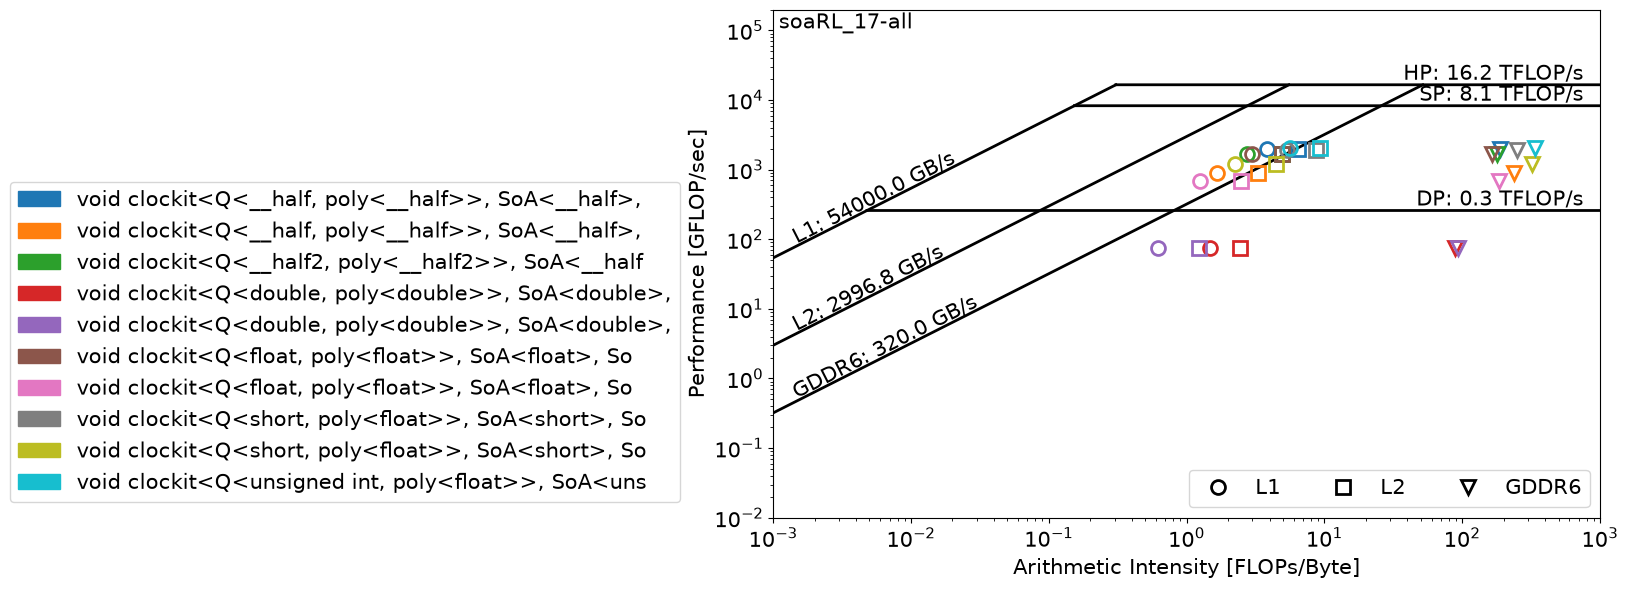

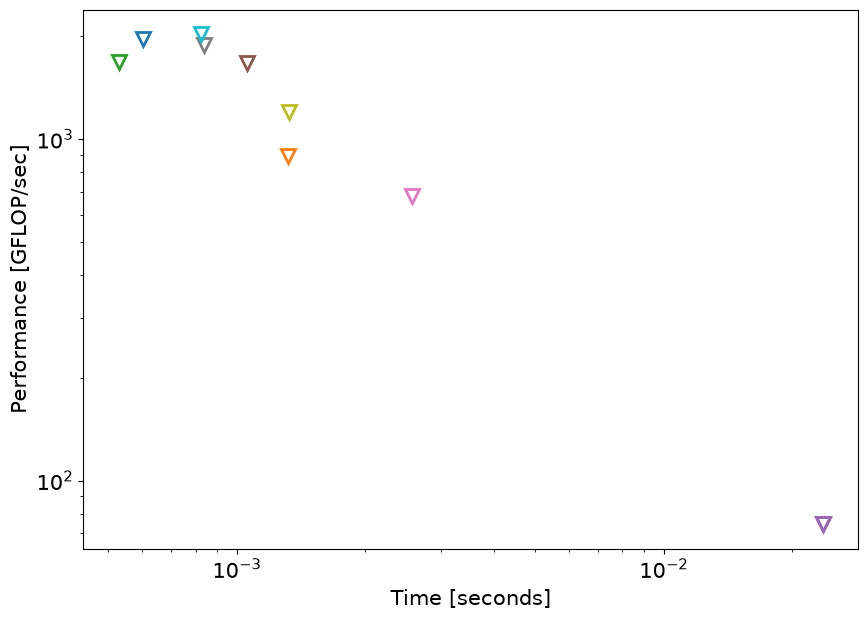

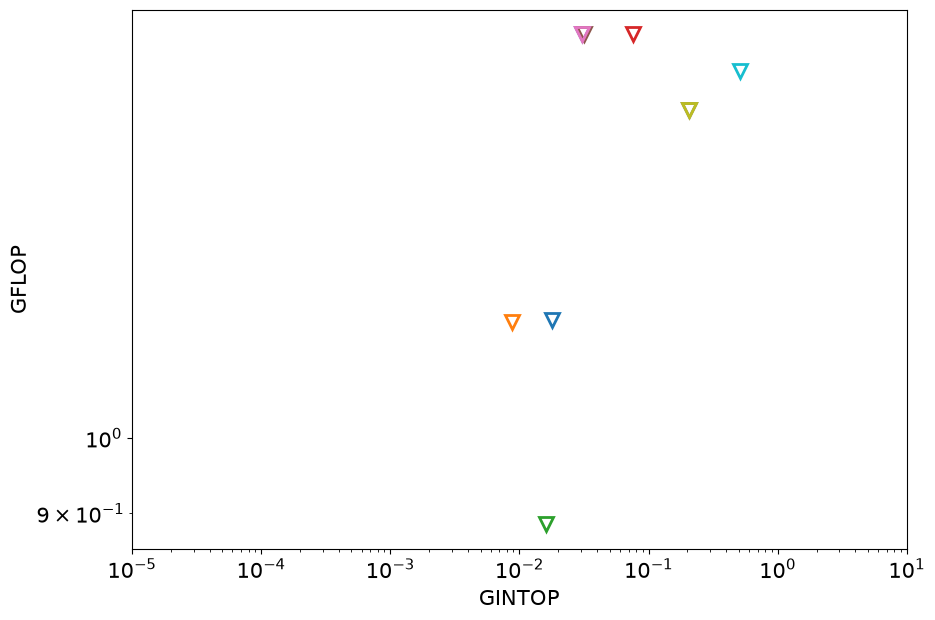

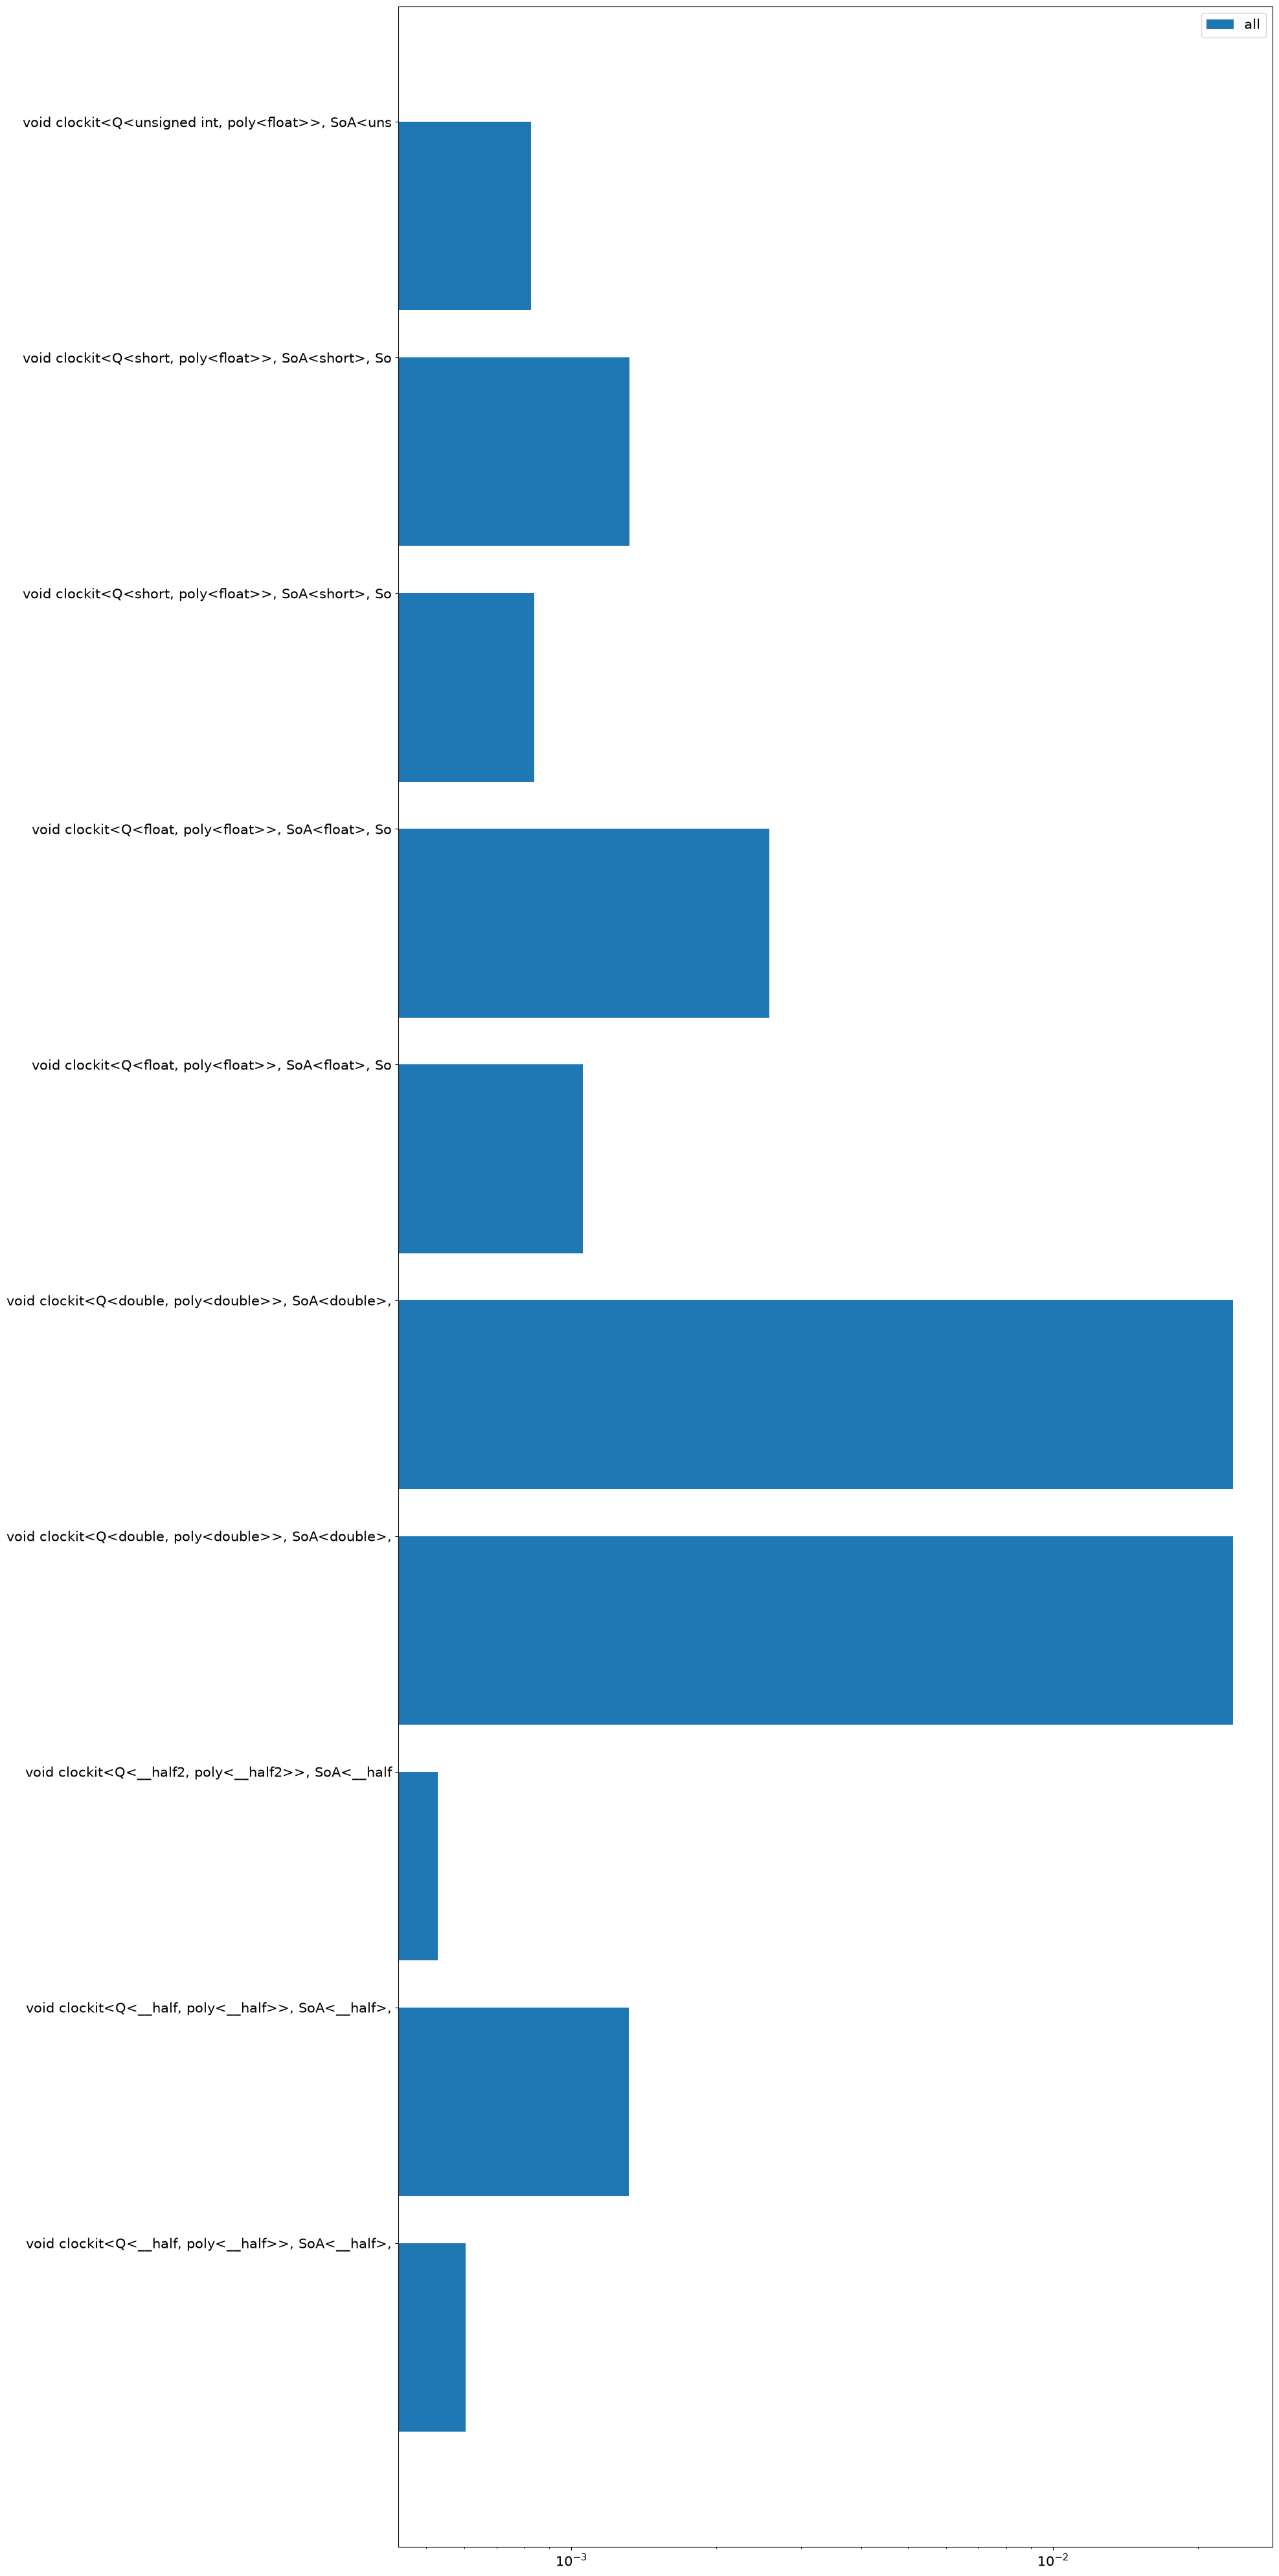

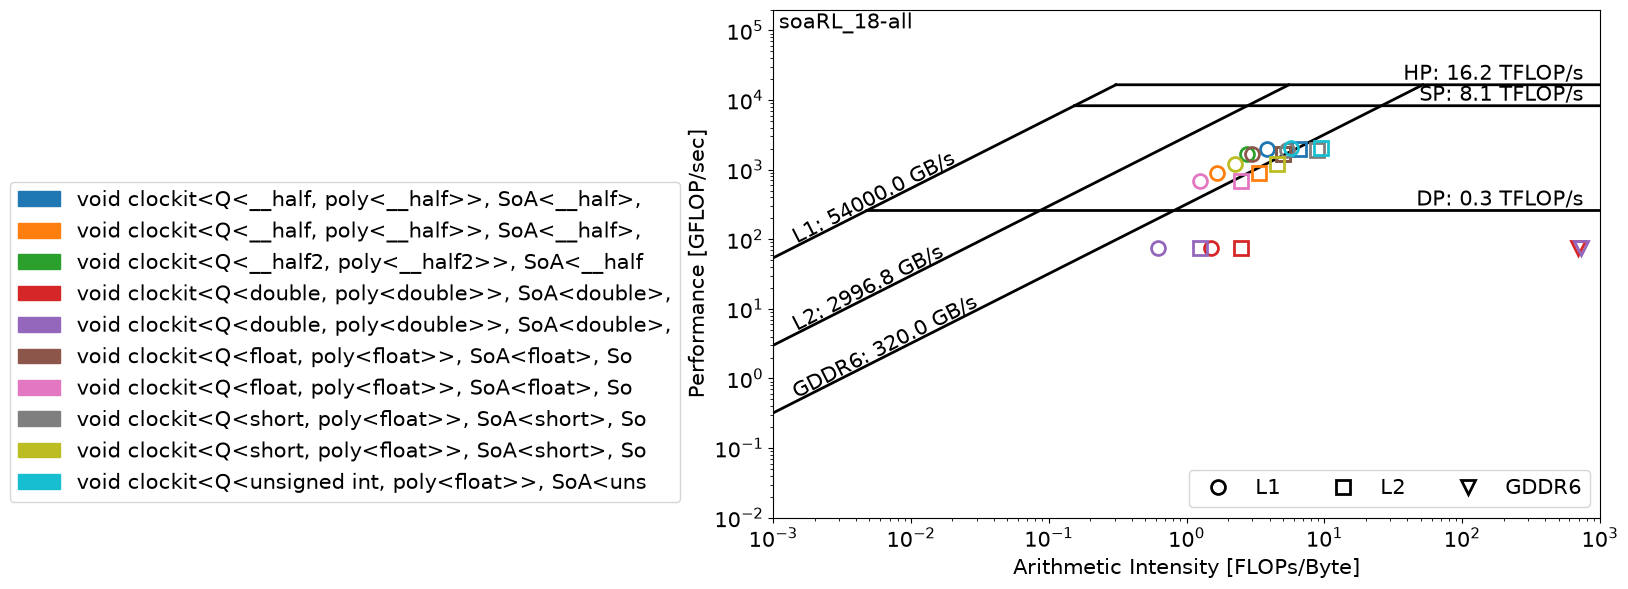

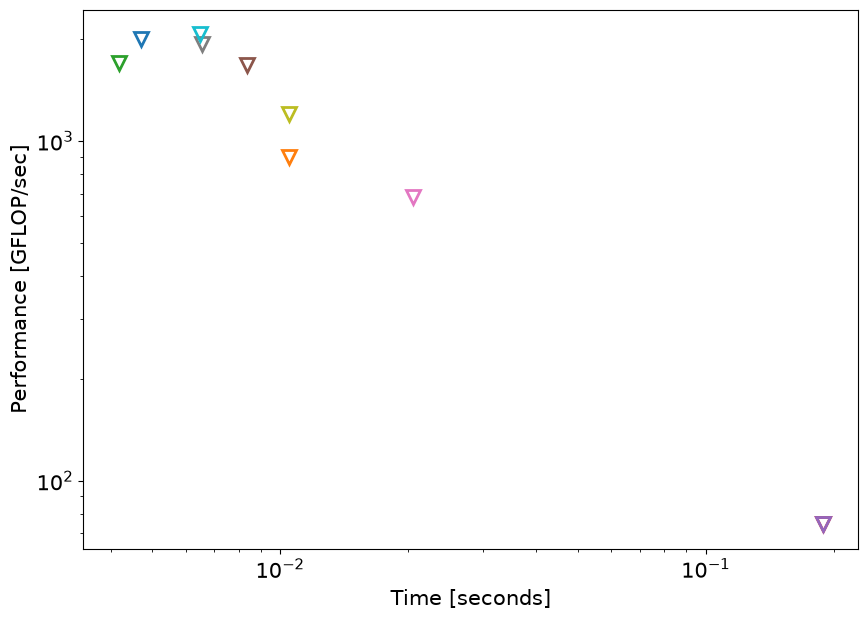

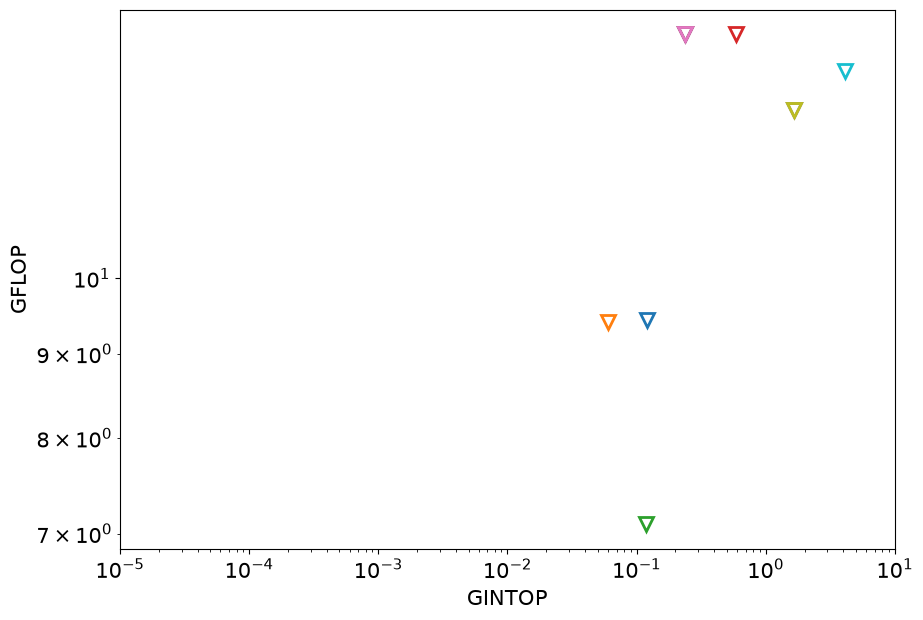

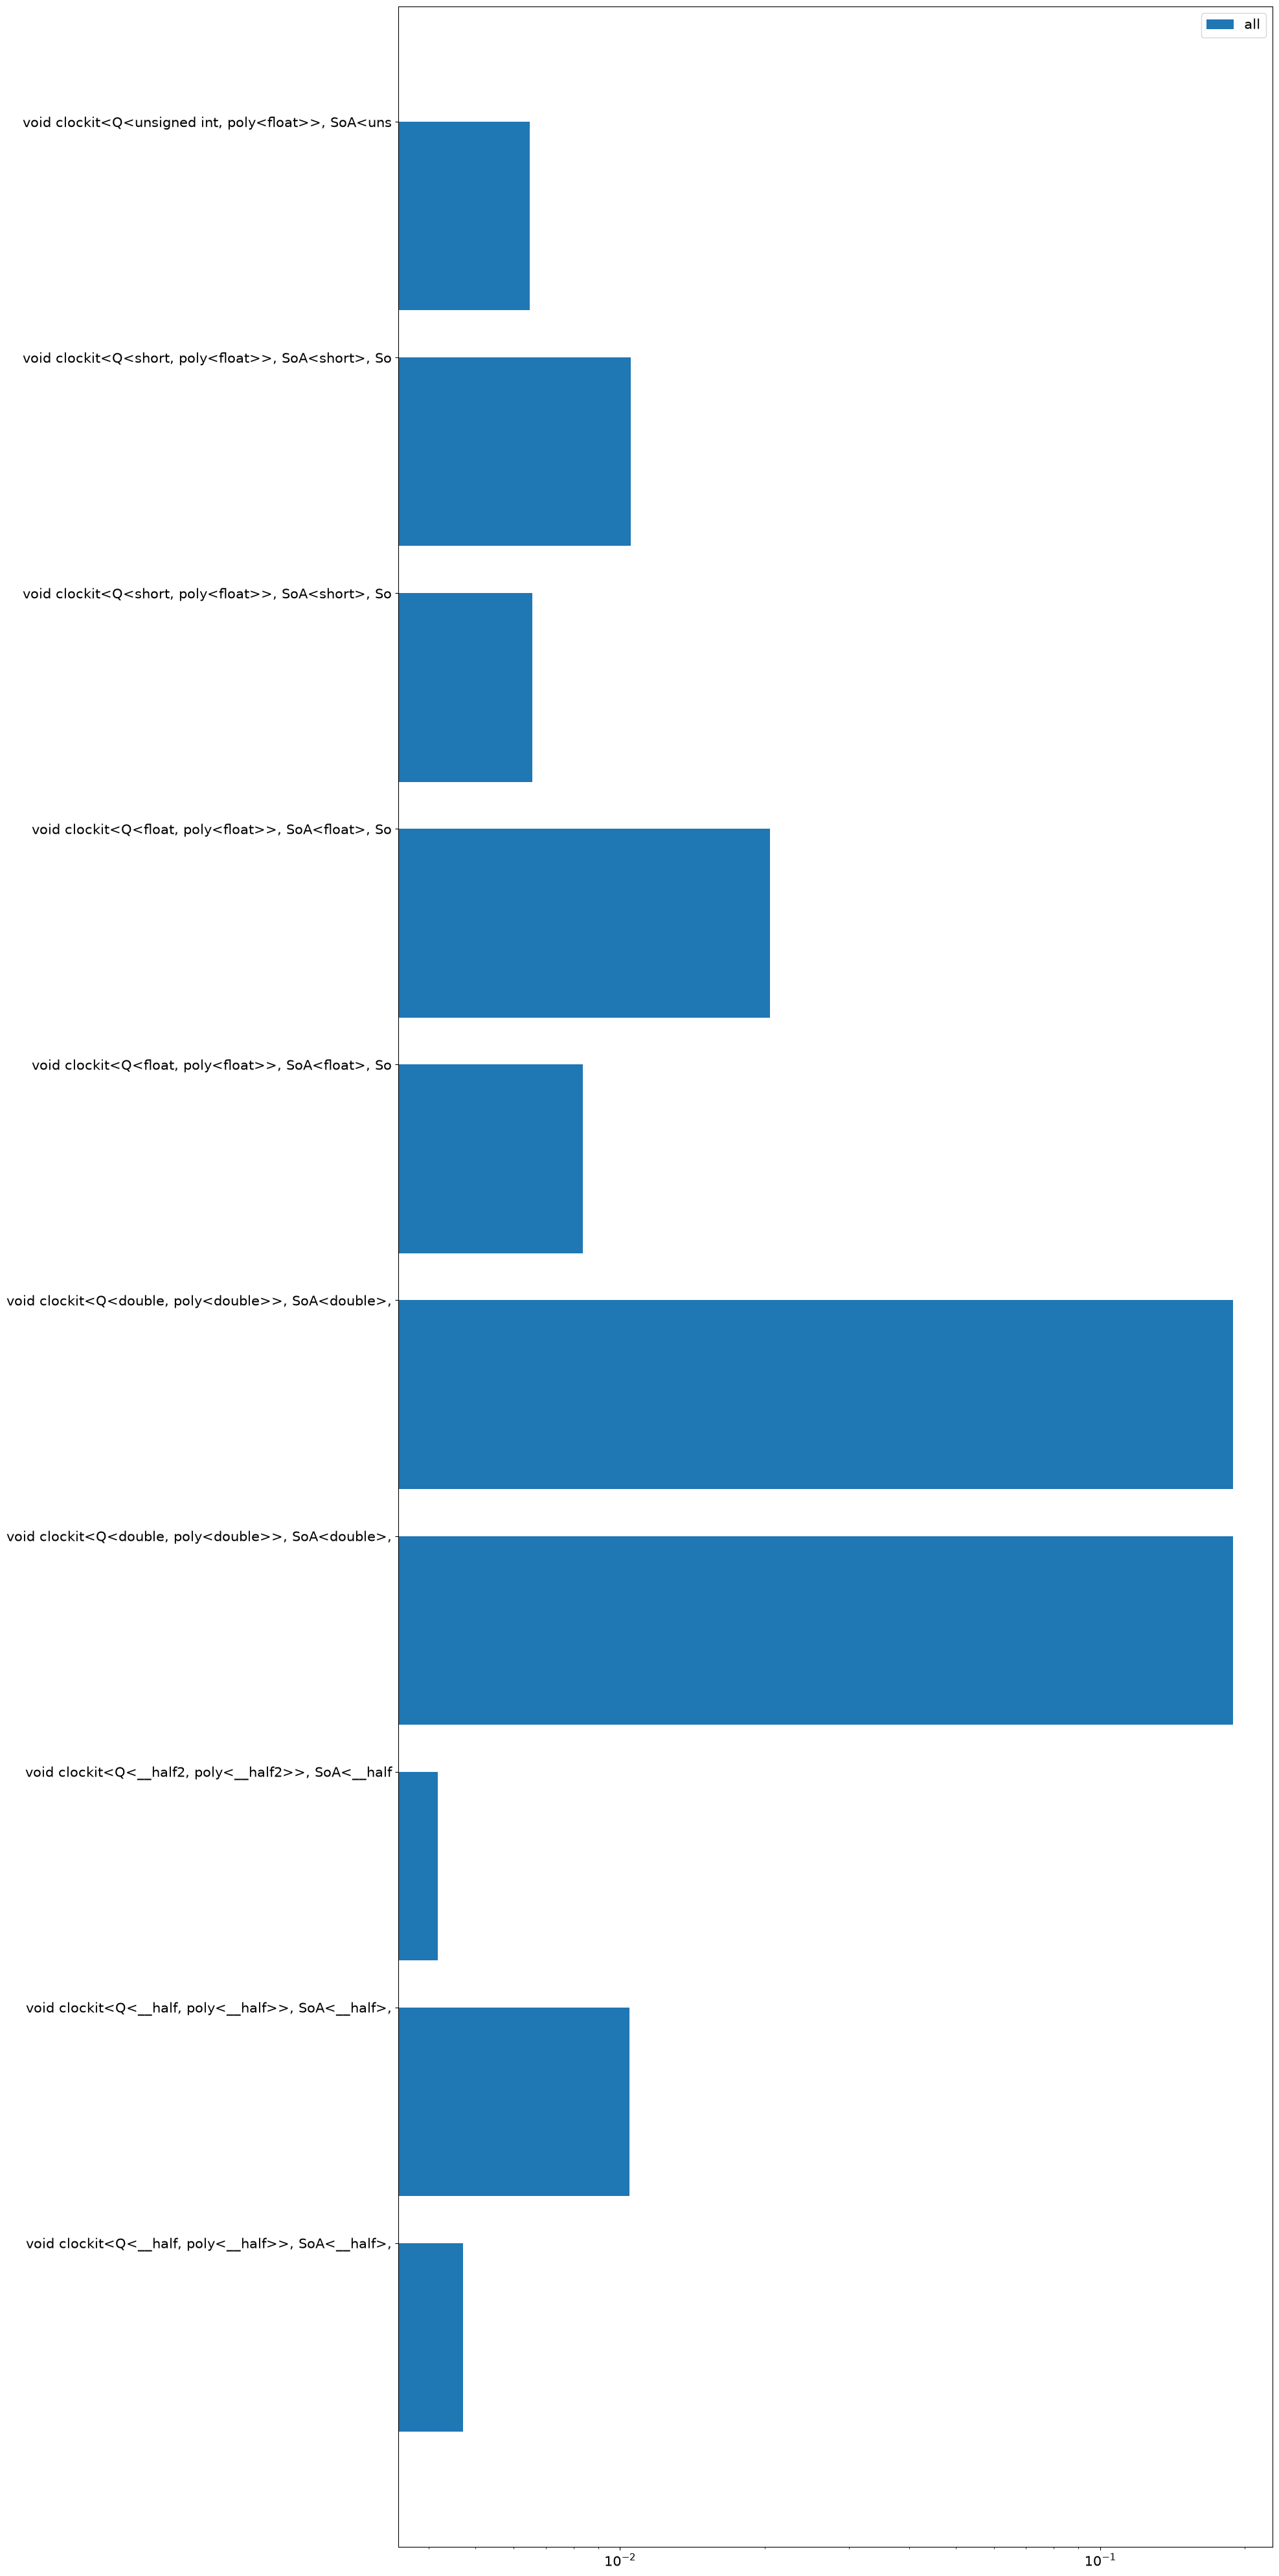

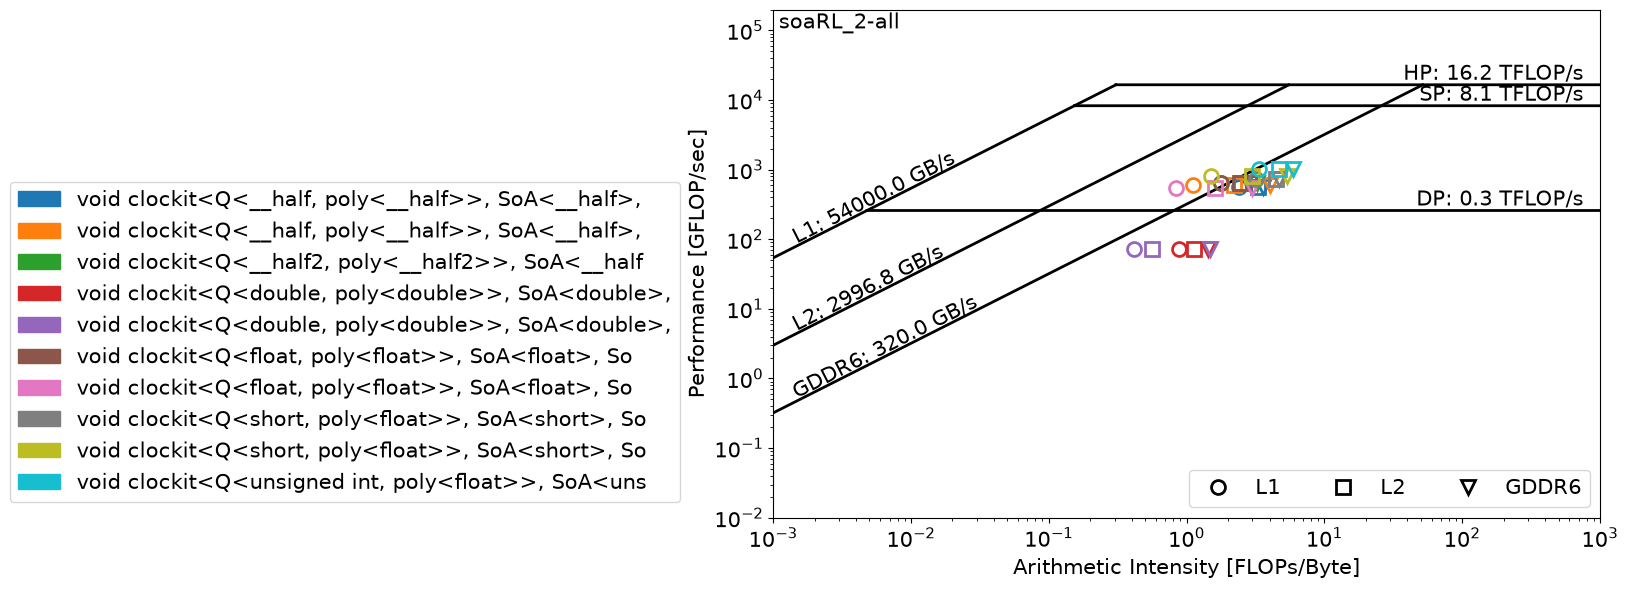

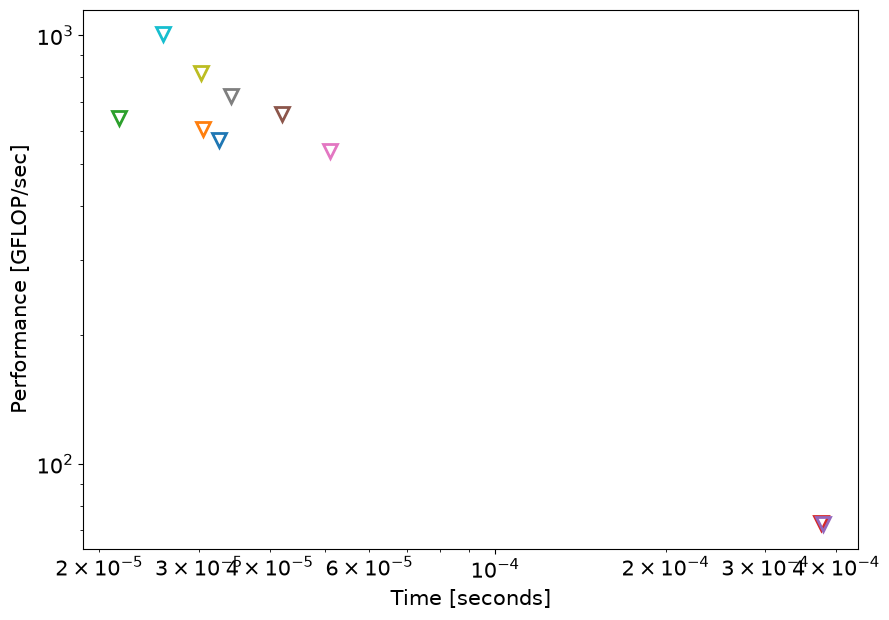

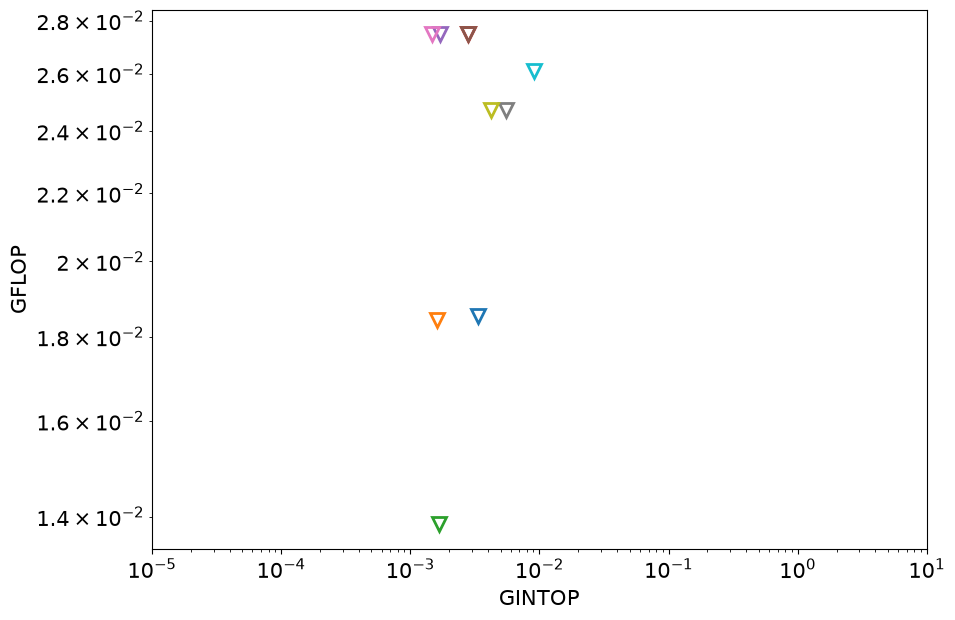

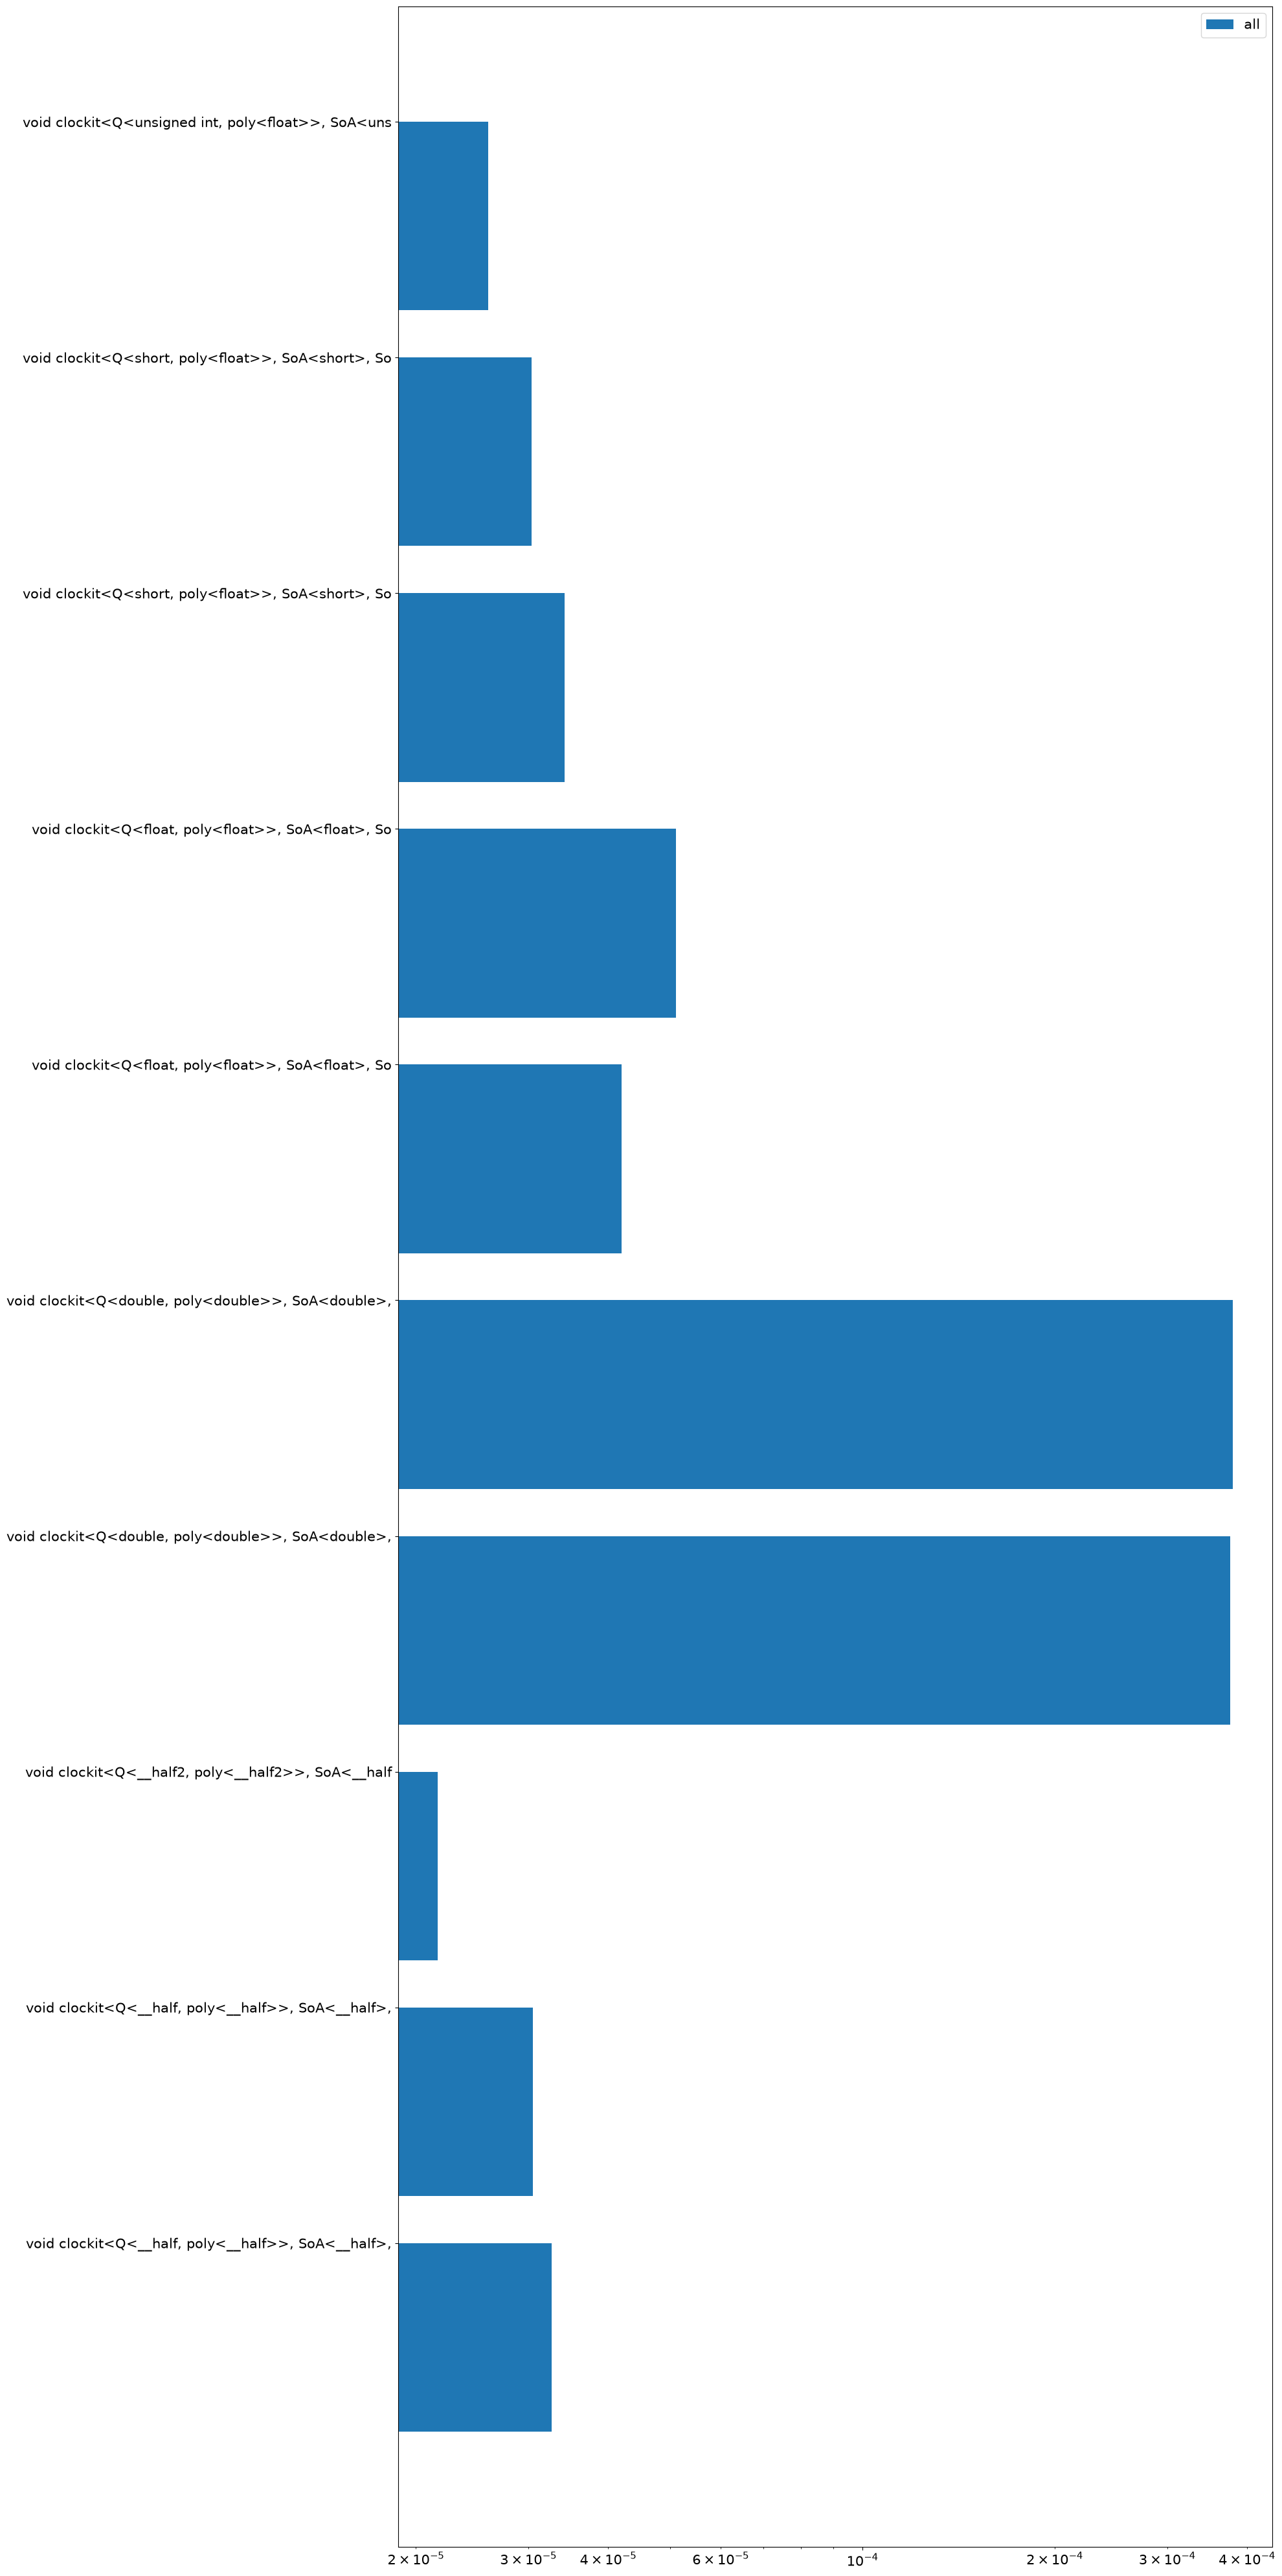

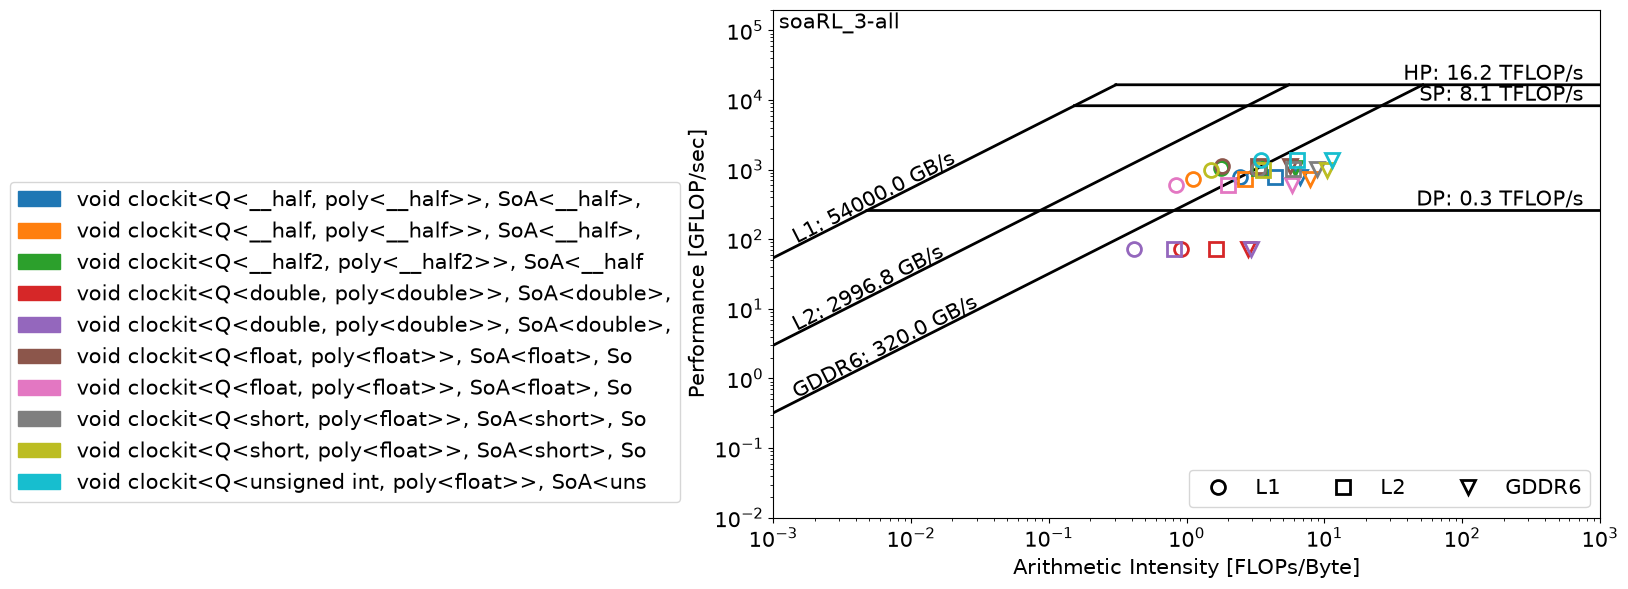

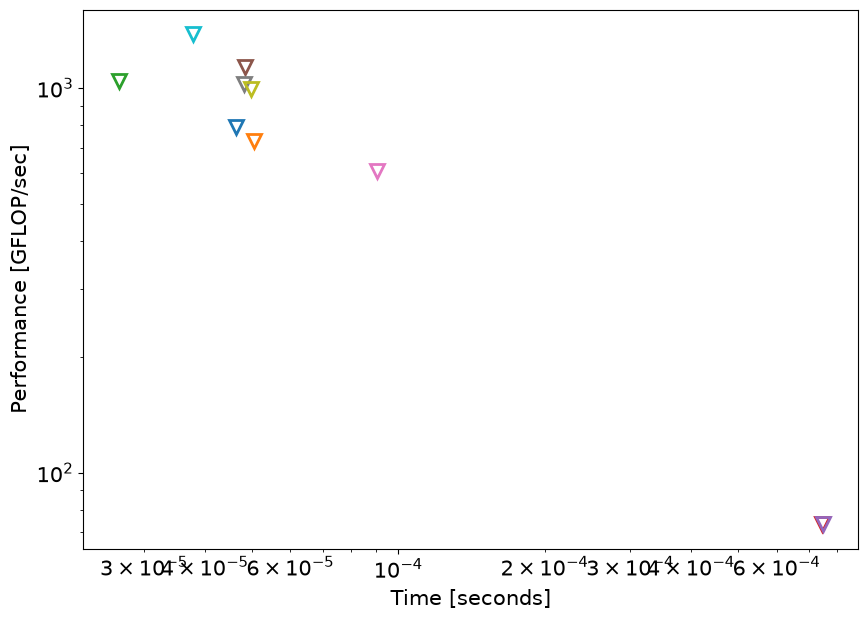

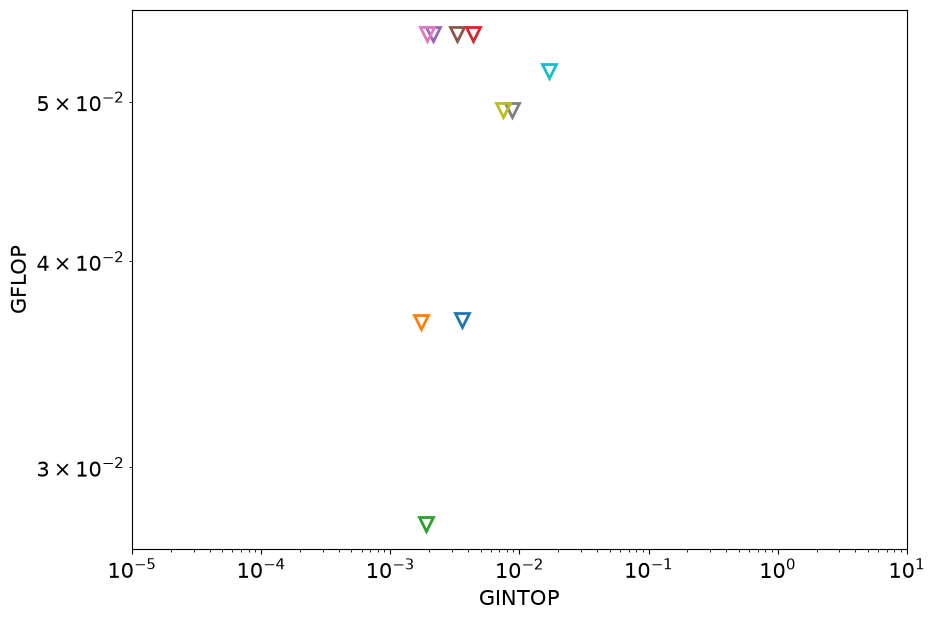

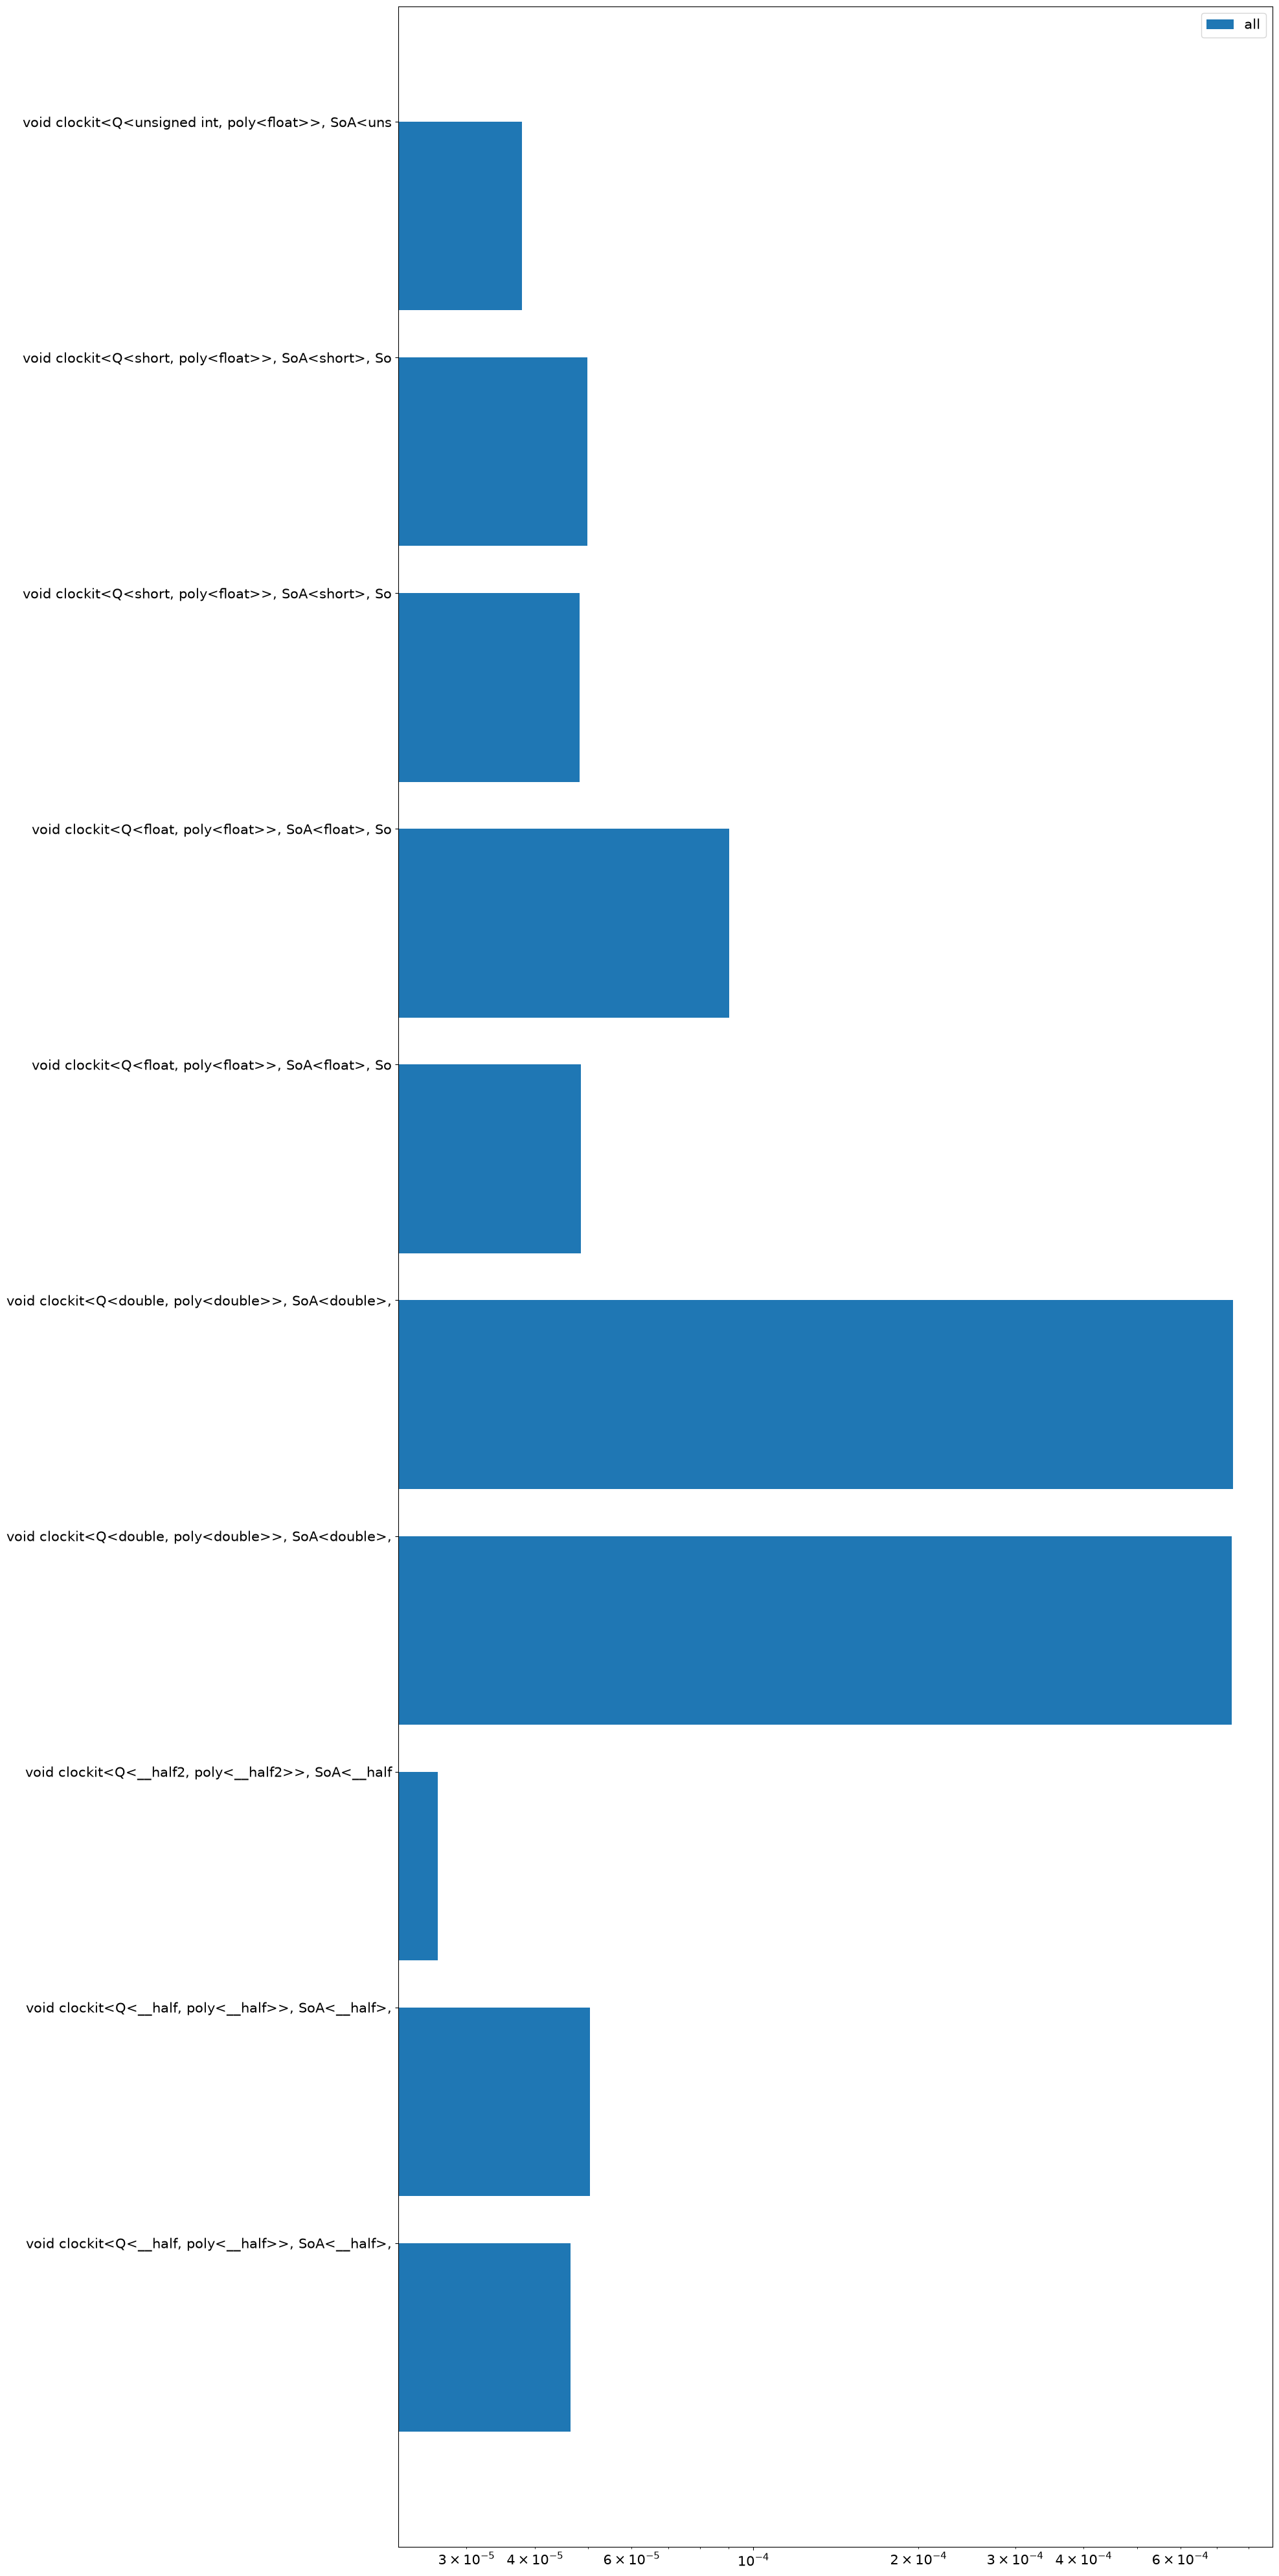

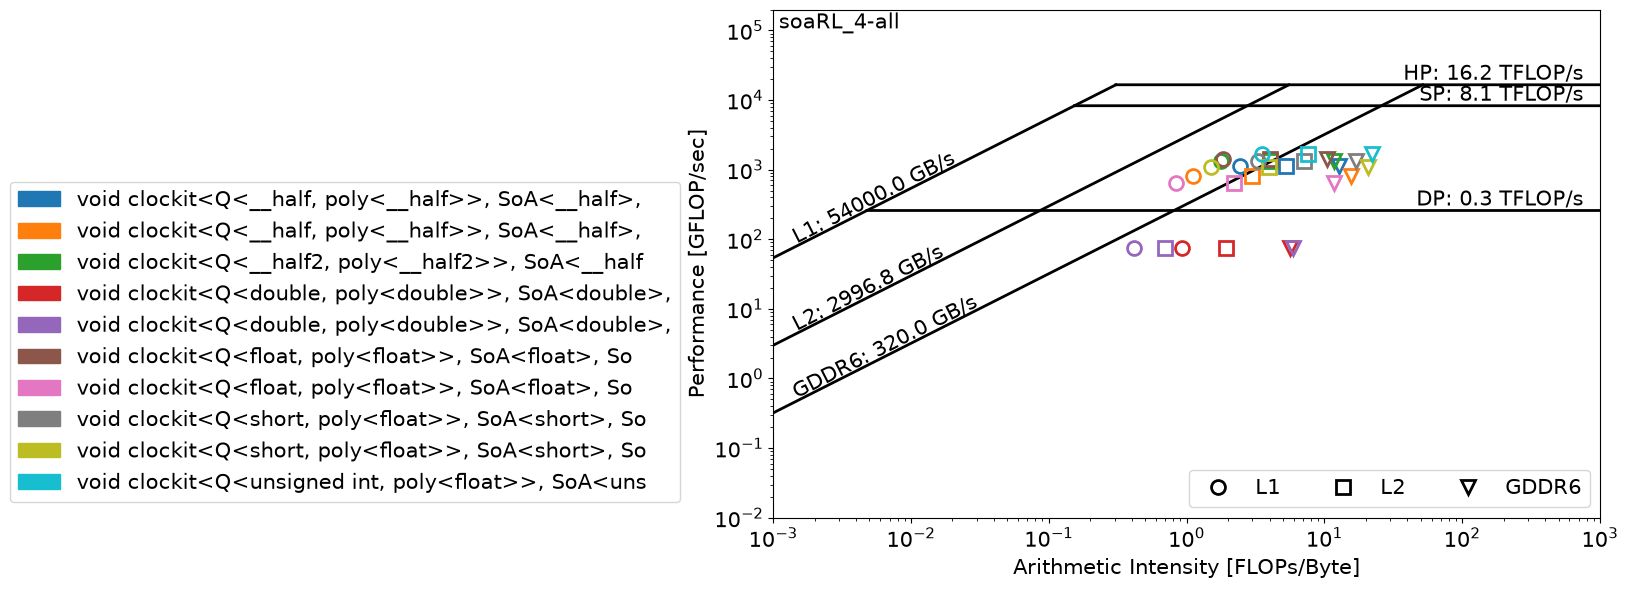

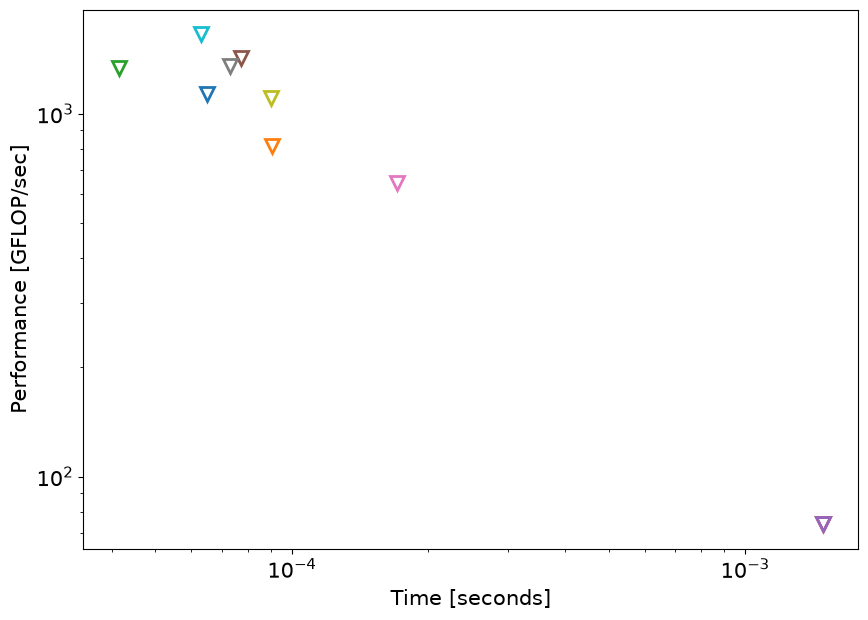

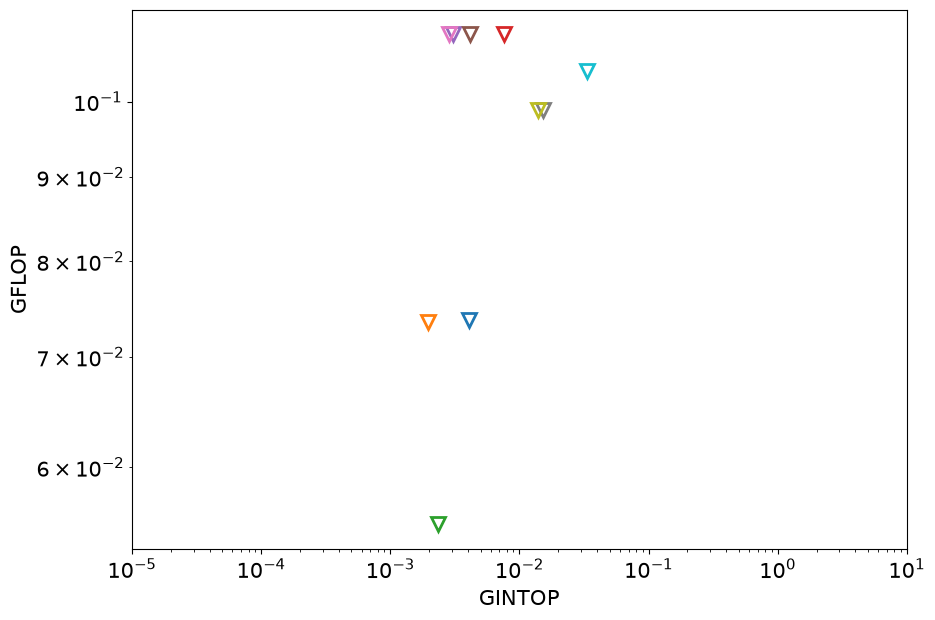

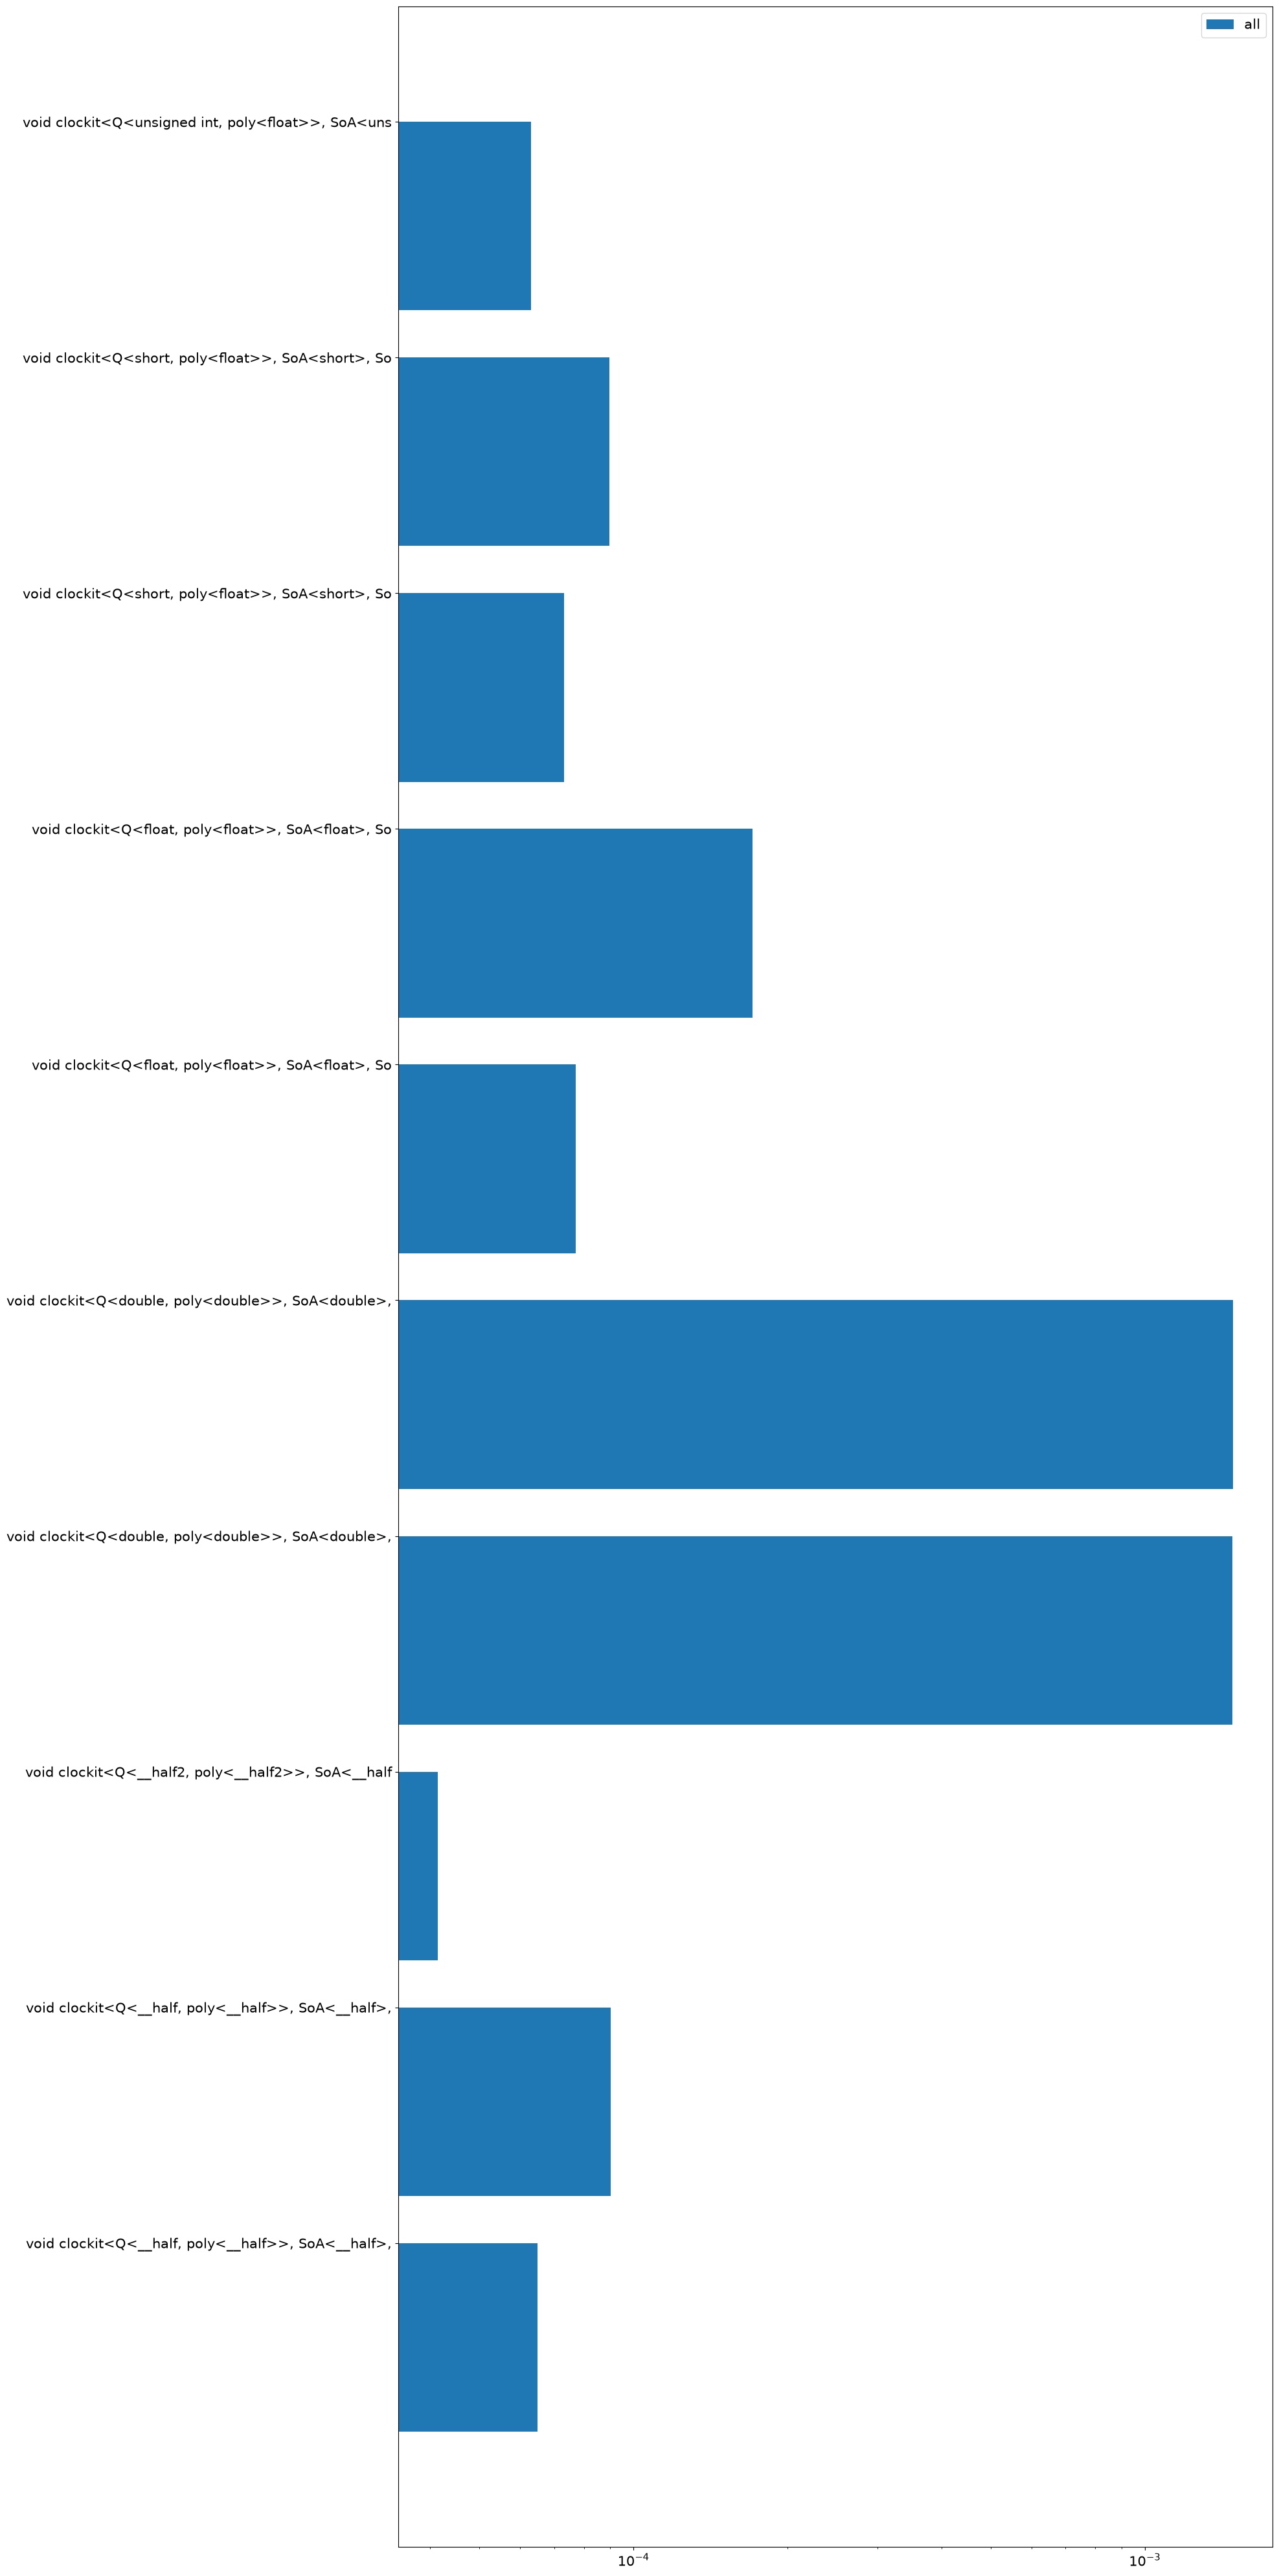

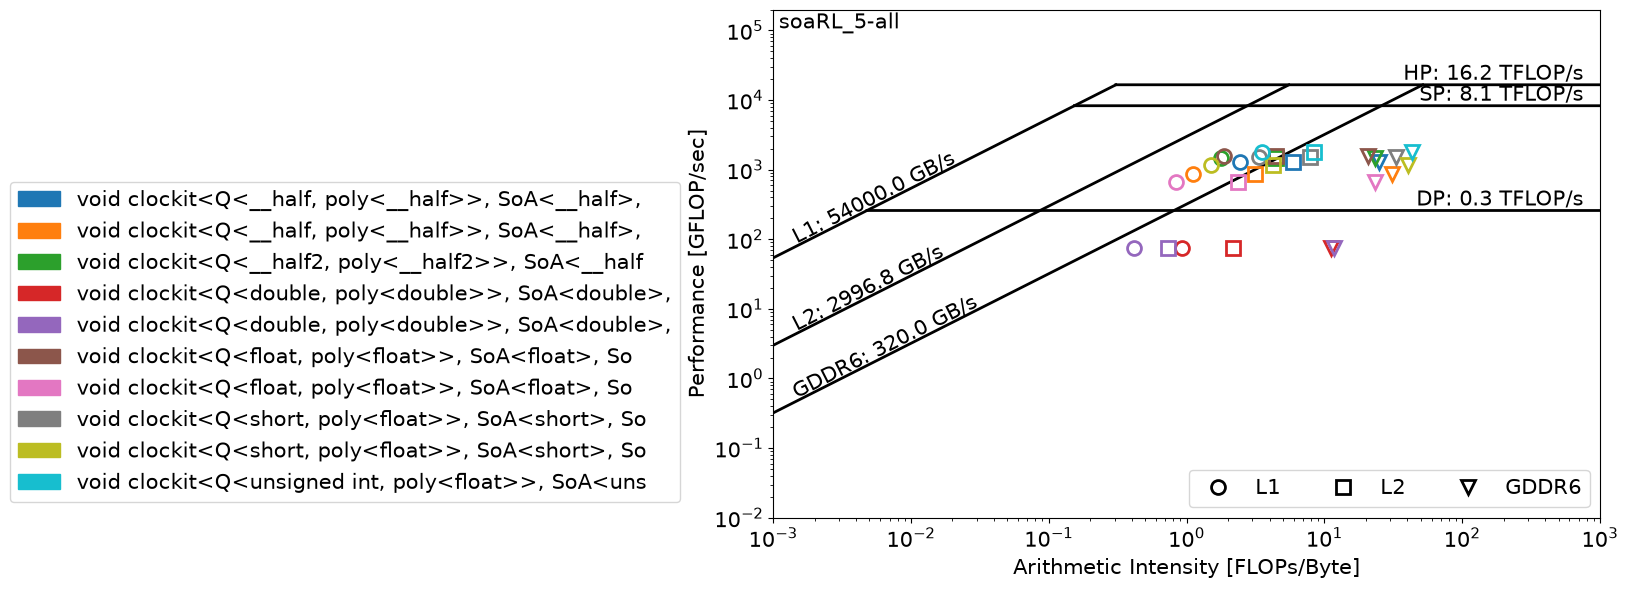

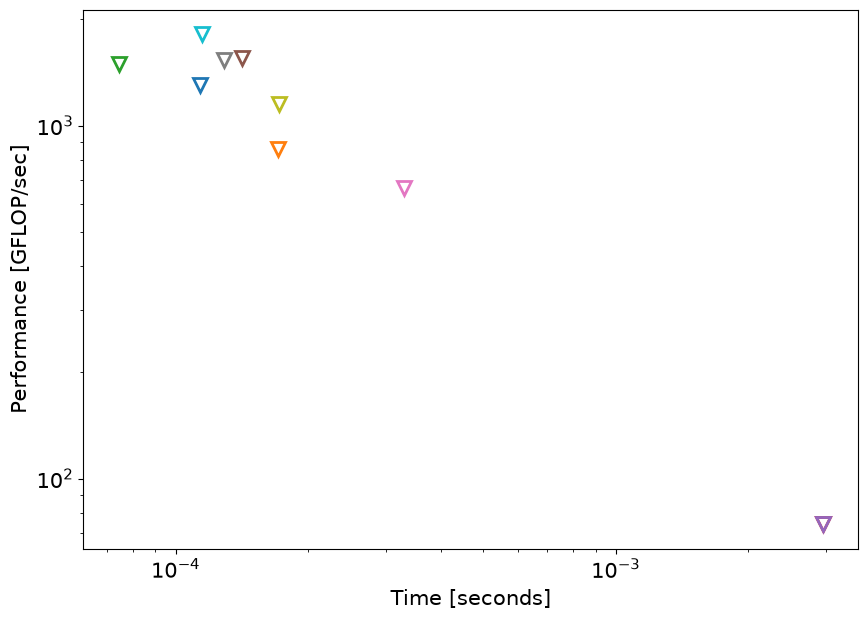

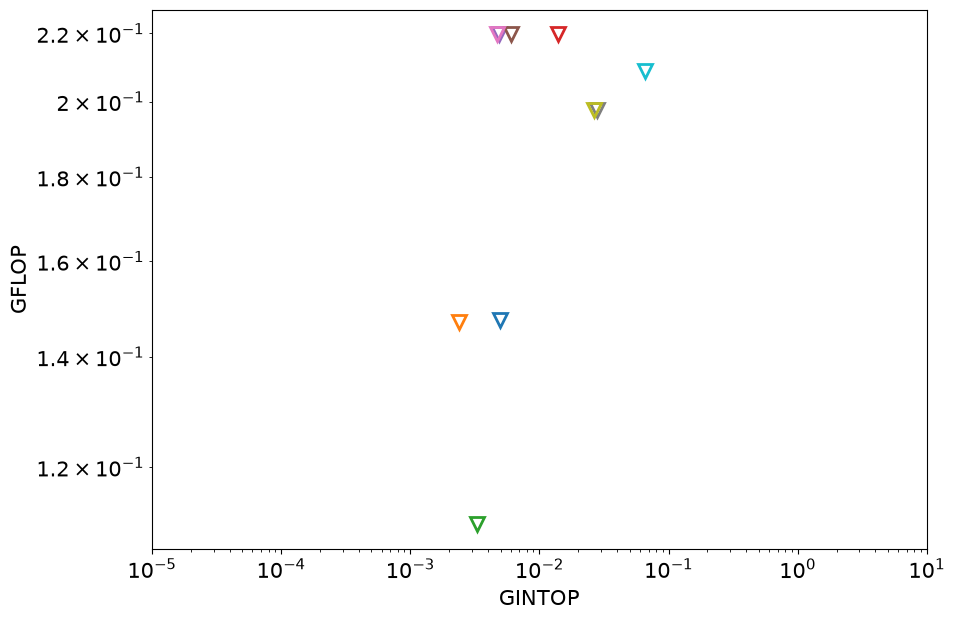

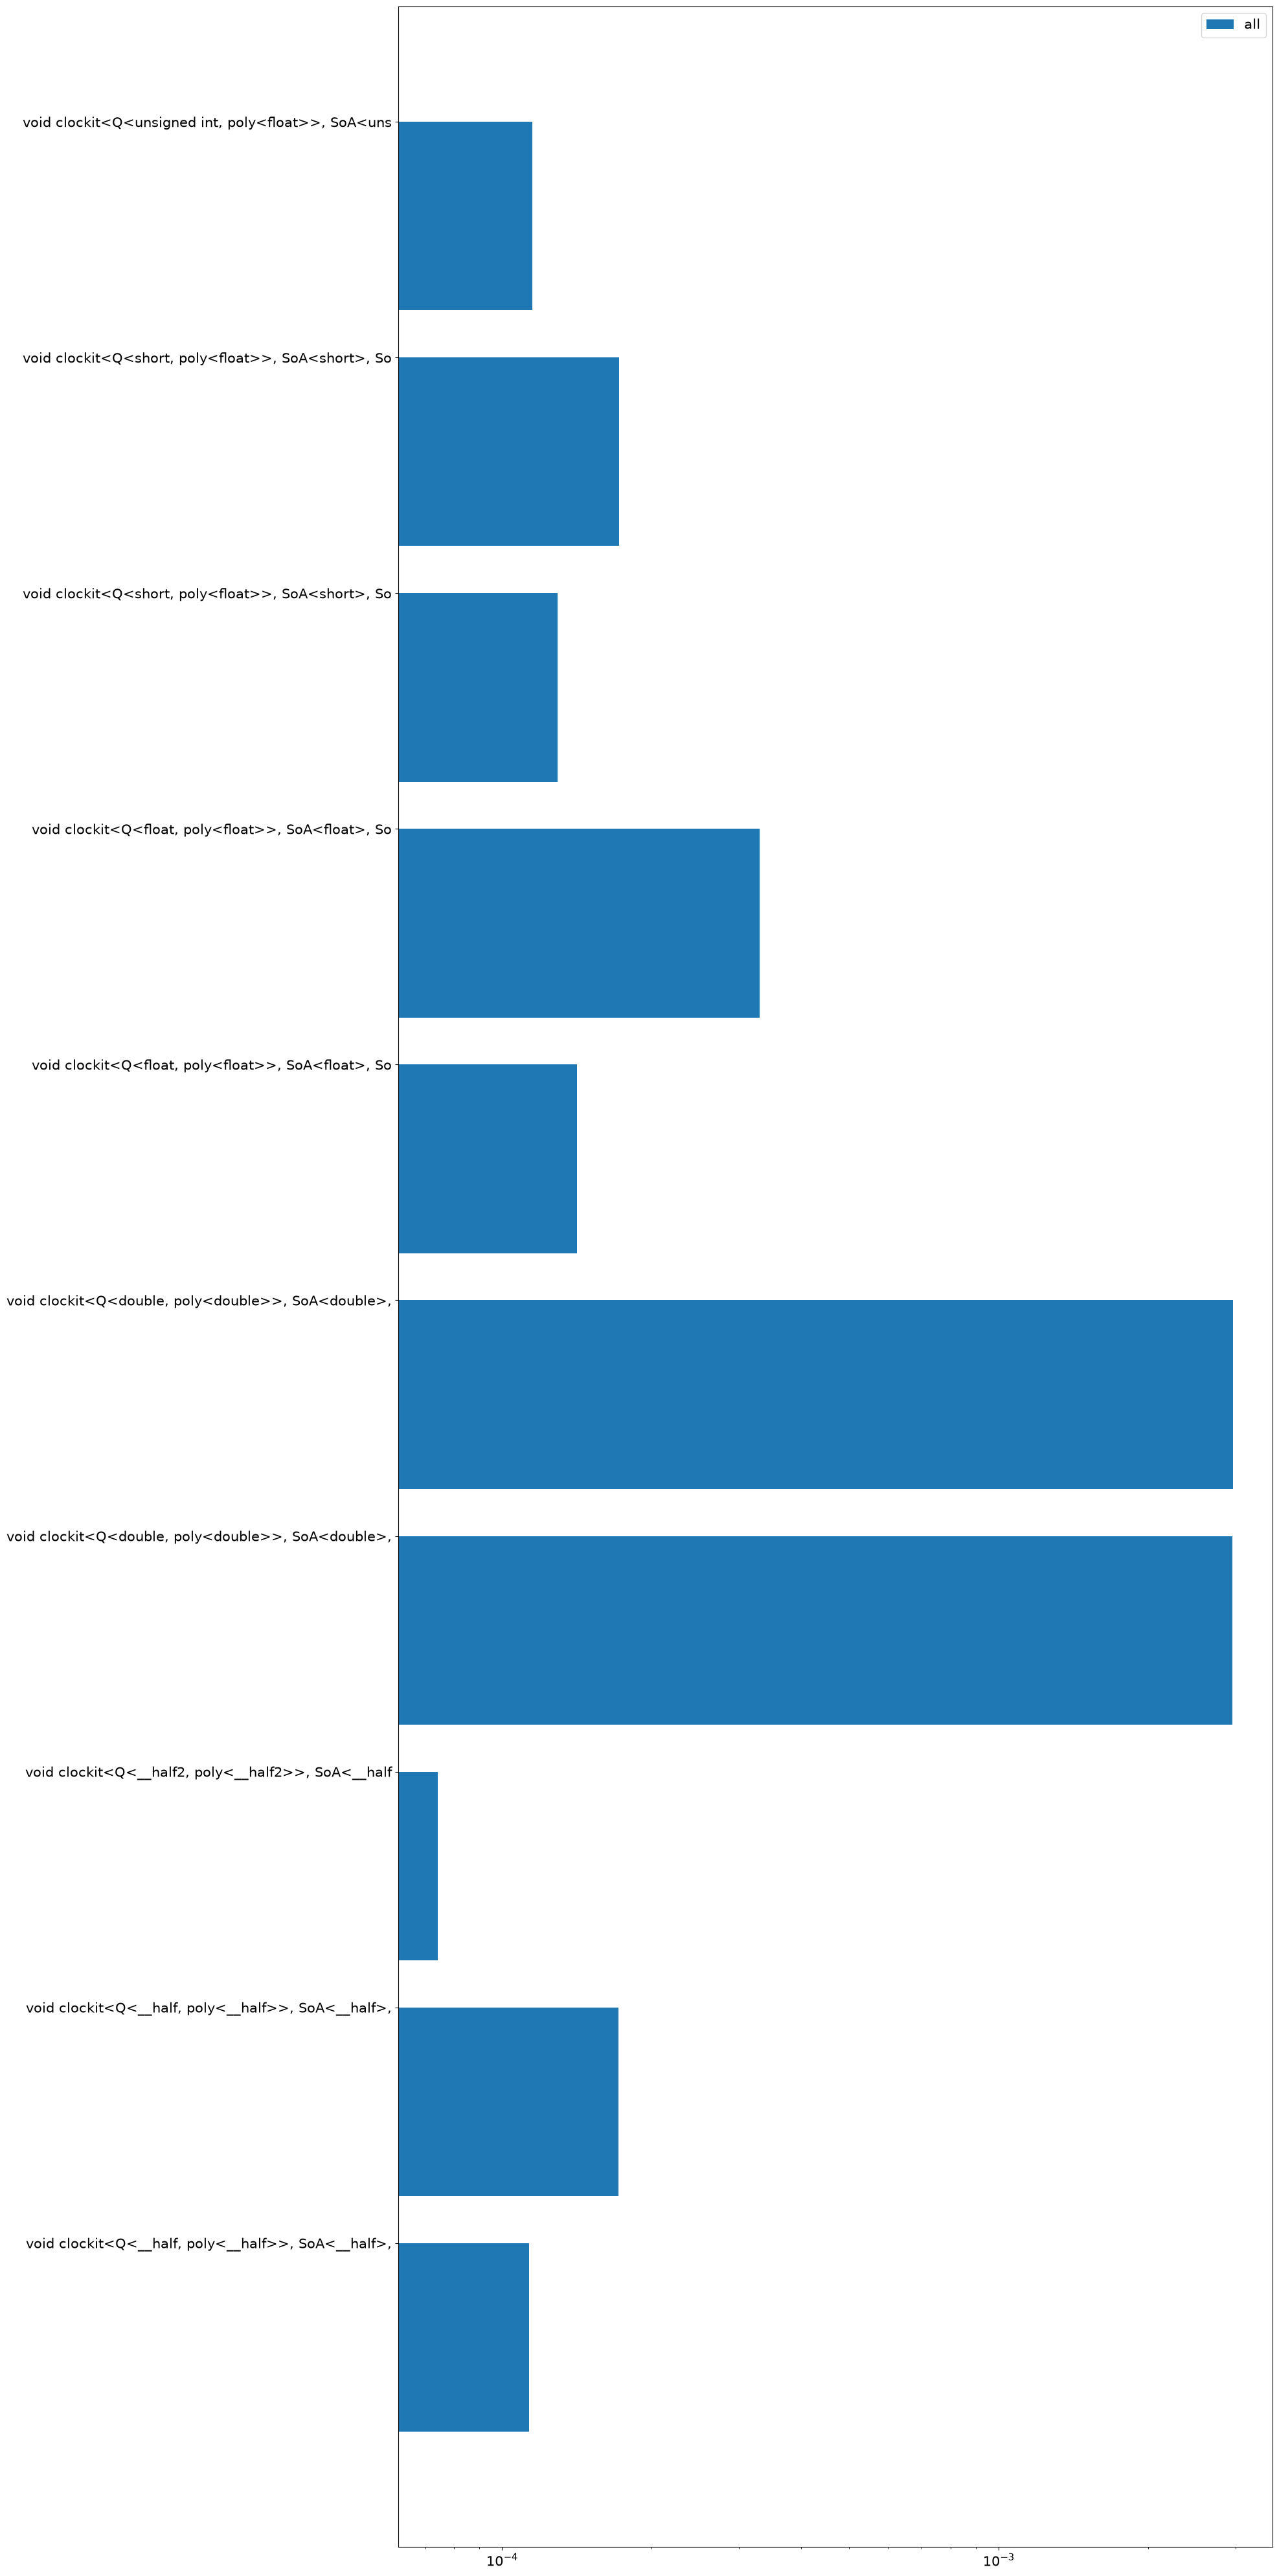

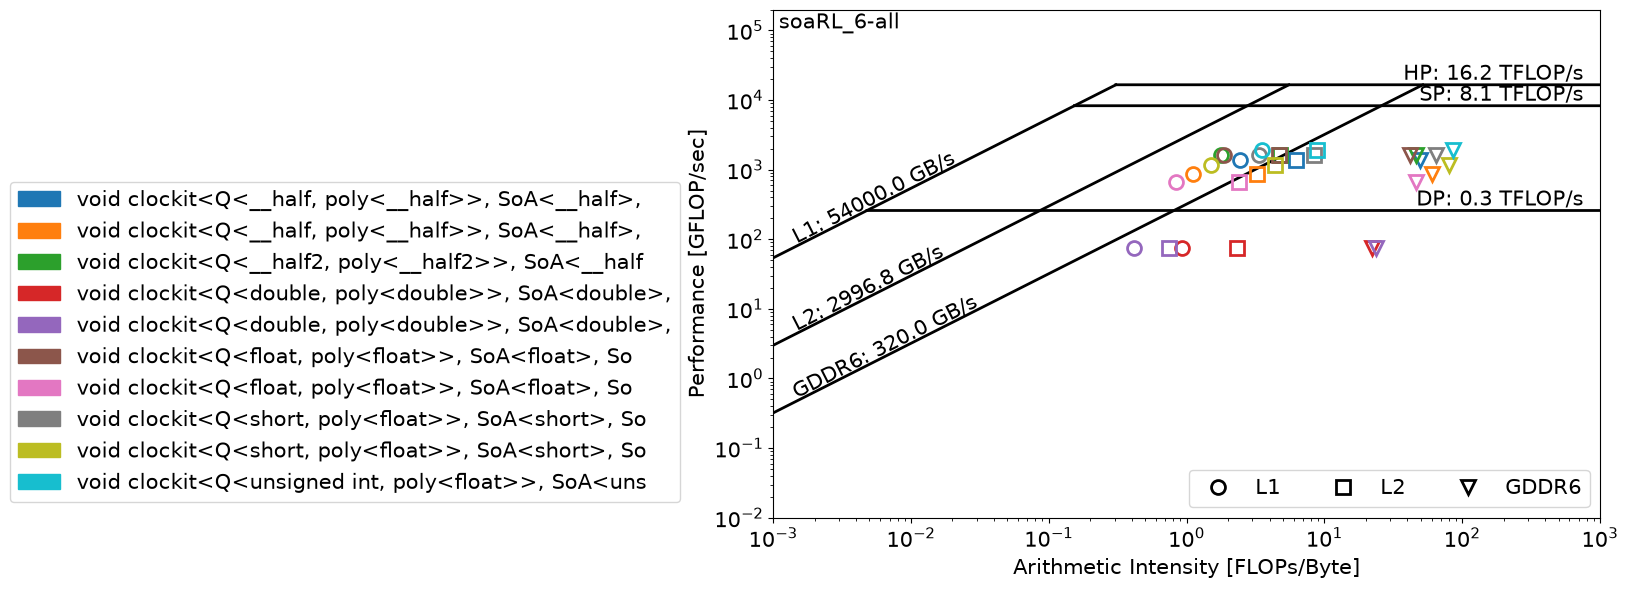

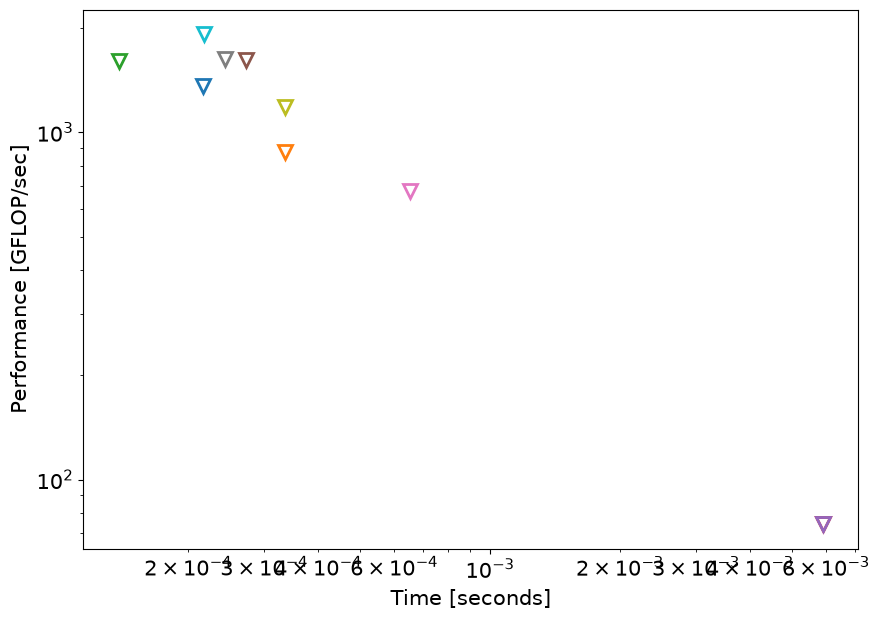

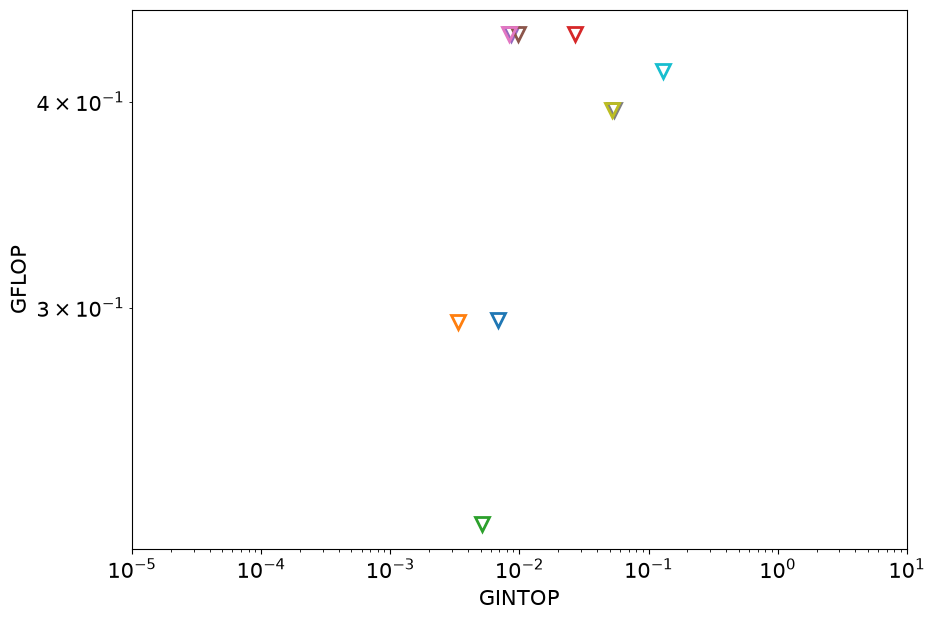

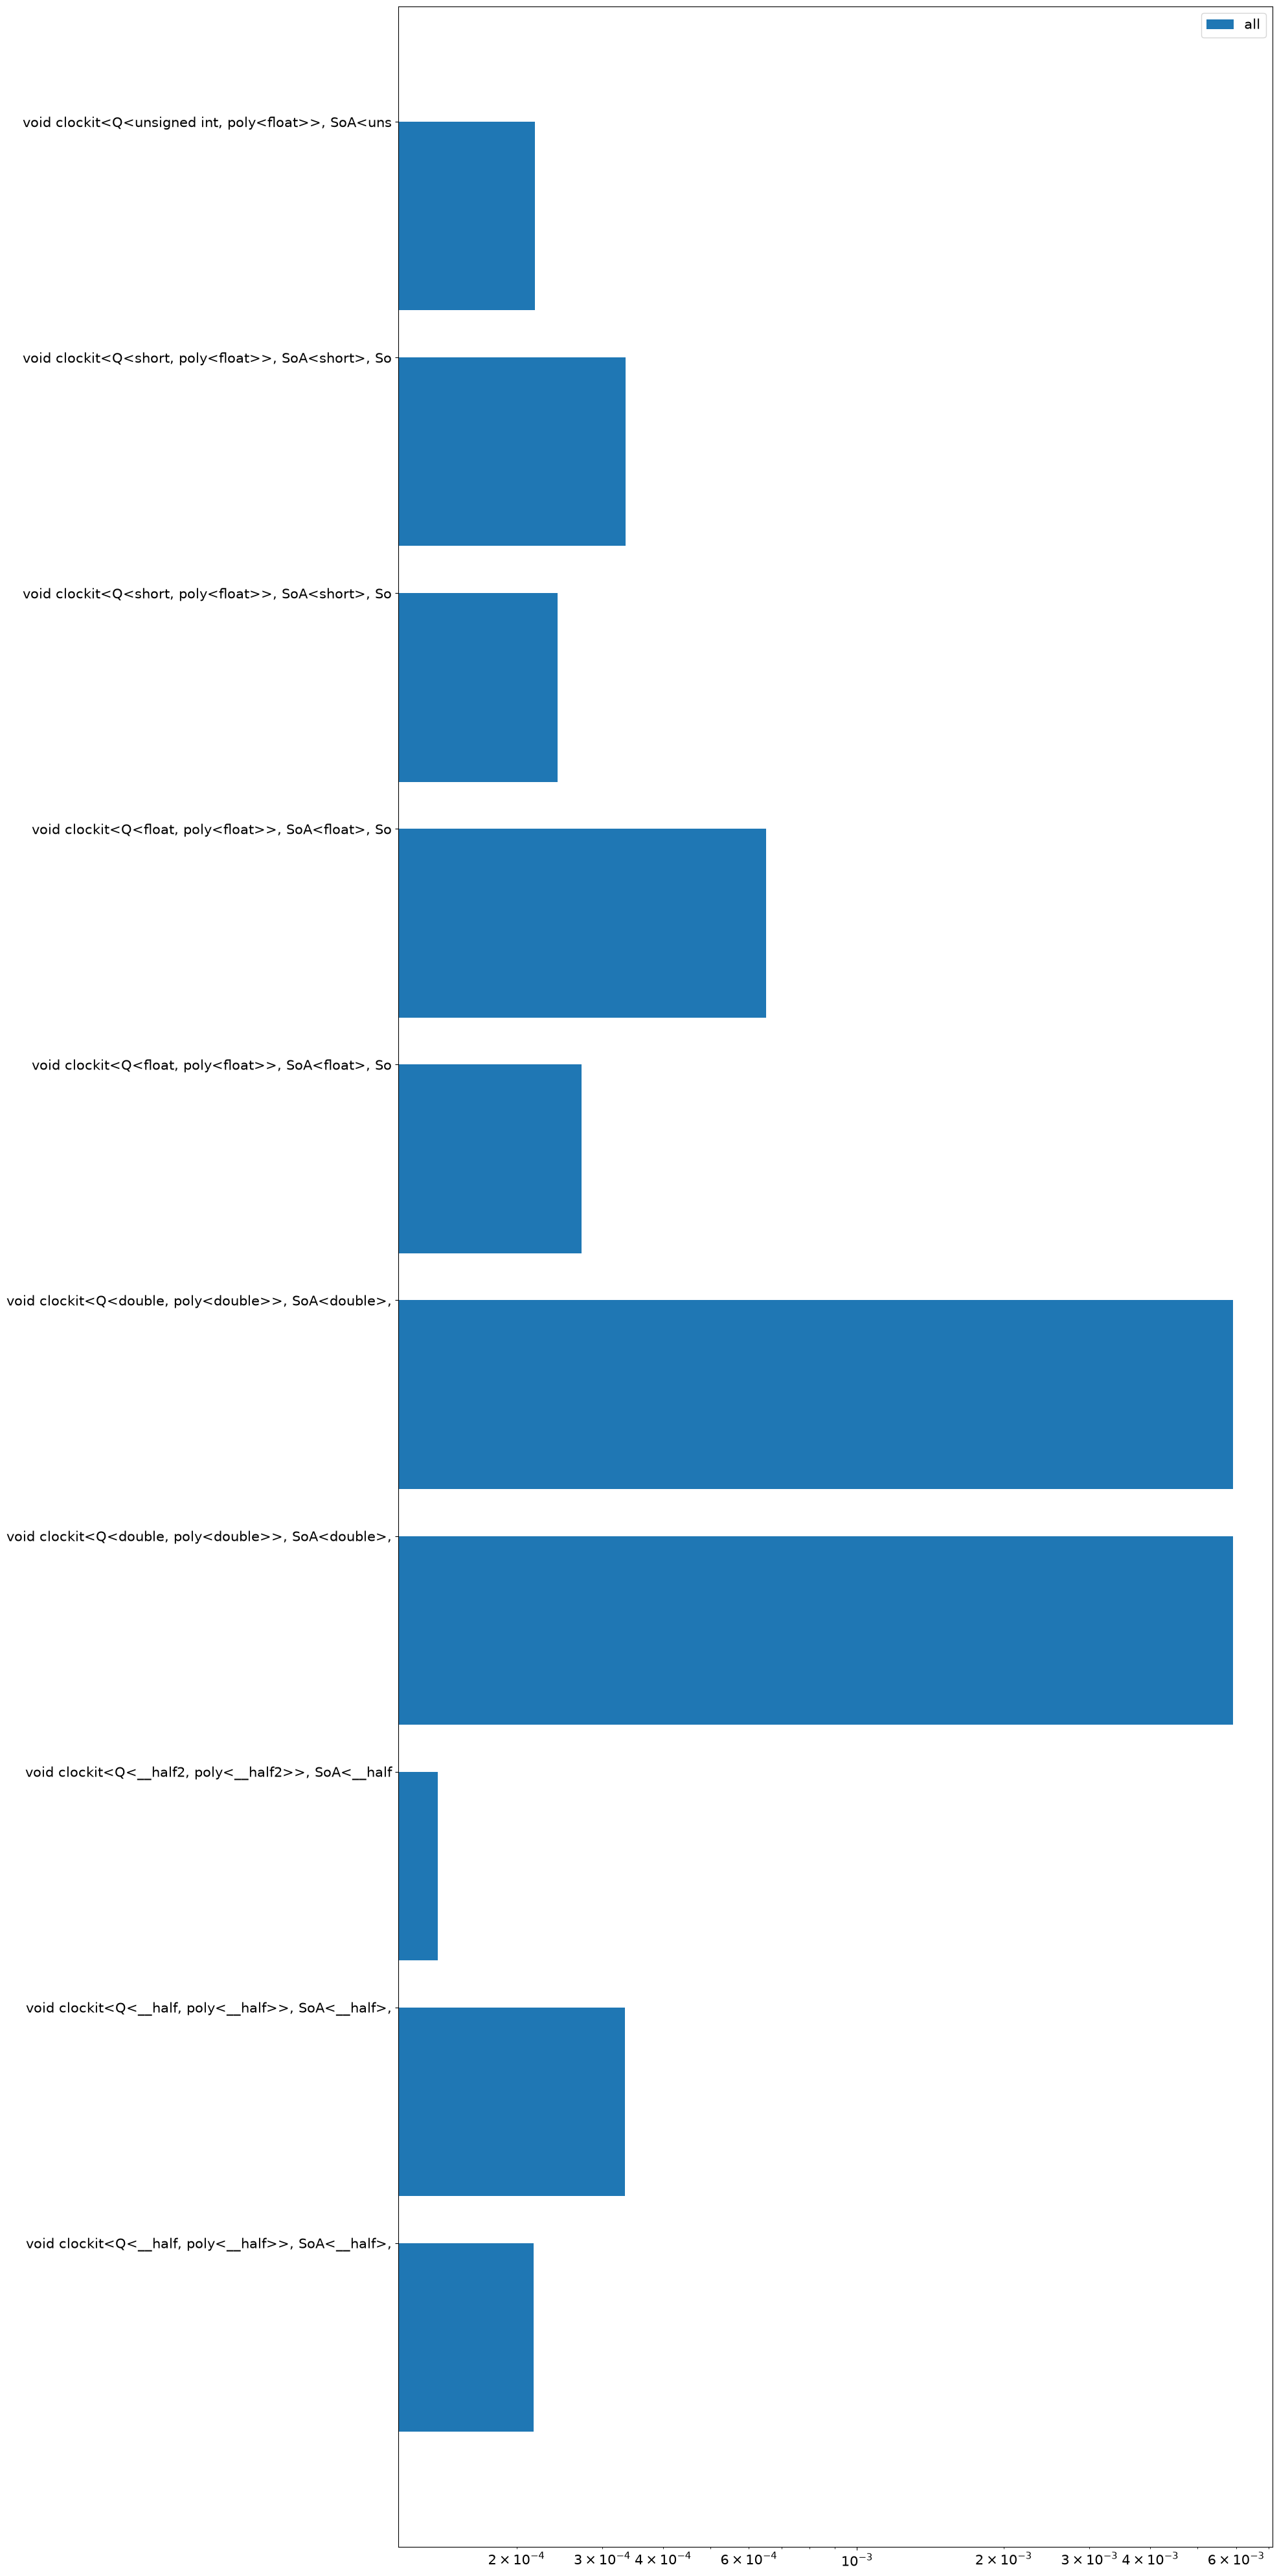

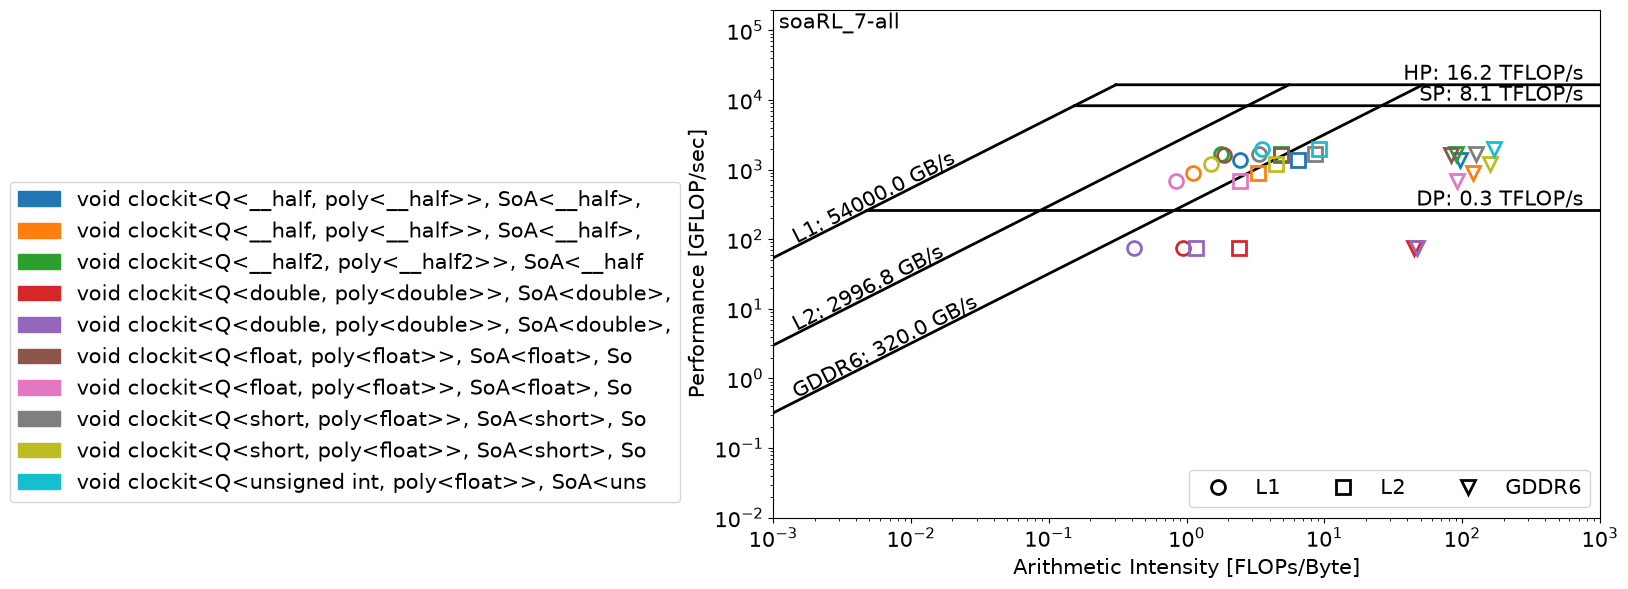

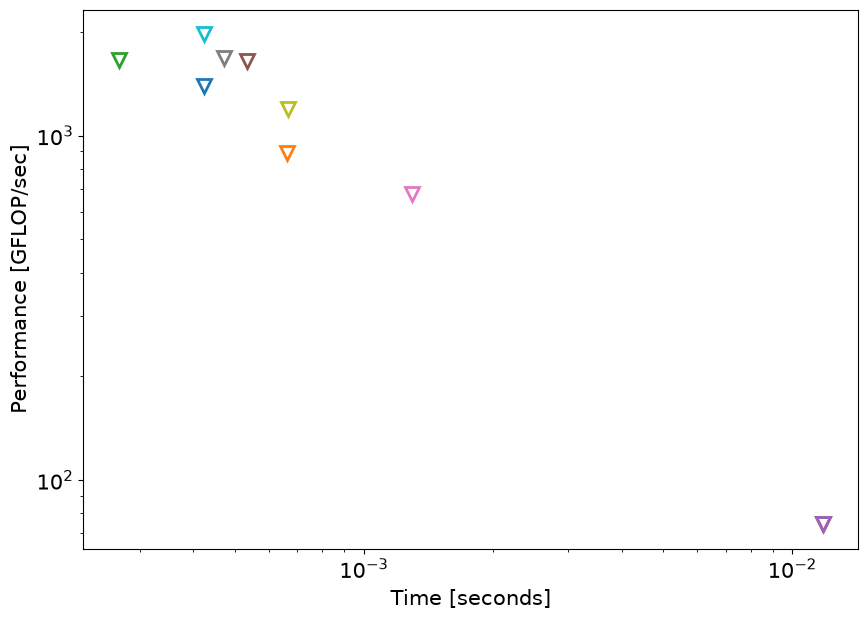

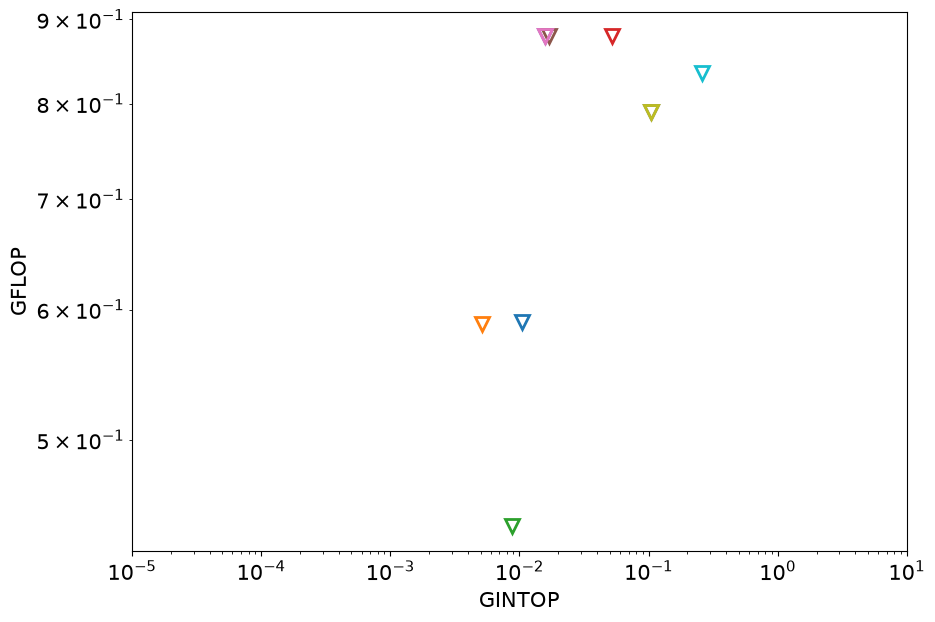

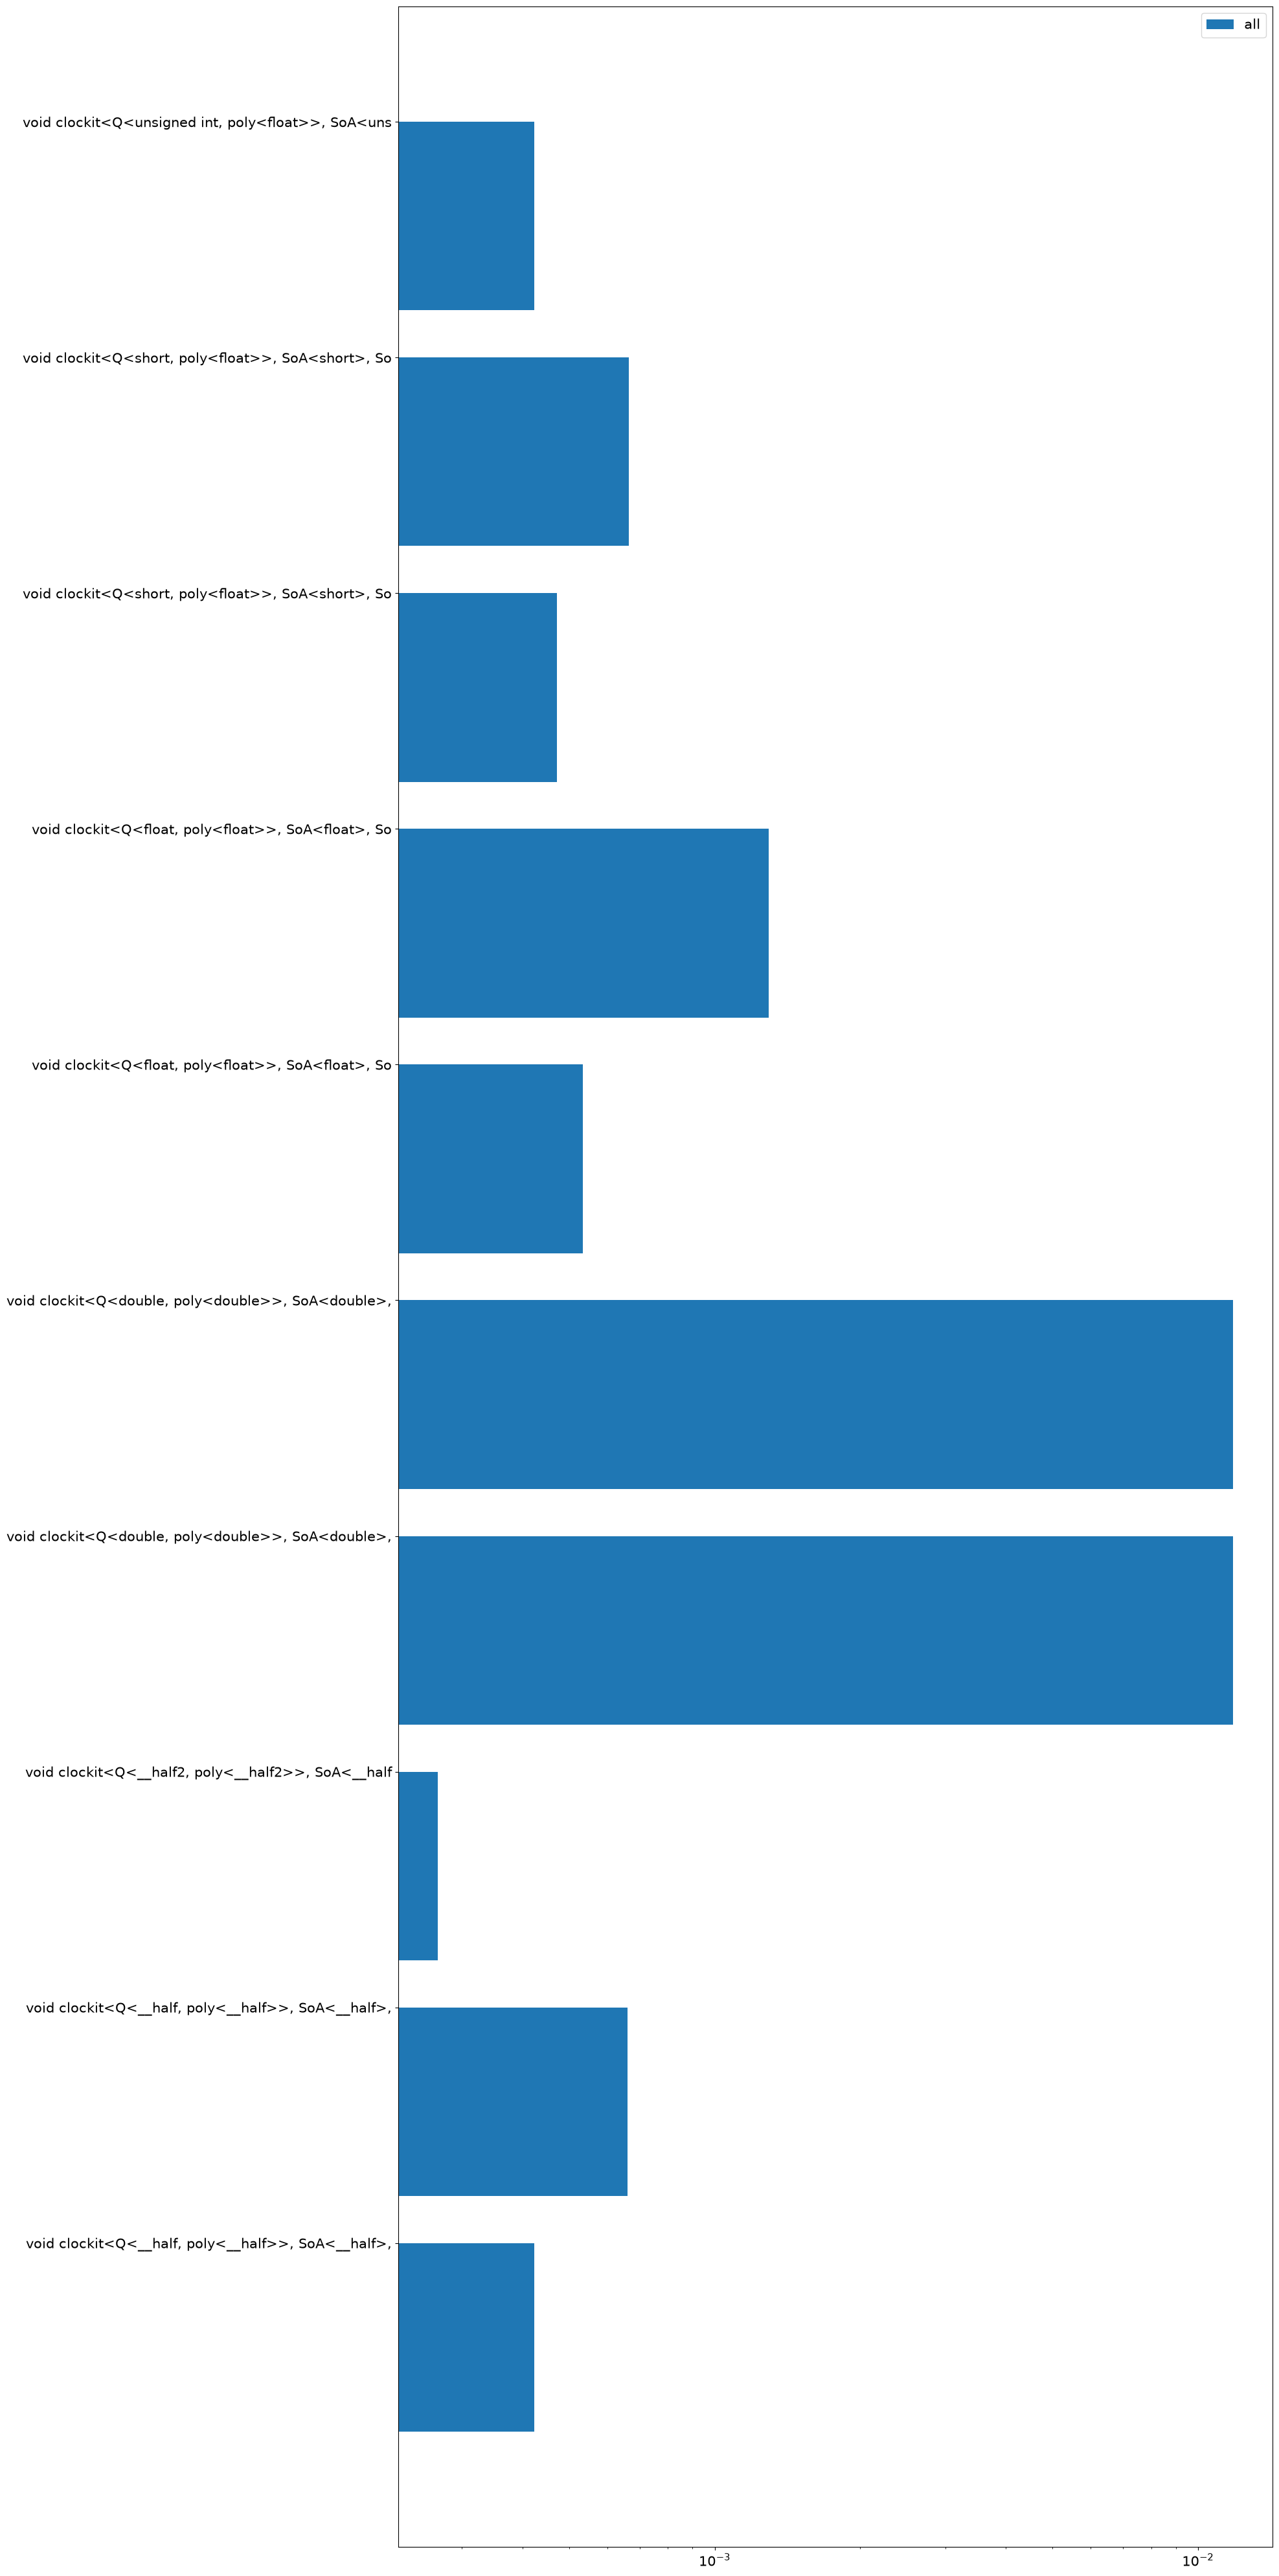

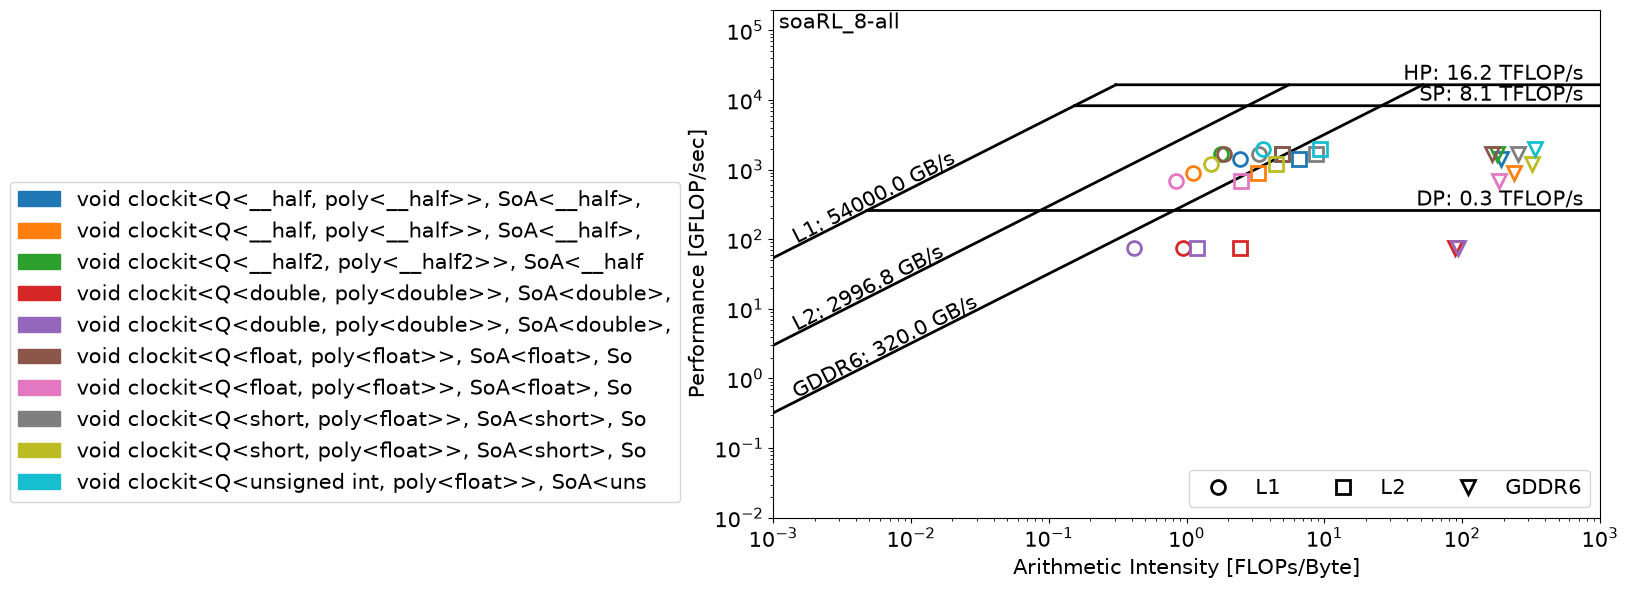

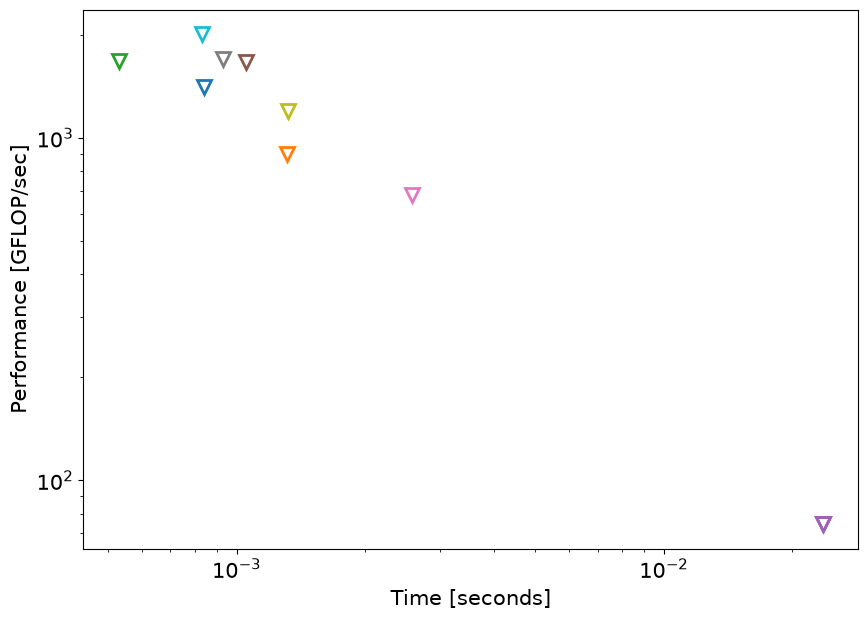

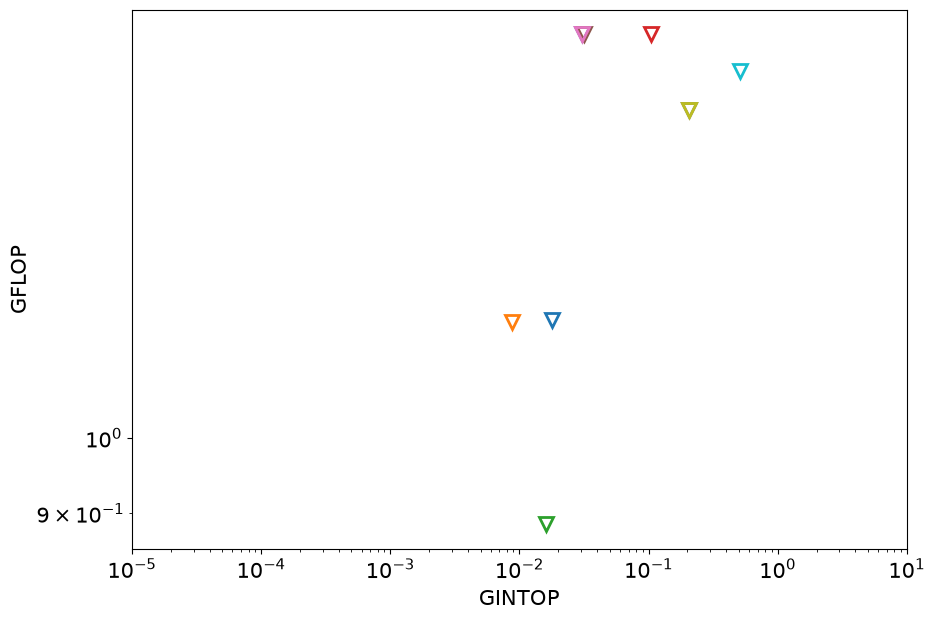

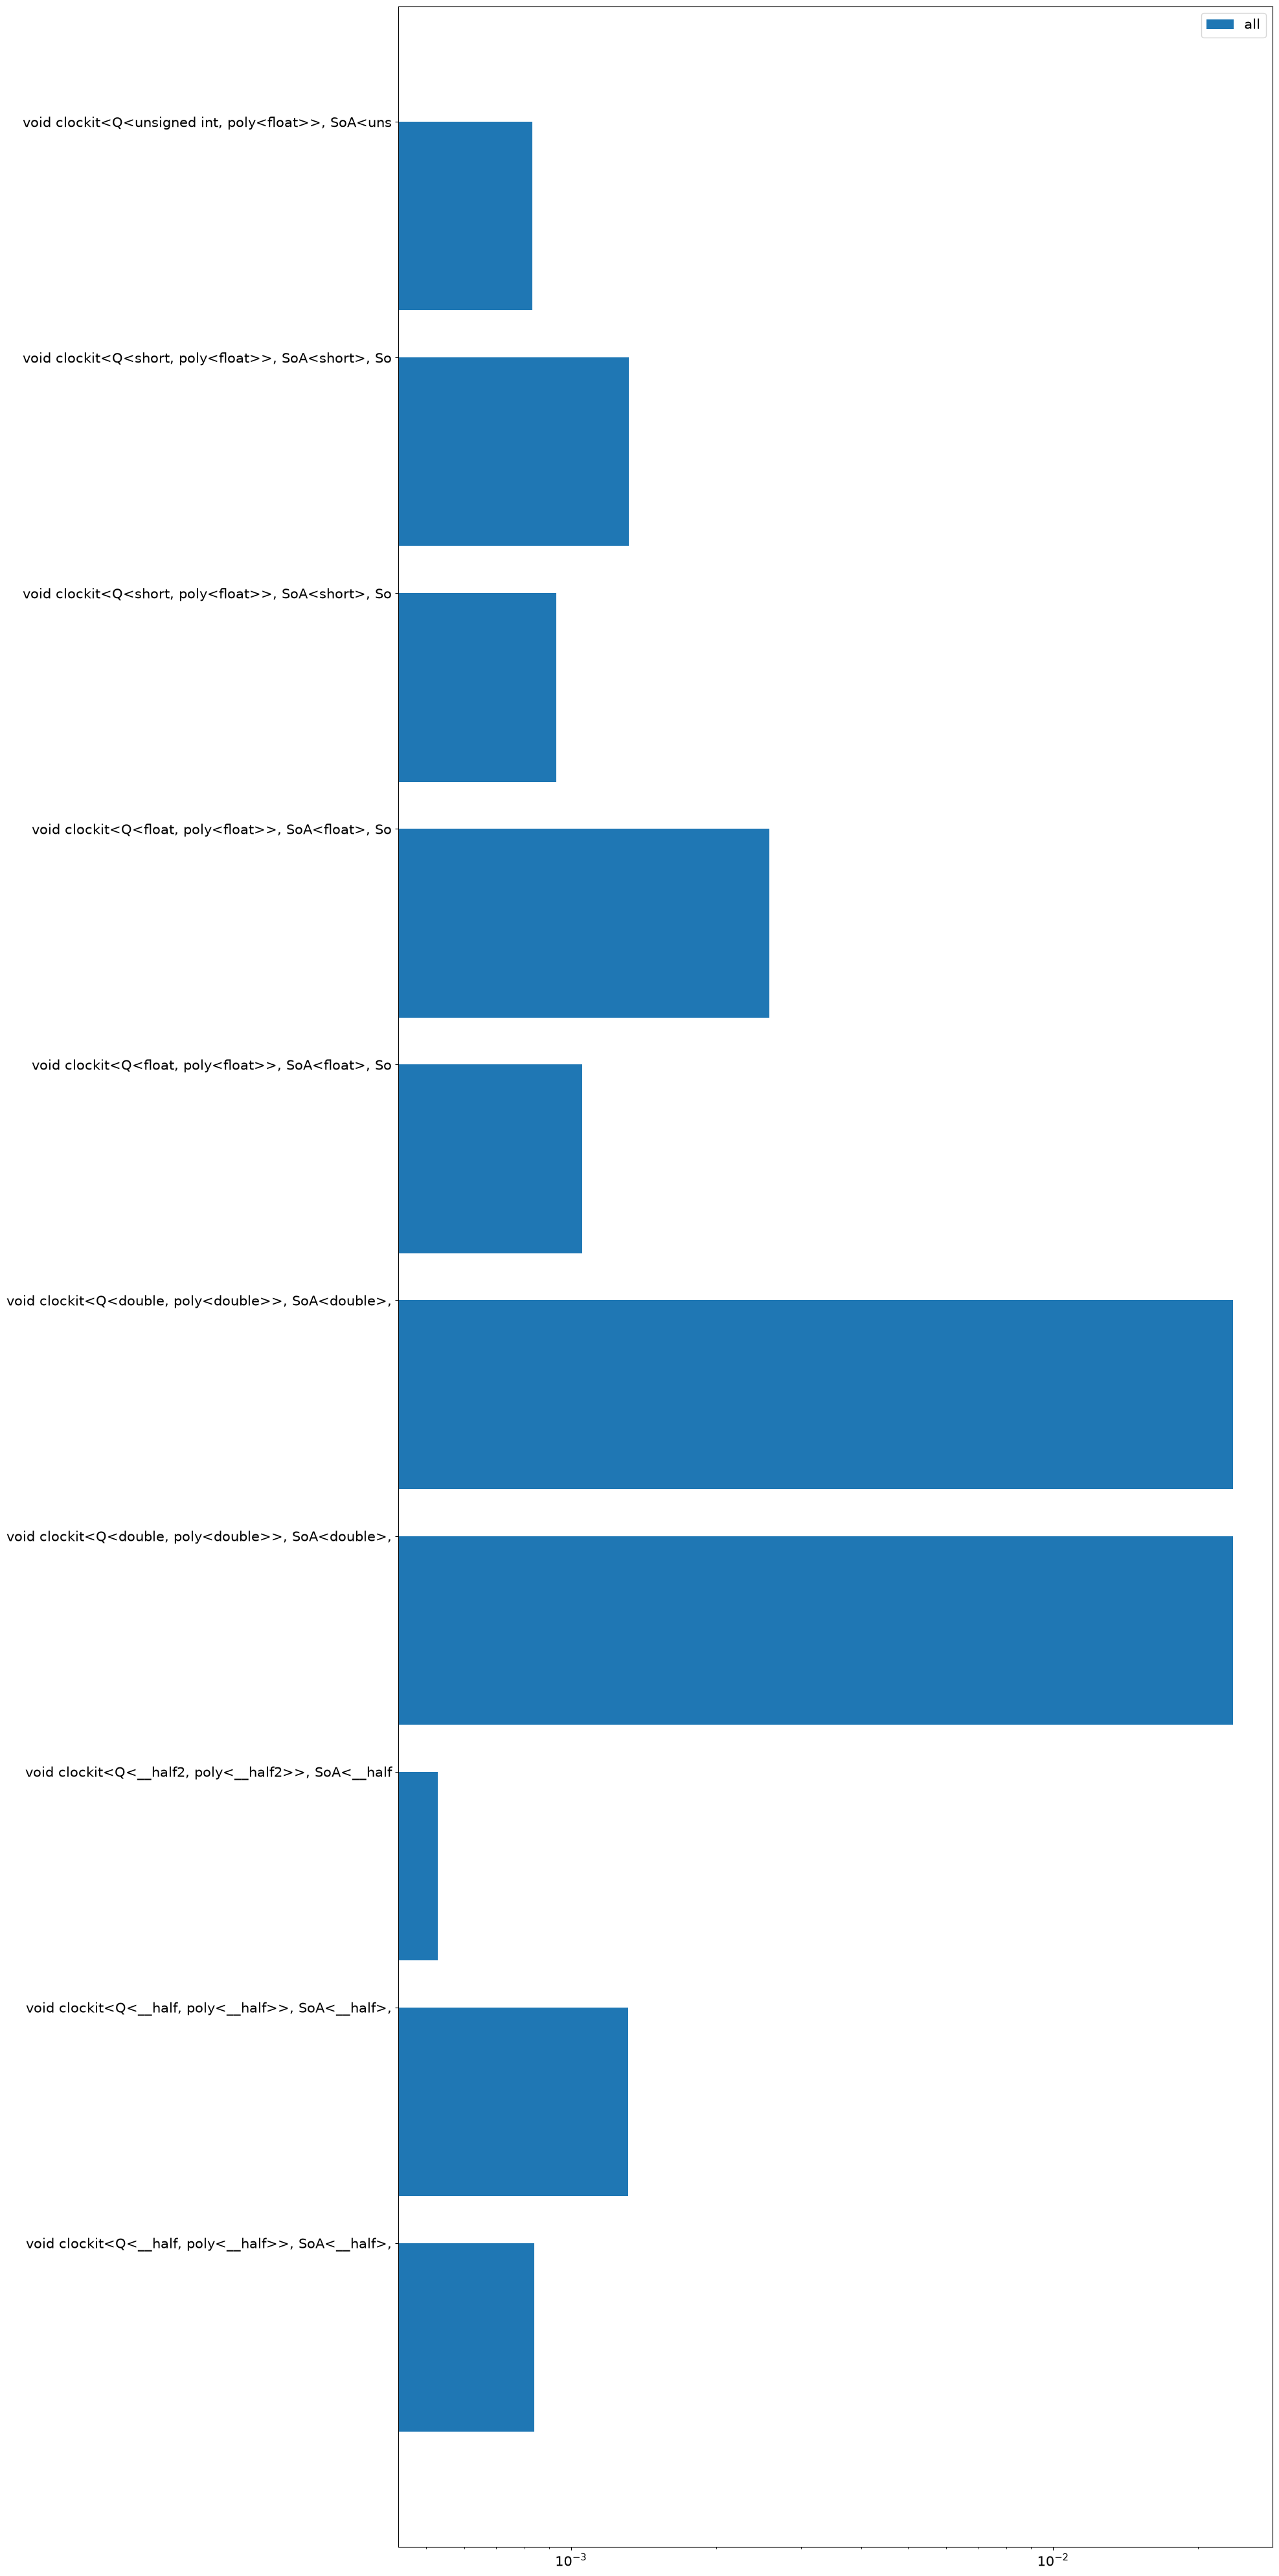

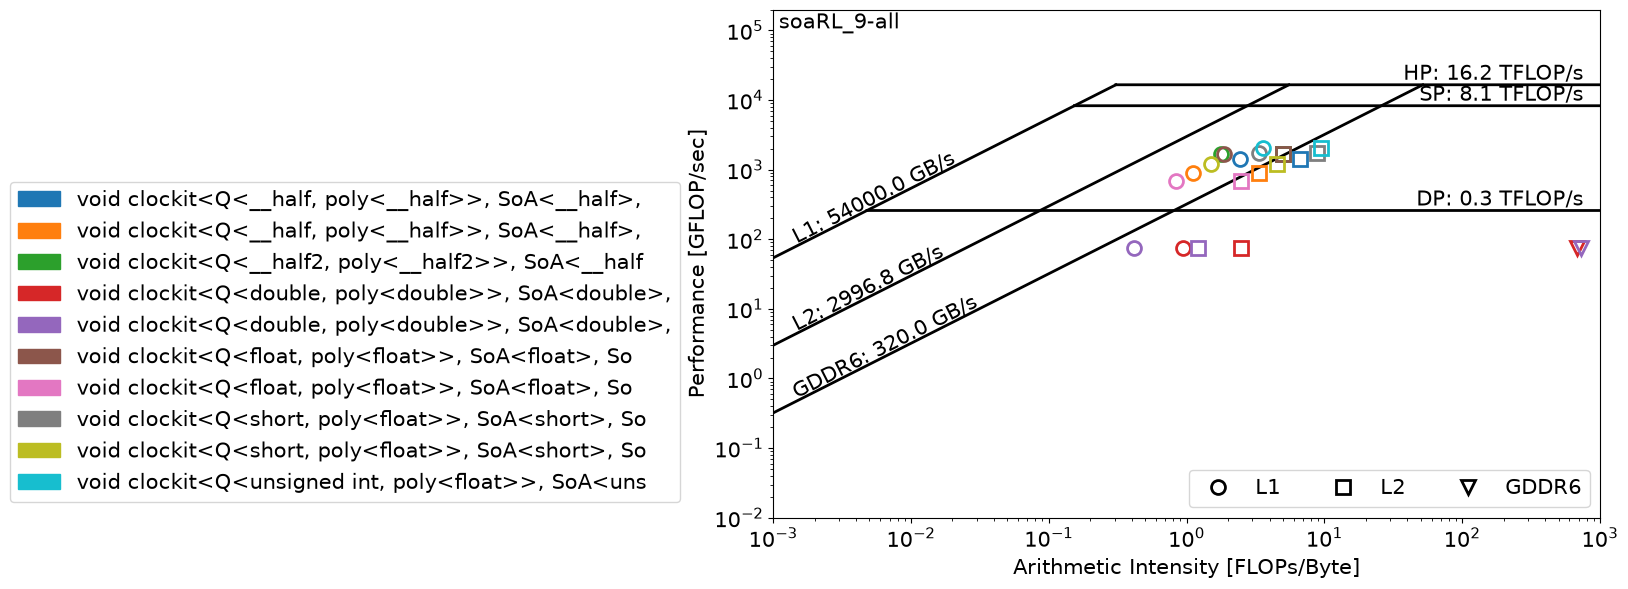

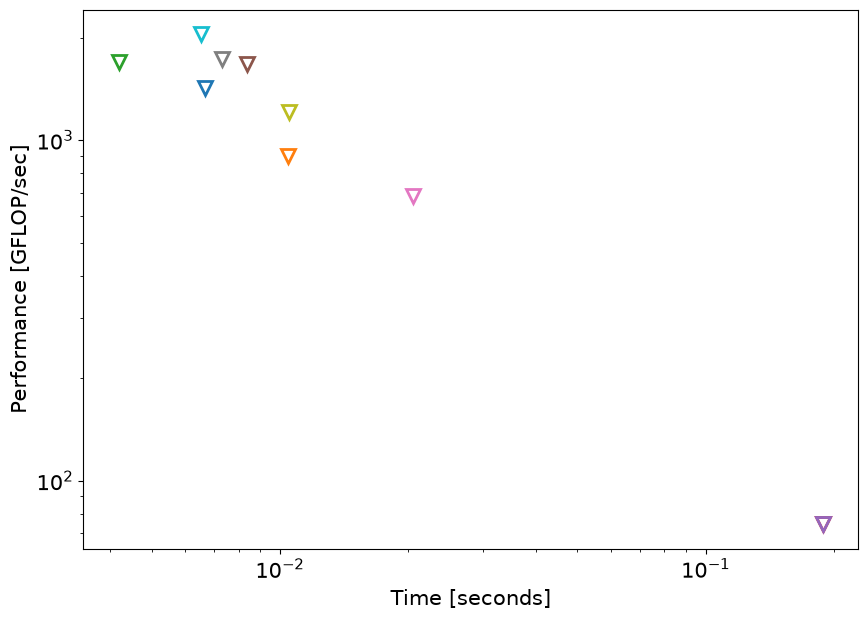

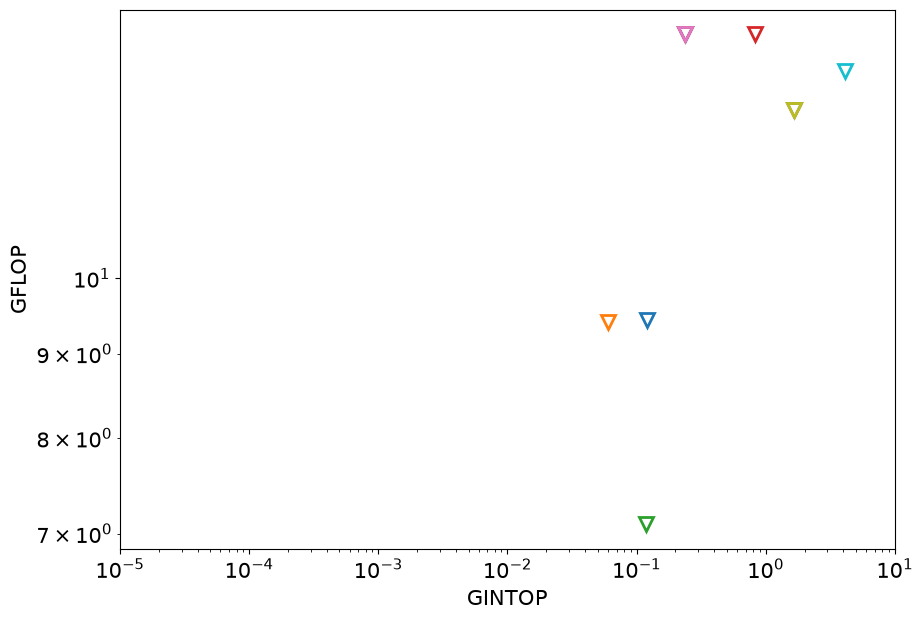

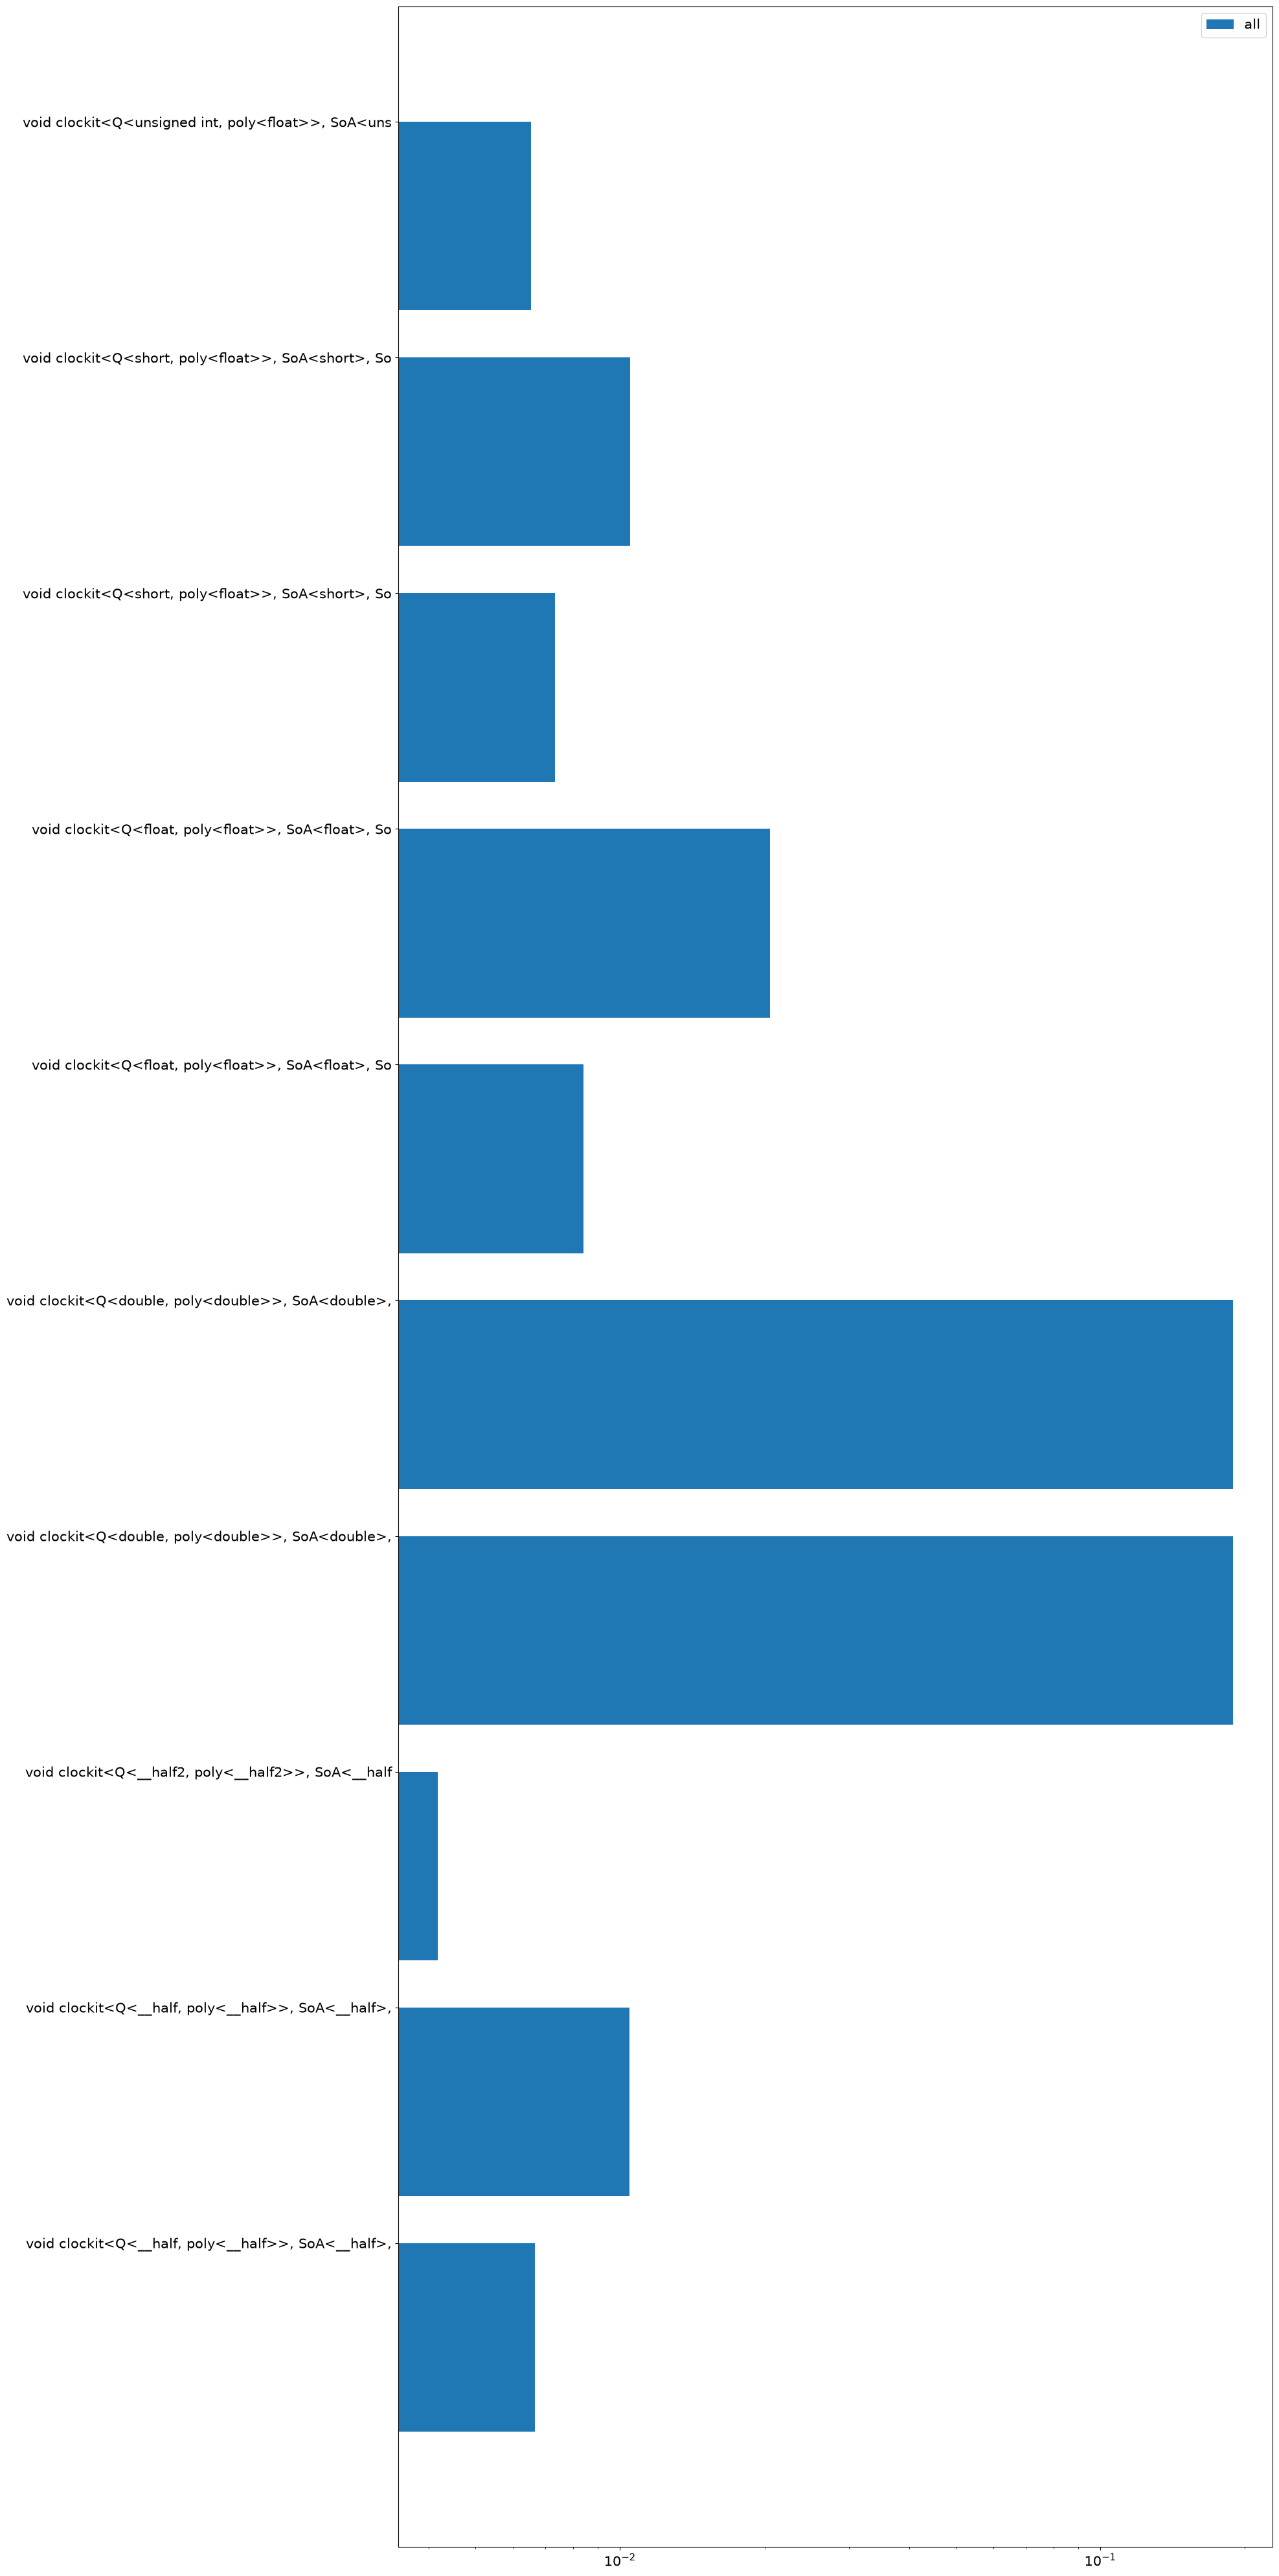

In [240]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from roofline import roofline

# datadir = '/Users/innocent/cernbox2/allSoaRL'
datadir = 'allSoaRL'
#datadir='.'
files=[x for x in os.listdir(datadir) if x.endswith('.csv') and x.startswith('soa')]
#files=[x for x in os.listdir(datadir) if x.endswith('.csv') and x.startswith('hlt')]
files.sort()
files=[os.path.join(datadir,file) for file in files]
dfs={}
for file in files:
    tag, ext = os.path.splitext(os.path.basename(file))
    dfs[tag]=pd.DataFrame()
    with open(file,'r') as f:
        cnt=0
        while True:
            ln=f.readline()
            if not ln:
                break
            cnt+=1
            if 'Host Name' in ln:
                break
        df = pd.read_csv(file, skiprows=cnt-1)
        dft=df.groupby(['Kernel Name','Metric Name']).sum()
        dfmetric=pd.pivot_table(dft, index='Kernel Name', columns='Metric Name', values='Metric Value')
        dfmetric['Count']=df.groupby(['Kernel Name']).count()['ID'].div(dfmetric.shape[1])

        dfmetric['Time']=dfmetric['sm__cycles_elapsed.avg'] \
                        / (dfmetric['sm__cycles_elapsed.avg.per_second'] /dfmetric['Count'] )

        dfmetric['CC FLOPs']= 2 * dfmetric['sm__sass_thread_inst_executed_op_dfma_pred_on.sum'] \
                            + dfmetric['sm__sass_thread_inst_executed_op_dmul_pred_on.sum'] \
                            + dfmetric['sm__sass_thread_inst_executed_op_dadd_pred_on.sum'] \
                            + 2 * dfmetric['sm__sass_thread_inst_executed_op_ffma_pred_on.sum'] \
                            + dfmetric['sm__sass_thread_inst_executed_op_fmul_pred_on.sum'] \
                            + dfmetric['sm__sass_thread_inst_executed_op_fadd_pred_on.sum'] \
                            + 2 * dfmetric['sm__sass_thread_inst_executed_op_hfma_pred_on.sum'] \
                            + dfmetric['sm__sass_thread_inst_executed_op_hmul_pred_on.sum'] \
                            + dfmetric['sm__sass_thread_inst_executed_op_hadd_pred_on.sum']
        # fma count twice
        dfmetric['all CC FLOPs'] = dfmetric['sm__sass_thread_inst_executed_op_fp16_pred_on.sum'] +\
        dfmetric['sm__sass_thread_inst_executed_op_fp32_pred_on.sum'] +\
        dfmetric['sm__sass_thread_inst_executed_op_fp64_pred_on.sum'] +\
        dfmetric['sm__sass_thread_inst_executed_op_dfma_pred_on.sum'] +\
        dfmetric['sm__sass_thread_inst_executed_op_ffma_pred_on.sum'] +\
        dfmetric['sm__sass_thread_inst_executed_op_hfma_pred_on.sum']
        
        dfmetric['TC FLOPs']= 512 * dfmetric['sm__inst_executed_pipe_tensor.sum']
        dfmetric['all FLOPs']= dfmetric['all CC FLOPs'] + dfmetric['TC FLOPs']
        dfmetric['all INTOPs'] = dfmetric['sm__sass_thread_inst_executed_op_integer_pred_on.sum']
        dfmetric['AI HBM'] = dfmetric['all FLOPs'].div(dfmetric['dram__bytes.sum'])
        dfmetric['AI L2'] = dfmetric['all FLOPs'].div(dfmetric['lts__t_bytes.sum'])
        dfmetric['AI L1'] = dfmetric['all FLOPs'].div(dfmetric['l1tex__t_bytes.sum'])
        dfmetric['GFLOP/s'] = dfmetric['all FLOPs']/ dfmetric['Time'] /1024/1024/1024
        dfmetric['GINTOP/s'] = dfmetric['all INTOPs']/ dfmetric['Time'] /1024/1024/1024
        dfmetric['TC GFLOP/s'] = dfmetric['TC FLOPs']/ dfmetric['Time'] /1024/1024/1024
         #dfmetric.to_csv('pd_'+tag+'.csv')
        dfs[tag]=dfmetric
    threads = [parseThree(x) for x in df["Block Size"].tolist()]
    blocks =  [parseThree(x) for x in df["Grid Size"].tolist()]
    #for i in range(len(blocks)):
    #    if blocks[i]>10000 : print(df['Kernel Name'][i], df["Grid Size"][i] ,df["Block Size"][i])
    #plt.rcParams["figure.figsize"] = (30,20)
    #plt.plot(threads,blocks, marker='o', linewidth=0,)
    #plt.plot([1.,1024.],[40.,40.])
    #plt.ylim(0.,1000.)
    #plt.show()
tags=dfs.keys()
flags=['all'] #'HBM','L2','L1' or 'all'
for tag in tags:
    for flag in flags:
        dfm=dfs[tag]
        LABELS = dfm.index.tolist()
        AIL1   = dfm['AI L1'].tolist()
        AIL2   = dfm['AI L2'].tolist()
        AIHBM  = dfm['AI HBM'].tolist()
        FLOPS  = dfm['GFLOP/s'].tolist()
        INTOPS = dfm['GINTOP/s'].tolist()
        TIME   = dfm['Time'].tolist()
        roofline(tag, TIME, INTOPS, FLOPS, AIHBM, AIL2, AIL1, LABELS, flag)
        
        plt.rcParams["figure.figsize"] = (20,40)
        LABELS = [x[:50] for x in LABELS]
        x = np.arange(len(LABELS))  # the label locations
        width = 0.8  # the width of a bar
        # fig = plt.figure(1,figsize=(10,7))
        fig, ax = plt.subplots()
        rects2 = ax.barh(x - width/2, TIME, width, label=flag)
        #x.set_ylabel(label)
        #ax.set_title(label)
        ax.set_yticks(x,LABELS)
        ax.legend()
        # ax.bar_label(rects2, padding=3, rotation=90)
        fig.tight_layout()
        plt.xscale("log")
        # plt.xticks(rotation=90)
        plt.show()
